In [ ]:
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

warnings.filterwarnings('ignore')

# Name of Dataset : Women's Clothing Sizes

# Context

Online clothes stores can sometimes face challenges when it comes to accurately representing sizes, which can lead to customer dissatisfaction and frustration. Here are some common mistakes that online clothes stores make regarding sizes:

Inconsistent Sizing Standards: Different brands and manufacturers often have their own sizing standards, which can vary significantly. Unfortunately, online stores may not always provide detailed size charts or accurate measurements for each product, leading to confusion for customers. As a result, customers may receive clothes that don't fit as expected.

Lack of Standardization: Even within the same brand, inconsistencies in sizing can occur across different product lines or collections. This inconsistency can make it difficult for customers to determine their correct size when shopping online, leading to the need for returns and exchanges.

Limited Size Range: Some online stores may fail to cater to a diverse range of body sizes. They may offer limited size options, excluding customers who fall outside the average or conventional size range. This exclusion can be frustrating for individuals who struggle to find clothes that fit their unique body shapes.

Insufficient Measurement Information: Online stores sometimes provide incomplete or inadequate measurements for their clothing items. They may only provide generic size labels such as small, medium, or large, without specifying the exact measurements of the garments. This lack of detailed information can make it challenging for customers to make informed decisions about sizing.

Inaccurate Product Descriptions: Descriptions of clothing items can be misleading, especially when it comes to the fit of the garment. Online stores may use ambiguous terms like "oversized," "relaxed fit," or "true to size," which can be interpreted differently by customers. Without clear explanations or visual references, customers may struggle to determine the appropriate size for themselves.

Inadequate Customer Support: When customers face sizing issues with their online clothing purchases, it is essential to have effective customer support available. Unfortunately, some online stores may lack responsive customer service, making it difficult for customers to resolve their size-related problems or obtain timely assistance.

To mitigate these mistakes and improve the online shopping experience, online clothes stores can take several steps. They should provide comprehensive and accurate size charts, offer detailed measurements for each clothing item, include visuals or models wearing the garments to showcase fit, prioritize size inclusivity by expanding their size ranges, and enhance customer support to address sizing concerns promptly and effectively. By addressing these issues, online clothes stores can help customers make better-informed choices and reduce size-related frustrations.

**Source :** https://www.kaggle.com/datasets/tourist55/clothessizeprediction


In [ ]:
dataframed = pd.read_csv('/content/final_test.csv')
dataframed.head()

,weight,age,height,size
0,62,28.0,172.72,XL
1,59,36.0,167.64,L
2,61,34.0,165.10,M
3,65,27.0,175.26,L
4,62,45.0,172.72,M


# The Dataset consist of the following :
* 119734 rows
* 4 columns

In [ ]:
print('Shape of the Dataset =', dataframed.shape)

Shape of the Dataset = (119734, 4)


# METADATA
1. **Weight (in kgs) :**  Weight refers to the measurement of the amount of mass or heaviness of an object or a person. It is commonly expressed in kilograms (kg) in the metric system.

2. **Age :** Age refers to the length of time a person has been alive, measured in years. It is an important factor in various aspects of life, including development, growth, legal rights, and social interactions. Age is often used to categorize individuals into different age groups for statistical, medical, and legal purposes.

3. **Height (in cm) :** Height refers to the vertical measurement of an object or a person from the base to the top. It is commonly expressed in centimeters (cm) or feet and inches. When referring to a person's height, it typically indicates the distance from the ground to the top of their head, while standing upright.

4. **Size :**  Size can have different meanings depending on the context. In the context of clothing, size typically refers to the measurement or designation that indicates the fit of a garment. Clothing sizes can vary depending on the brand, country, and type of clothing item. In the context of this dataset here are the following sizes from smallest to largest :
      * **XXS** = extra-extra-small
      * **S** = small,
      * **M** = medium,
      * **L** = large,
      * **XL** = extra-large,
      * **XXL** = extra-extra-large,
      * **XXXL** = extra-extra-extra-large

In [ ]:
dataframed.columns.values.tolist()

['weight', 'age', 'height', 'size']

In [ ]:
dataframed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119734 entries, 0 to 119733
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   weight  119734 non-null  int64  
 1   age     119477 non-null  float64
 2   height  119404 non-null  float64
 3   size    119734 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 3.7+ MB


In [ ]:
dataframed.describe()

,weight,age,height
count,119734.000000,119477.000000,119404.000000
mean,61.756811,34.027311,165.805794
std,9.944863,8.149447,6.737651
min,22.000000,0.000000,137.160000
25%,55.000000,29.000000,160.020000
50%,61.000000,32.000000,165.100000
75%,67.000000,37.000000,170.180000
max,136.000000,117.000000,193.040000


In [ ]:
dataframed.dtypes

weight      int64
age       float64
height    float64
size       object
dtype: object

In [ ]:
dataframed.isnull().sum()

weight      0
age       257
height    330
size        0
dtype: int64

# Columns with missing values :

1. Age : Age refers to the length of time a person has been alive, measured in years. It is an important factor in various aspects of life, including development, growth, legal rights, and social interactions. Age is often used to categorize individuals into different age groups for statistical, medical, and legal purposes.

2. Height (in cm) : Height refers to the vertical measurement of an object or a person from the base to the top. It is commonly expressed in centimeters (cm) or feet and inches. When referring to a person's height, it typically indicates the distance from the ground to the top of their head, while standing upright.



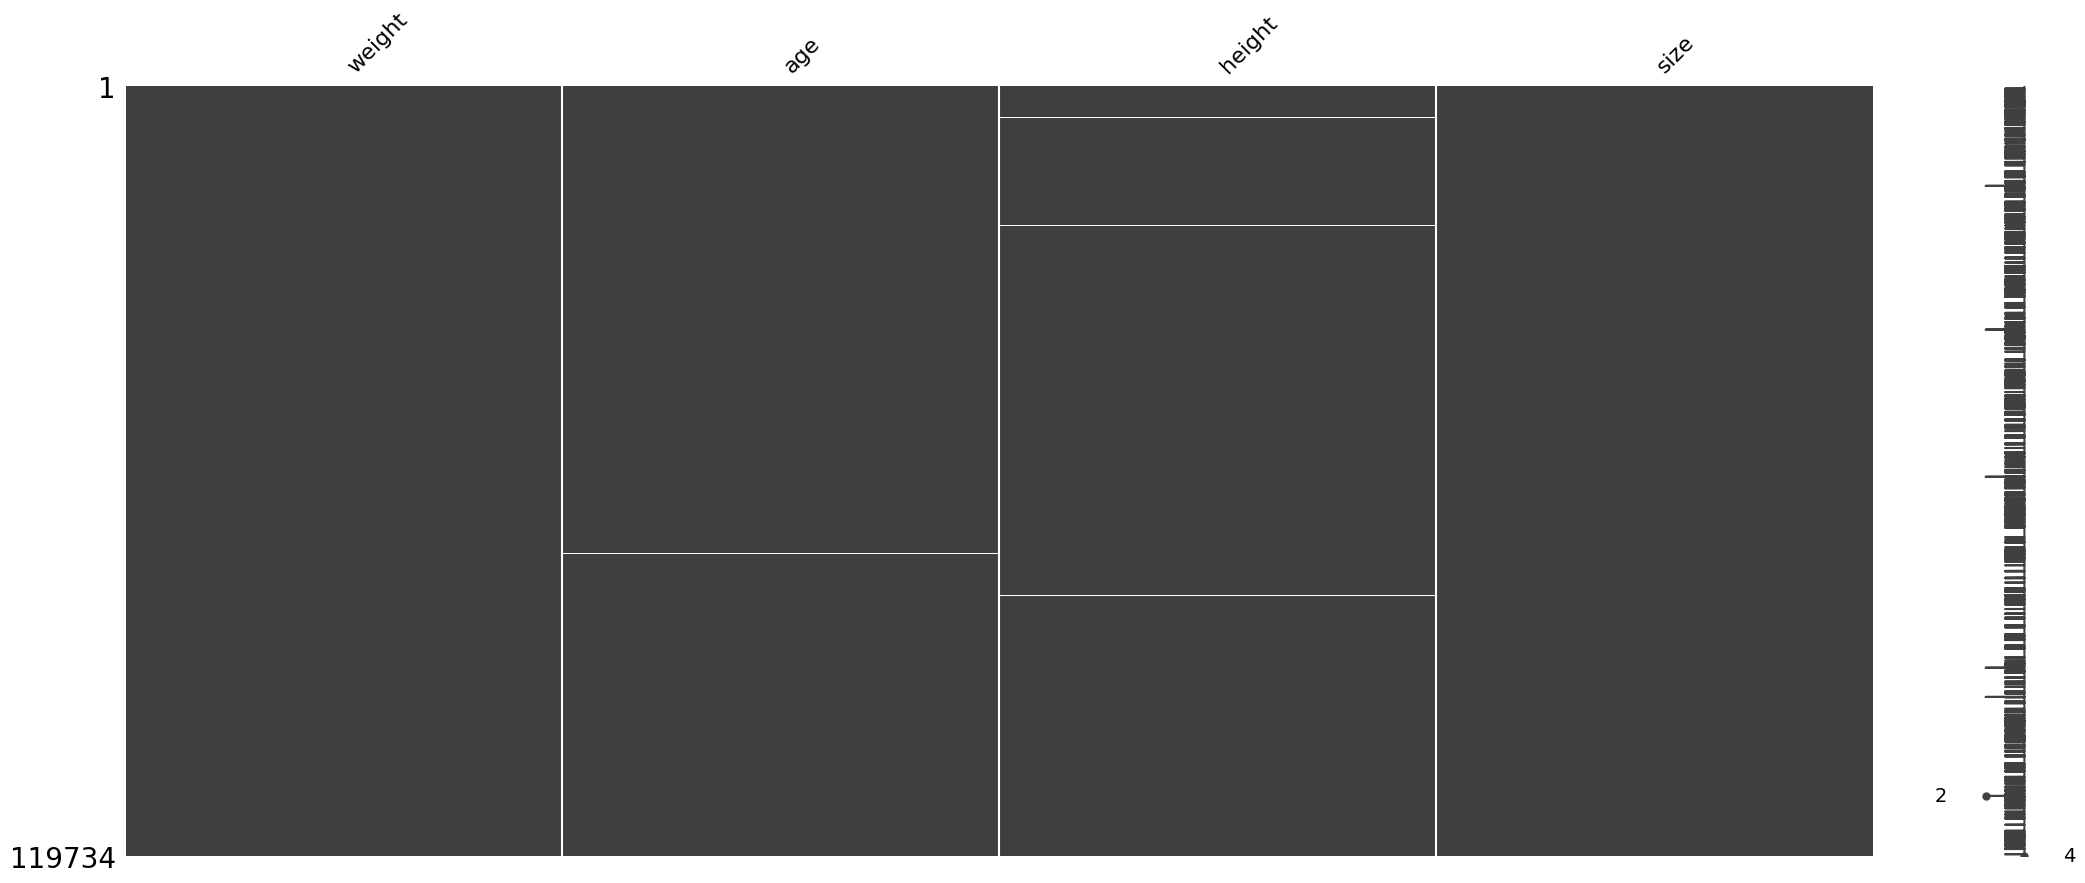

In [ ]:
import missingno as msno
msno.matrix(dataframed)
plt.show()

# Missing Values : Age
Age refers to the length of time a person has been alive, measured in years. It is an important factor in various aspects of life, including development, growth, legal rights, and social interactions. Age is often used to categorize individuals into different age groups for statistical, medical, and legal purposes.

In [ ]:
dataframed['age'] = dataframed['age'].fillna(dataframed['age'].median())

# Missing Values : Height (in cm)
Height refers to the vertical measurement of an object or a person from the base to the top. It is commonly expressed in centimeters (cm) or feet and inches. When referring to a person's height, it typically indicates the distance from the ground to the top of their head, while standing upright.

In [ ]:
dataframed['height'] = dataframed['height'].fillna(dataframed['height'].median())

# Mapping Values : Size
Size can have different meanings depending on the context. In the context of clothing, size typically refers to the measurement or designation that indicates the fit of a garment. Clothing sizes can vary depending on the brand, country, and type of clothing item. In the context of this dataset here are the following sizes from smallest to largest :
   * **XXS** = extra-extra-small = 1
   * **S** = small = 2
   * **M** = medium = 3
   * **L** = large = 4
   * **XL** = extra-large = 5
   * **XXL** = extra-extra-large = 6
   * **XXXL** = extra-extra-extra-large = 7

In [ ]:
dataframed['size'] = dataframed['size'].map({"XXS": 1, "S": 2, "M" : 3, "L" : 4, "XL" : 5, "XXL" : 6, "XXXL" : 7})

# Feature Engineering

Columns we will create :
* **Body Mass Index (BMI) :**  Body Mass Index (BMI) is a numerical value calculated based on a person's weight and height. It is a widely used metric to assess whether an individual's weight is within a healthy range relative to their height. The BMI calculation provides a general indication of body composition and is often used as a screening tool to identify potential weight-related health risks.

The formula for calculating BMI is as follows:

> BMI = weight (in kilograms) / (height (in meters))^2

Alternatively, for height measured in centimeters, the formula can be modified as:

> BMI = weight (in kilograms) / (height (in centimeters) / 100)^2

Once the BMI is calculated, it is categorized into different ranges that correspond to varying degrees of weight status. The World Health Organization (WHO) classification commonly used for adults is as follows:

* Underweight: BMI less than 18.5
* Normal weight: BMI between 18.5 and 24.9
* Overweight: BMI between 25 and 29.9
* Obesity (Class I): BMI between 30 and 34.9
* Obesity (Class II): BMI between 35 and 39.9
* Obesity (Class III): BMI 40 or higher

In [ ]:
dataframed['bmi'] = dataframed['weight'] / (pow(dataframed['height'] / 100, 2))

# EDA
**Types of Rows :**
* Overall Clothing Size Samples
* XXS Clothing Size Samples
* S Clothing Size Samples
* M Clothing Size Samples
* L Clothing Size Samples
* XL Clothing Size Samples
* XXL Clothing Size Samples
* XXXL Clothing Size Samples

# Types of Rows : Overall Clothing Size Samples

# The Range of Values among the different 5 Columns

In [ ]:
print('The Range of Values among the different 5 Columns')

print('weight : {:.4f}'.format(min(dataframed['weight'])) + ' - {:.4f}'.format(max(dataframed['weight'])))
print('\n')
print('age : {:.4f}'.format(min(dataframed['age'])) + ' - {:.4f}'.format(max(dataframed['age'])))
print('\n')
print('height : {:.4f}'.format(min(dataframed['height'])) + ' - {:.4f}'.format(max(dataframed['height'])))
print('\n')
print('size : {:.4f}'.format(min(dataframed['size'])) + ' - {:.4f}'.format(max(dataframed['size'])))
print('\n')
print('BMI : {:.4f}'.format(min(dataframed['bmi'])) + ' - {:.4f}'.format(max(dataframed['bmi'])))

The Range of Values among the different 5 Columns
weight : 22.0000 - 136.0000


age : 0.0000 - 117.0000


height : 137.1600 - 193.0400


size : 1.0000 - 7.0000


BMI : 7.8283 - 54.3236


# Distribution of Values among different 5 columns

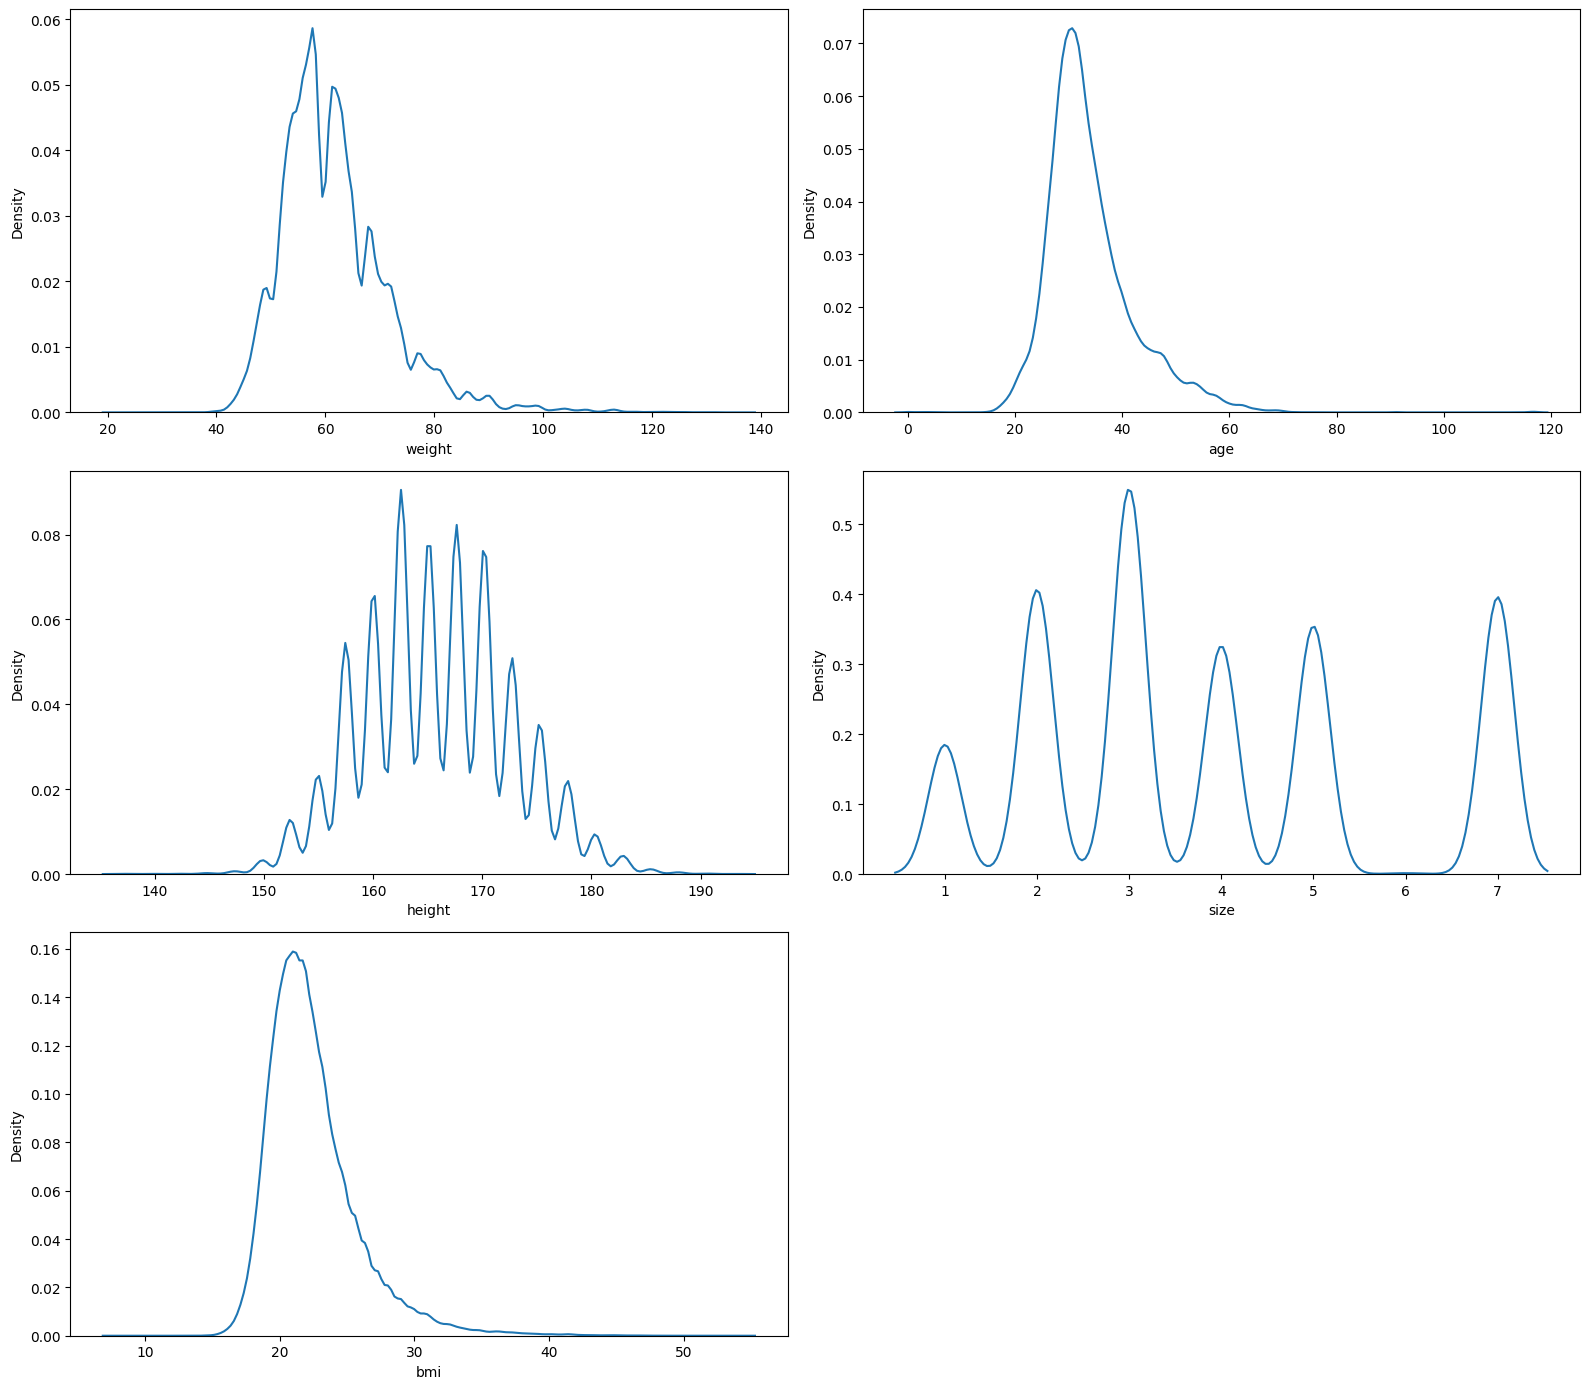

In [ ]:
plt.figure(figsize=(16,14))
for i,col in enumerate(dataframed.columns):
    plt.subplot(3,2,i+1)
    sns.kdeplot(data=dataframed[col])
    plt.tight_layout()

# Pearson correlation coefficient Heatmap

This kind of correlation expresses a value from 1 to -1 to represent the strength of relativity among two different variables.

* -1 = Perfectly Negative

* -0.8 = Strongly Negative

* -0.5 = Moderately Negative

* -0.2 = Weakly Negative

* 0 = No association

* 0.2 = Weakly Positive

* 0.5 = Moderately Positive

* 0.8 = Strongly Positive

* 1 = Perfectly Positive

[Text(0.5, 57.219999999999985, 'Pearson Correlation Coefficient Heatmap')]

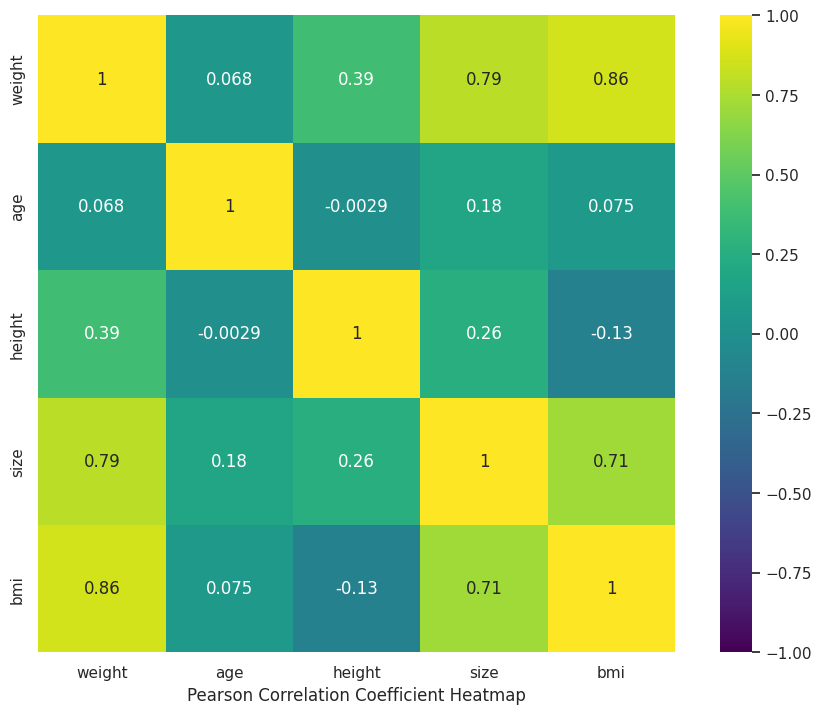

In [ ]:
sns.set(rc={'figure.figsize':(11.7,8.27)})
Heated = sns.heatmap(dataframed.corr("pearson"),vmin=-1, vmax=1,cmap='viridis',annot=True, square=True)
Heated.set(xlabel = "Pearson Correlation Coefficient Heatmap")

# Check for Outliers among the different 5 columns

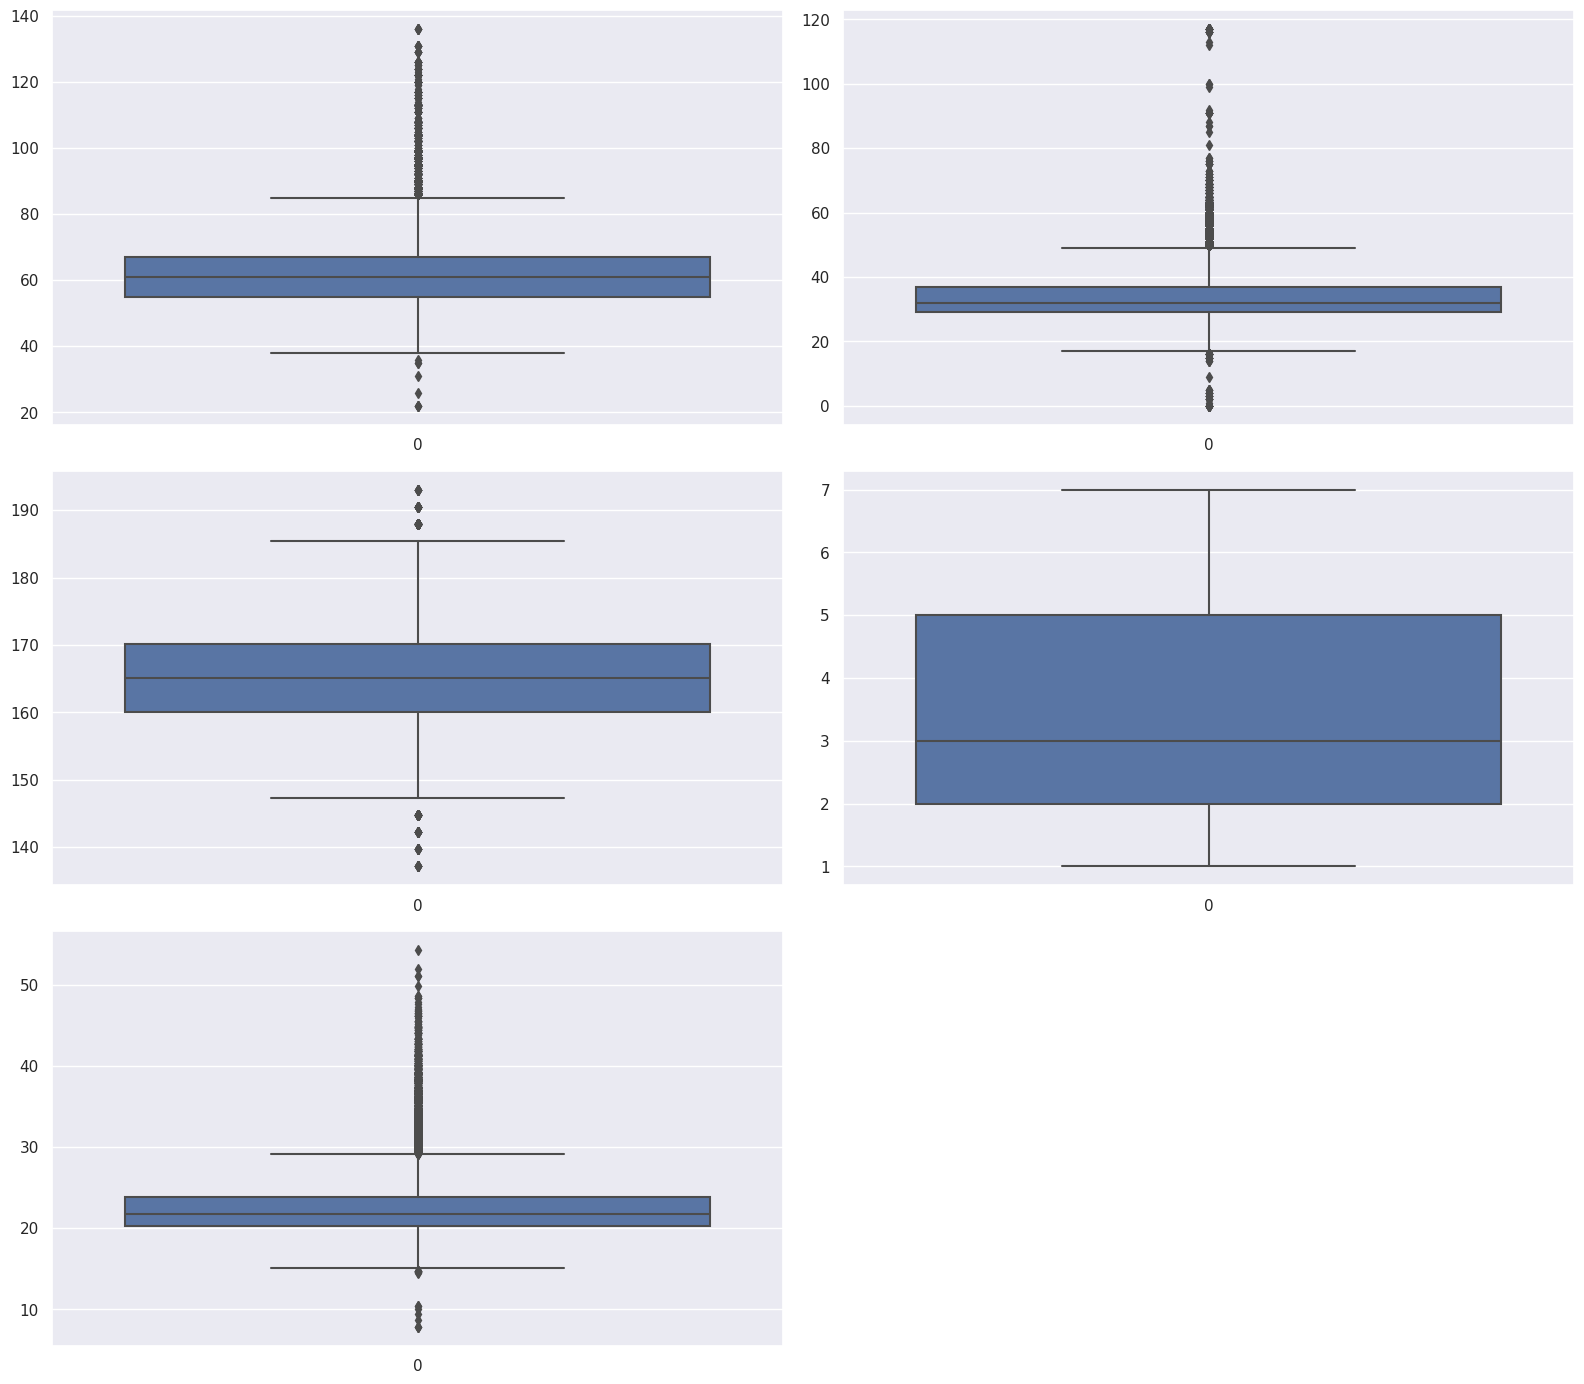

In [ ]:
plt.figure(figsize=(16,14))
for i,col in enumerate(dataframed.columns):
    plt.subplot(3,2,i+1)
    sns.boxplot(data=dataframed[col])

    plt.tight_layout()

# Column : Weight (in kgs)

# Distribution of rows in terms of Weight

[(22.0, 136.0)]

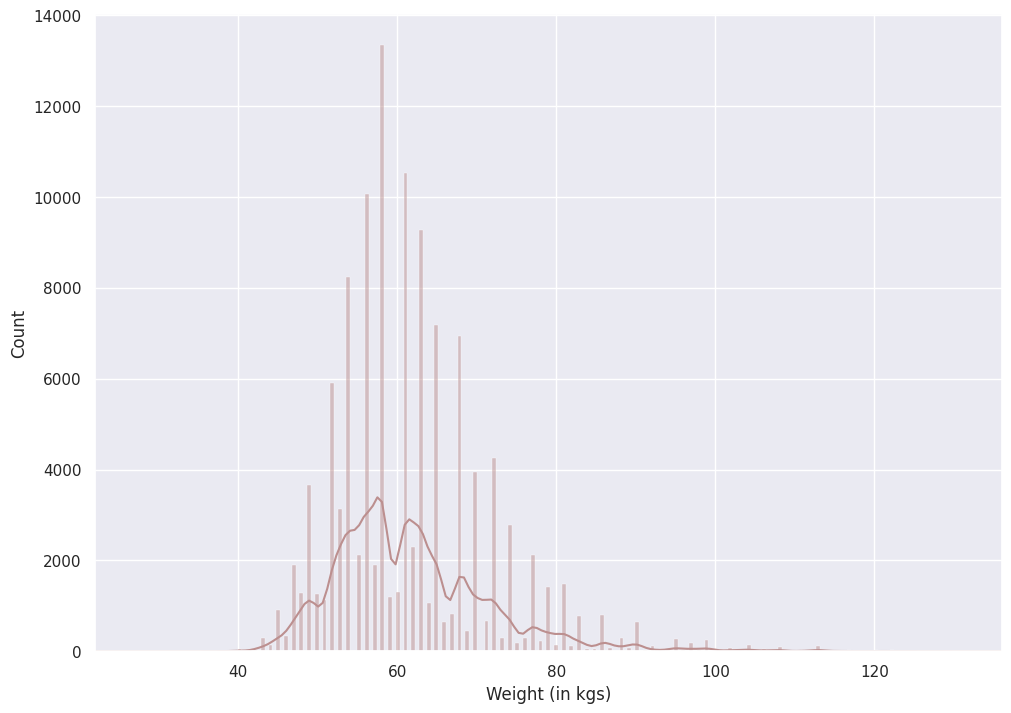

In [ ]:
count_plotted = sns.histplot(x = 'weight', data = dataframed, kde = True, color = 'rosybrown')
count_plotted.set(xlabel = "Weight (in kgs)")
count_plotted.set(xlim = (22.0000,136.0000))

# Outliers : Weight

[(22.0, 136.0)]

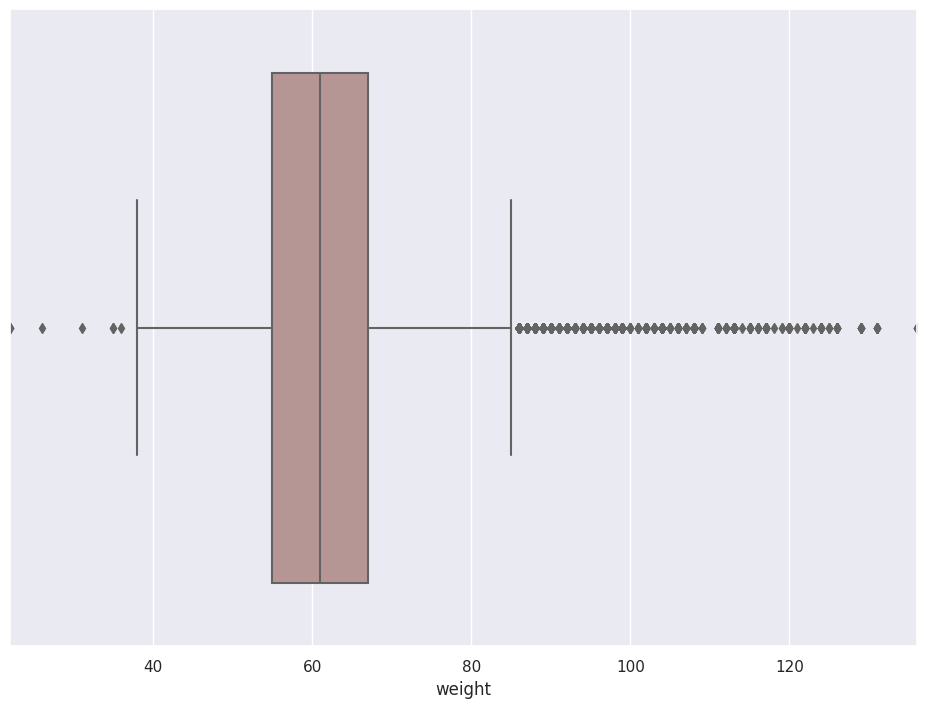

In [ ]:
boxxer_plot = sns.boxplot(x = 'weight', data = dataframed, color = 'rosybrown')
boxxer_plot.set(xlim = (22.0000,136.0000))

# How many outliers in Weight Column?

In [ ]:
numpy_array = np.array(dataframed['weight'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 37.0000 or greater than 85.0000
There are 3510 outliers.


# Column : Age

# Distribution of rows in terms of Age

[(0.0, 117.0)]

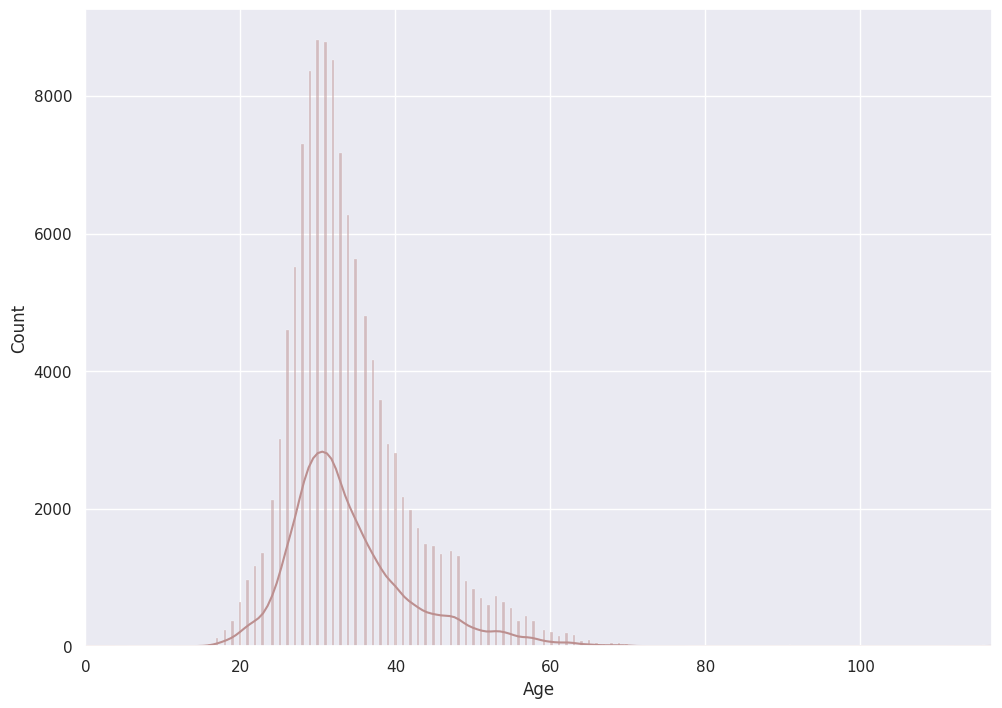

In [ ]:
count_plotted = sns.histplot(x = 'age', data = dataframed, kde = True, color = 'rosybrown')
count_plotted.set(xlabel = "Age")
count_plotted.set(xlim = (0.0000, 117.0000))

# Outliers : Age

[(0.0, 117.0)]

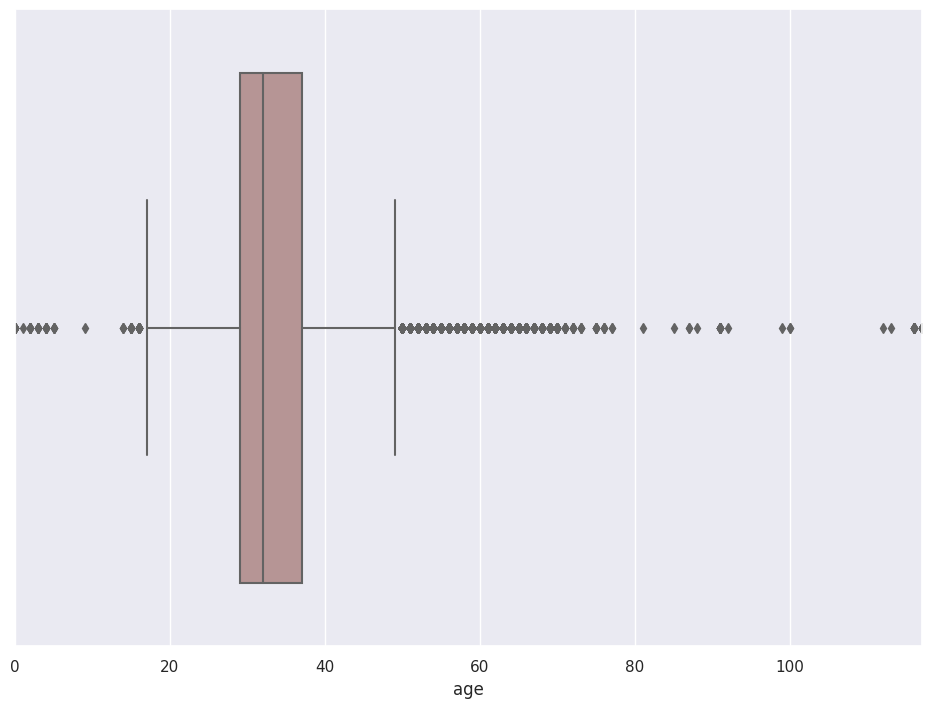

In [ ]:
boxxer_plot = sns.boxplot(x = 'age', data = dataframed, color = 'rosybrown')
boxxer_plot.set(xlim = (0.0000, 117.0000))

# How many outliers in Age Column?

In [ ]:
numpy_array = np.array(dataframed['age'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 17.0000 or greater than 49.0000
There are 6726 outliers.


# Column : Height (in cm)

# Distribution of rows in terms of Height

[(137.16, 193.04)]

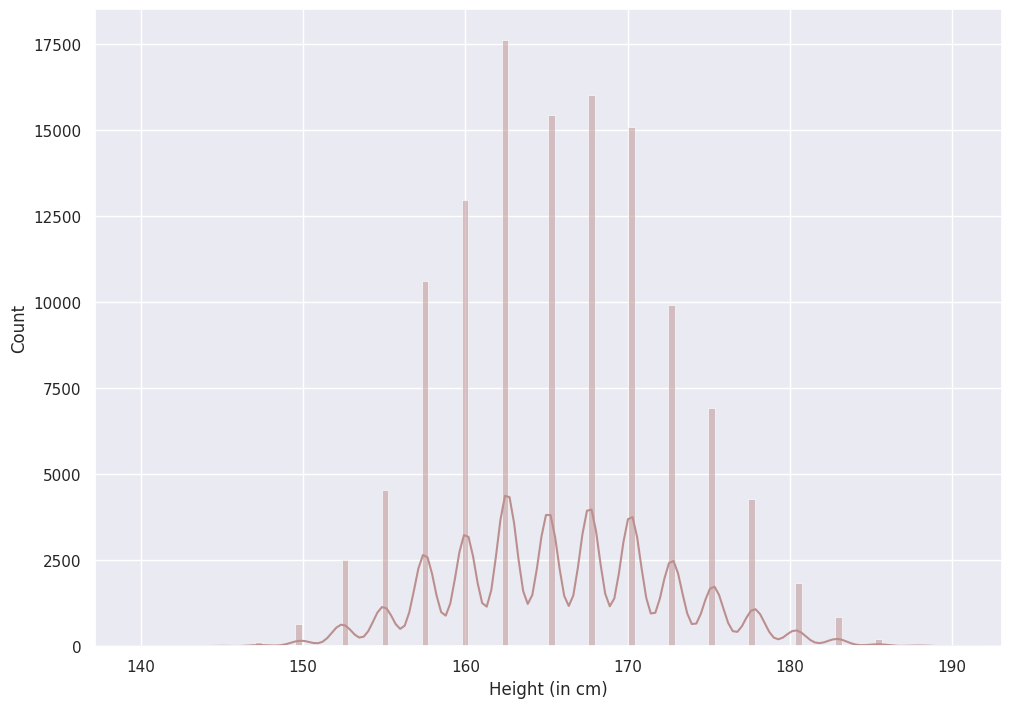

In [ ]:
count_plotted = sns.histplot(x = 'height', data = dataframed, kde = True, color = 'rosybrown')
count_plotted.set(xlabel = "Height (in cm)")
count_plotted.set(xlim = (137.1600, 193.0400))

# Outliers : Height

[(137.16, 193.04)]

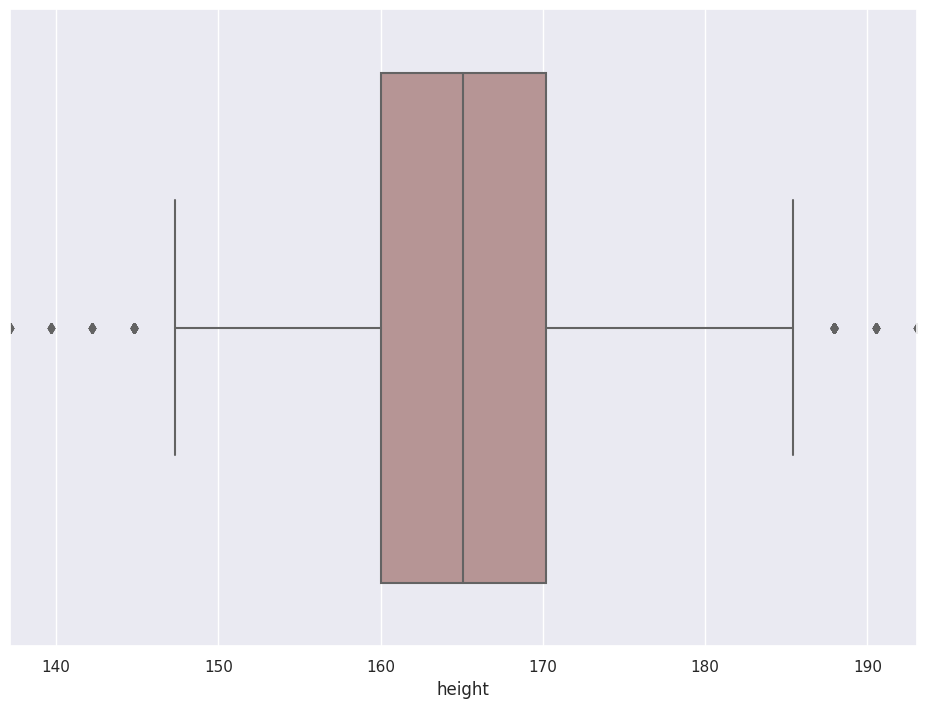

In [ ]:
boxxer_plot = sns.boxplot(x = 'height', data = dataframed, color = 'rosybrown')
boxxer_plot.set(xlim = (137.1600, 193.0400))

# How many outliers in Height Column?

In [ ]:
numpy_array = np.array(dataframed['height'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 144.7800 or greater than 185.4200
There are 185 outliers.


# Column : Size

# Distribution of rows in terms of Size

[(1.0, 7.0)]

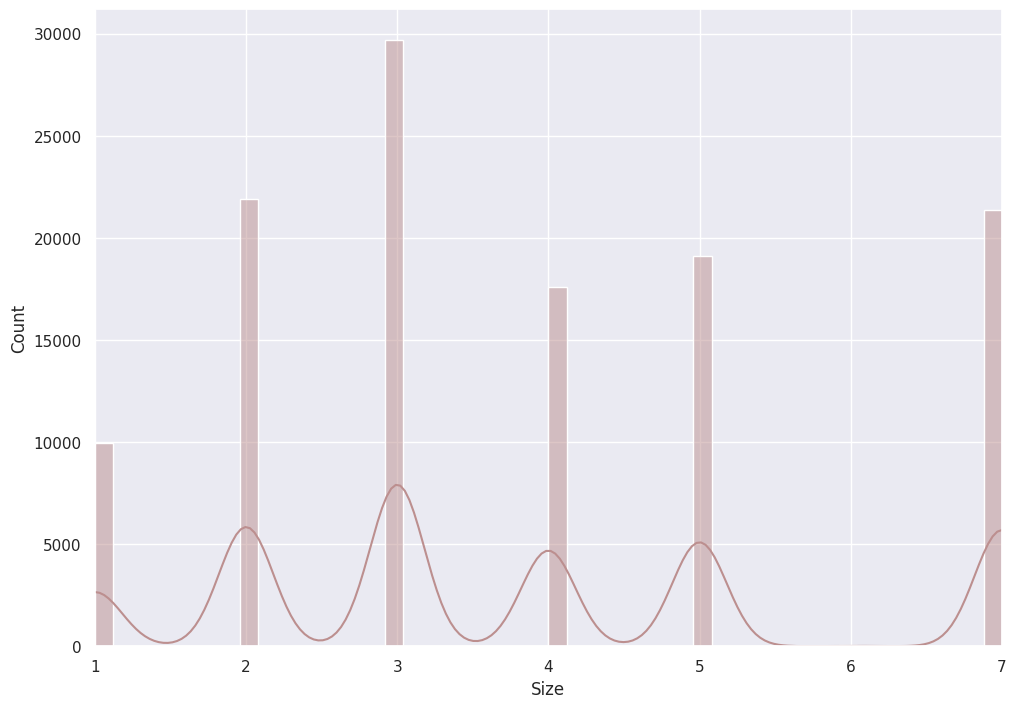

In [ ]:
count_plotted = sns.histplot(x = 'size', data = dataframed, kde = True, color = 'rosybrown')
count_plotted.set(xlabel = "Size")
count_plotted.set(xlim = (1.0000, 7.0000))

# Outliers : Size

[(1.0, 7.0)]

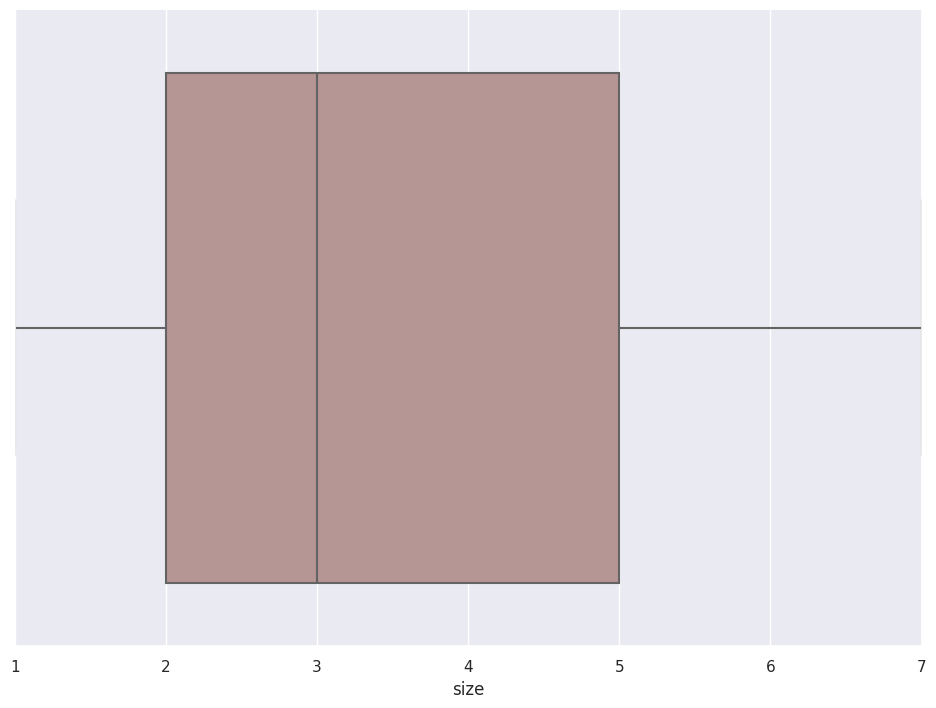

In [ ]:
boxxer_plot = sns.boxplot(x = 'size', data = dataframed, color = 'rosybrown')
boxxer_plot.set(xlim = (1.0000, 7.0000))

# How many outliers in Size Column?

In [ ]:
numpy_array = np.array(dataframed['size'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values greater than 9.5000
There are 0 outliers.


# Column : BMI

# Distribution of rows in terms of BMI

[(7.8283, 54.3236)]

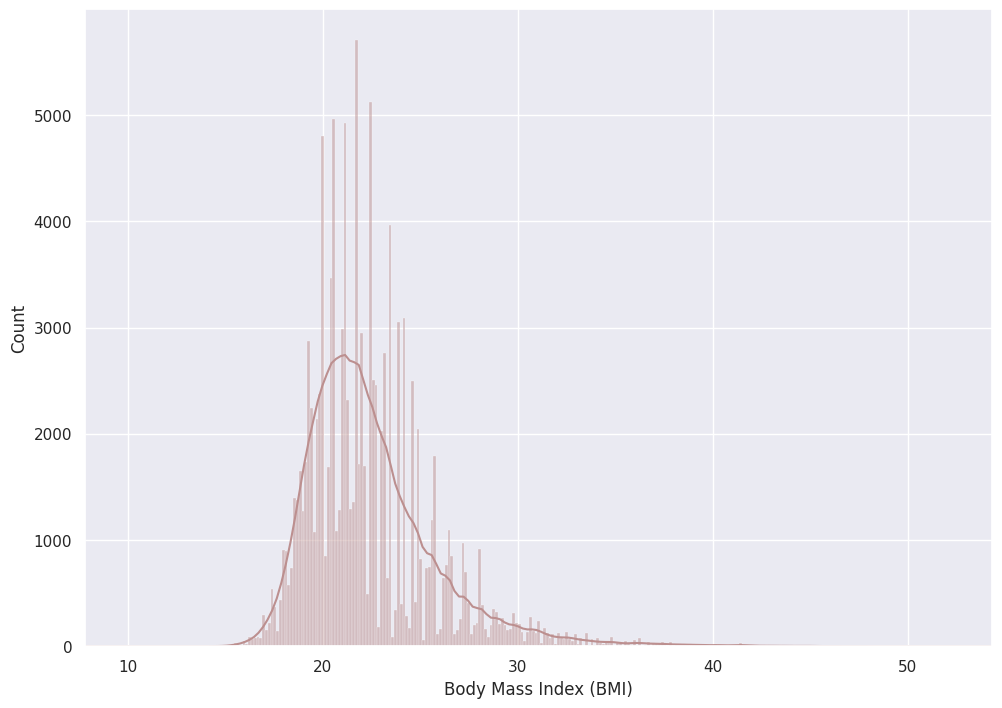

In [ ]:
count_plotted = sns.histplot(x = 'bmi', data = dataframed, kde = True, color = 'rosybrown')
count_plotted.set(xlabel = "Body Mass Index (BMI)")
count_plotted.set(xlim = (7.8283, 54.3236))

# Outliers : BMI

[(7.8283, 54.3236)]

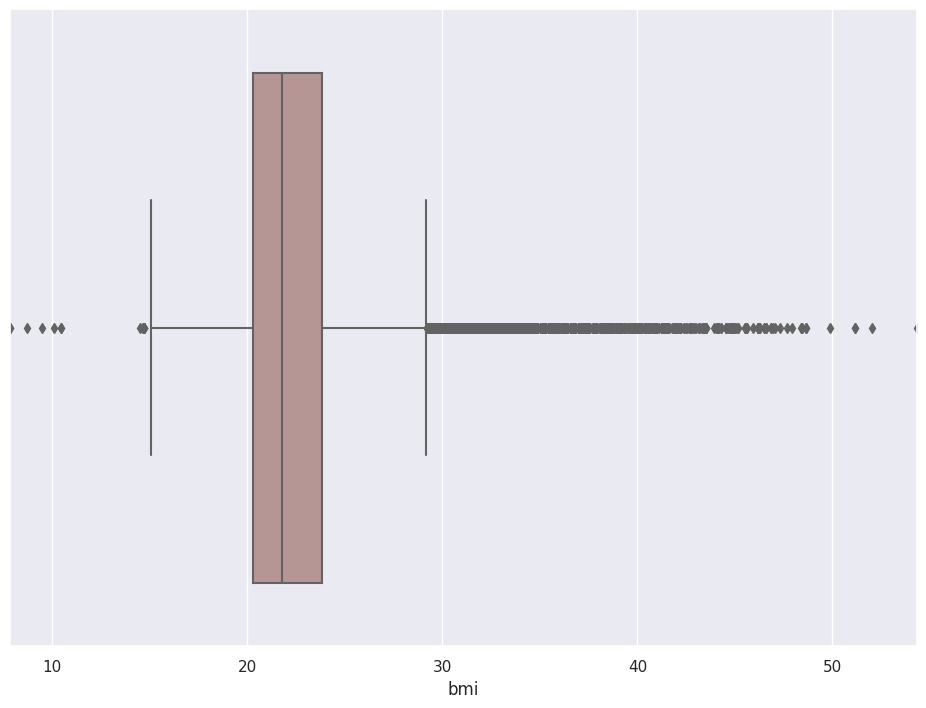

In [ ]:
boxxer_plot = sns.boxplot(x = 'bmi', data = dataframed, color = 'rosybrown')
boxxer_plot.set(xlim = (7.8283, 54.3236))

# How many outliers in BMI Column?

In [ ]:
numpy_array = np.array(dataframed['bmi'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 14.9449 or greater than 29.1782
There are 5166 outliers.


# Types of Rows : XXS Clothing Size Samples

# Column : Weight (in kgs)

# Distribution of rows in terms of Weight

[(22.0, 136.0)]

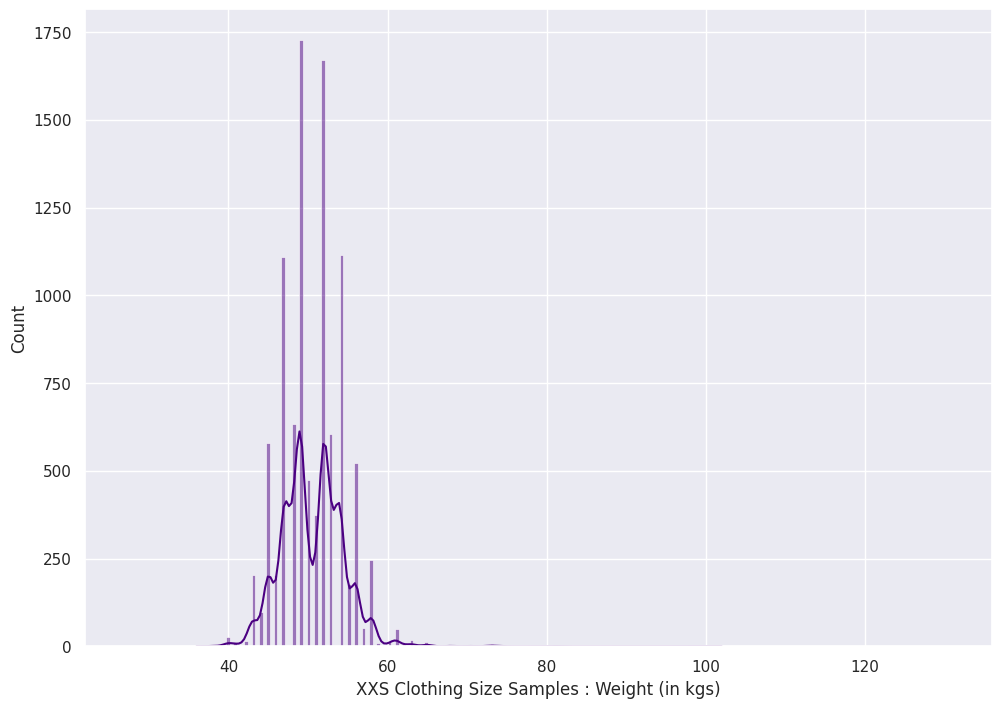

In [ ]:
count_plotted = sns.histplot(x = 'weight', data = dataframed.loc[dataframed['size'] == 1], kde = True, color = 'indigo')
count_plotted.set(xlabel = "XXS Clothing Size Samples : Weight (in kgs)")
count_plotted.set(xlim = (22.0000,136.0000))

# Outliers : Weight

[Text(0.5, 0, 'XXS Clothing Size Samples : Weight (in kgs)')]

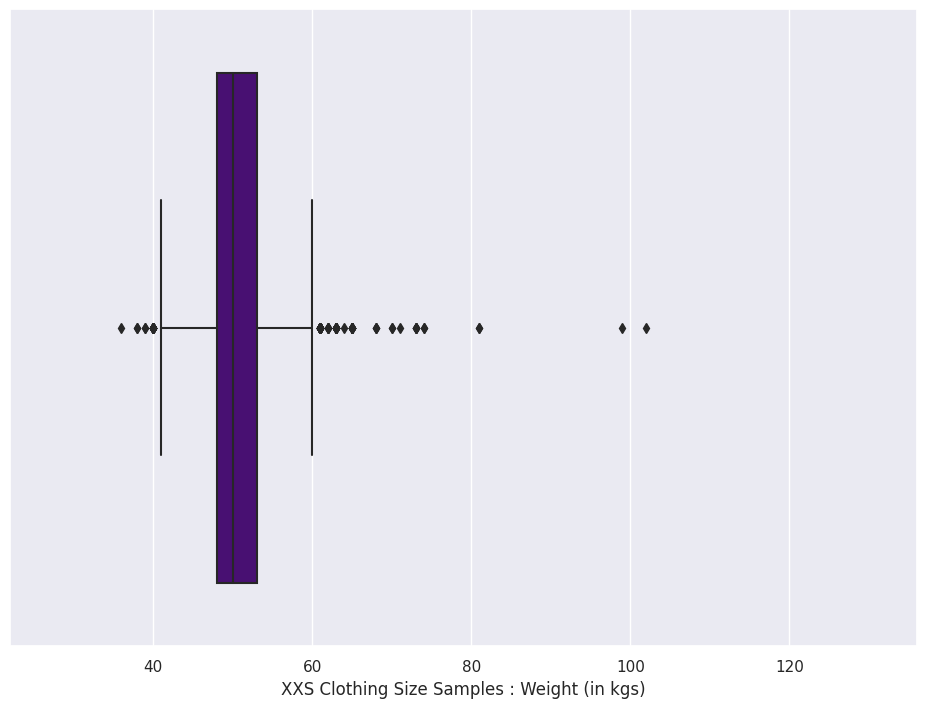

In [ ]:
boxxer_plot = sns.boxplot(x = 'weight', data = dataframed.loc[dataframed['size'] == 1], color = 'indigo')
boxxer_plot.set(xlim = (22.0000,136.0000))
boxxer_plot.set(xlabel = "XXS Clothing Size Samples : Weight (in kgs)")

# How many outliers in Weight Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 1]['weight'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 40.5000 or greater than 60.5000
There are 132 outliers.


# Column : Age

# Distribution of rows in terms of Age

[(0.0, 117.0)]

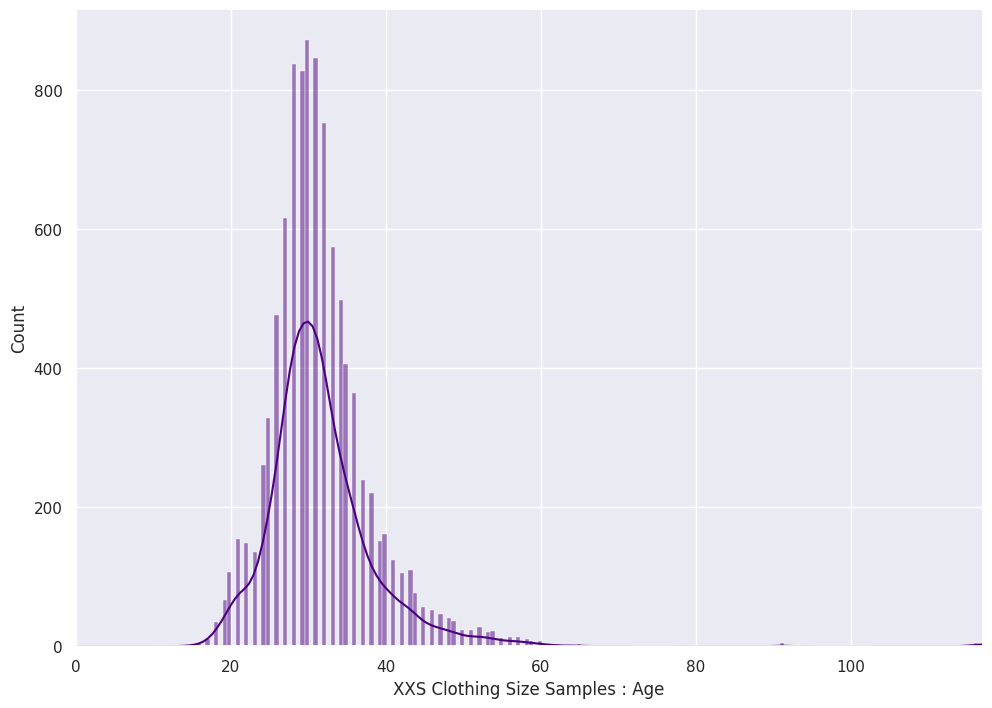

In [ ]:
count_plotted = sns.histplot(x = 'age', data = dataframed.loc[dataframed['size'] == 1], kde = True, color = 'indigo')
count_plotted.set(xlabel = "XXS Clothing Size Samples : Age")
count_plotted.set(xlim = (0.0000, 117.0000))

# Outliers : Age

[Text(0.5, 0, 'XXS Clothing Size Samples : Age')]

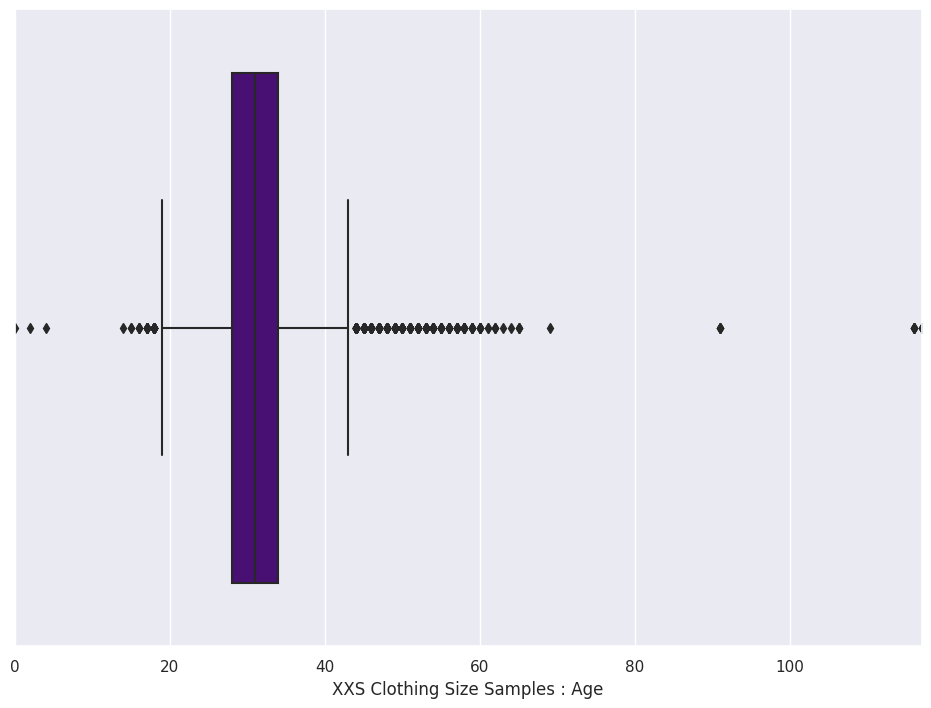

In [ ]:
boxxer_plot = sns.boxplot(x = 'age', data = dataframed.loc[dataframed['size'] == 1], color = 'indigo')
boxxer_plot.set(xlim = (0.0000, 117.0000))
boxxer_plot.set(xlabel = "XXS Clothing Size Samples : Age")

# How many outliers in Age Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 1]['age'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 19.0000 or greater than 43.0000
There are 576 outliers.


# Column : Height (in cm)

# Distribution of rows in terms of Height

[(137.16, 193.04)]

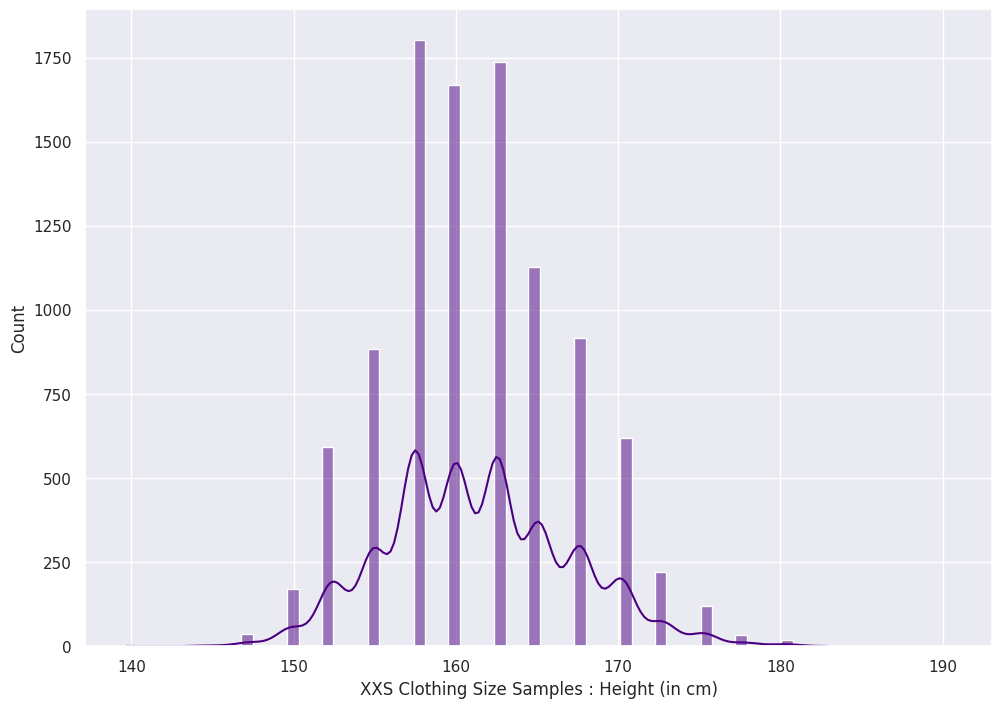

In [ ]:
count_plotted = sns.histplot(x = 'height', data = dataframed.loc[dataframed['size'] == 1], kde = True, color = 'indigo')
count_plotted.set(xlabel = "XXS Clothing Size Samples : Height (in cm)")
count_plotted.set(xlim = (137.1600, 193.0400))

# Outliers : Height

[Text(0.5, 0, 'XXS Clothing Size Samples : Height (in cm)')]

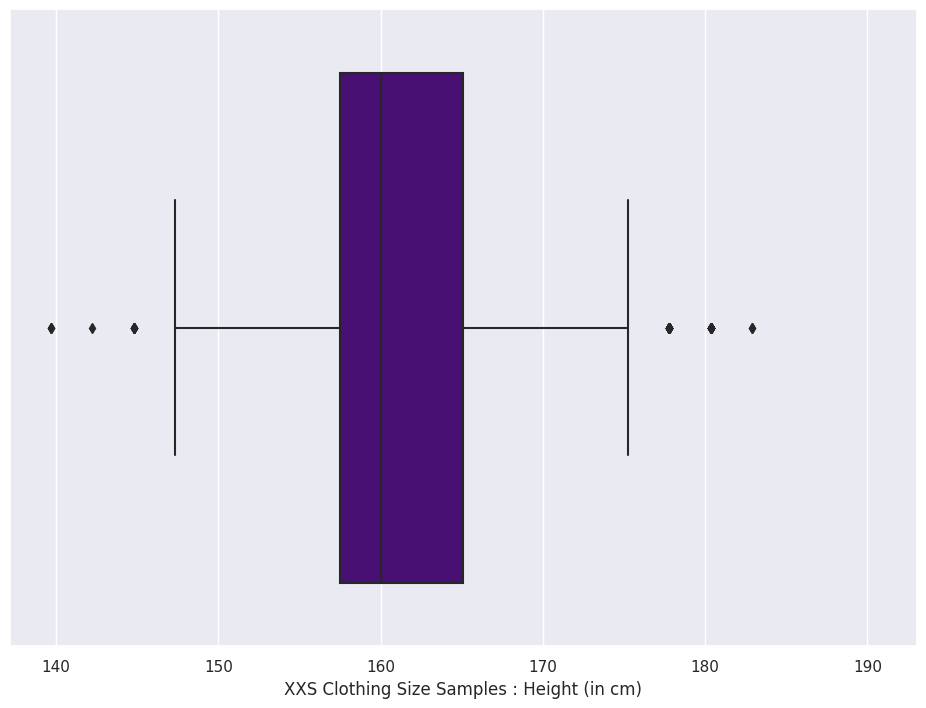

In [ ]:
boxxer_plot = sns.boxplot(x = 'height', data = dataframed.loc[dataframed['size'] == 1], color = 'indigo')
boxxer_plot.set(xlim = (137.1600, 193.0400))
boxxer_plot.set(xlabel = "XXS Clothing Size Samples : Height (in cm)")

# How many outliers in Height Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 1]['height'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 146.0500 or greater than 176.5300
There are 65 outliers.


# Column : Size

# Distribution of rows in terms of Size

[(1.0, 7.0)]

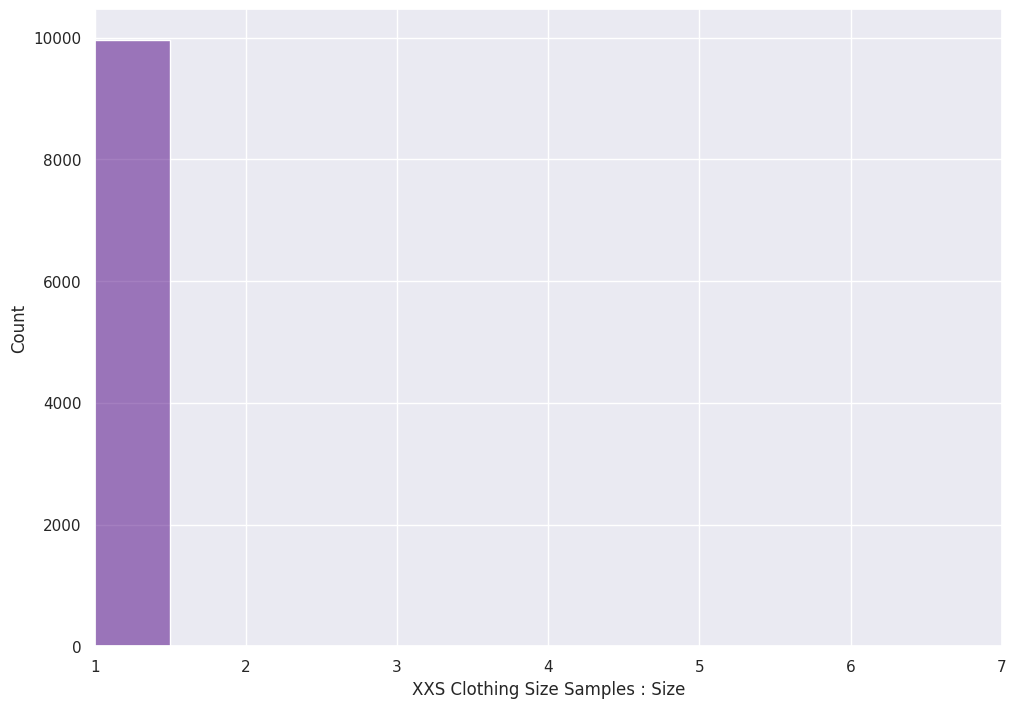

In [ ]:
count_plotted = sns.histplot(x = 'size', data = dataframed.loc[dataframed['size'] == 1], kde = True, color = 'indigo')
count_plotted.set(xlabel = "XXS Clothing Size Samples : Size")
count_plotted.set(xlim = (1.0000, 7.0000))

# Outliers : Size

[Text(0.5, 0, 'XXS Clothing Size Samples : Size')]

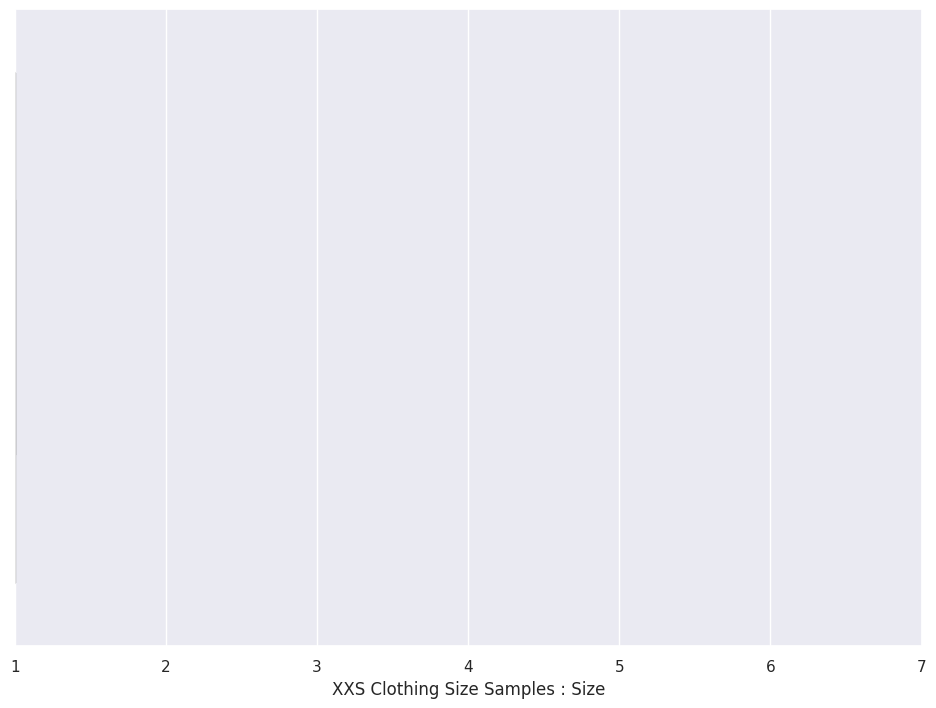

In [ ]:
boxxer_plot = sns.boxplot(x = 'size', data = dataframed.loc[dataframed['size'] == 1], color = 'indigo')
boxxer_plot.set(xlim = (1.0000, 7.0000))
boxxer_plot.set(xlabel = "XXS Clothing Size Samples : Size")

# How many outliers in Size Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 1]['size'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 1.0000 or greater than 1.0000
There are 0 outliers.


# Column : BMI

# Distribution of rows in terms of BMI

[(7.8283, 54.3236)]

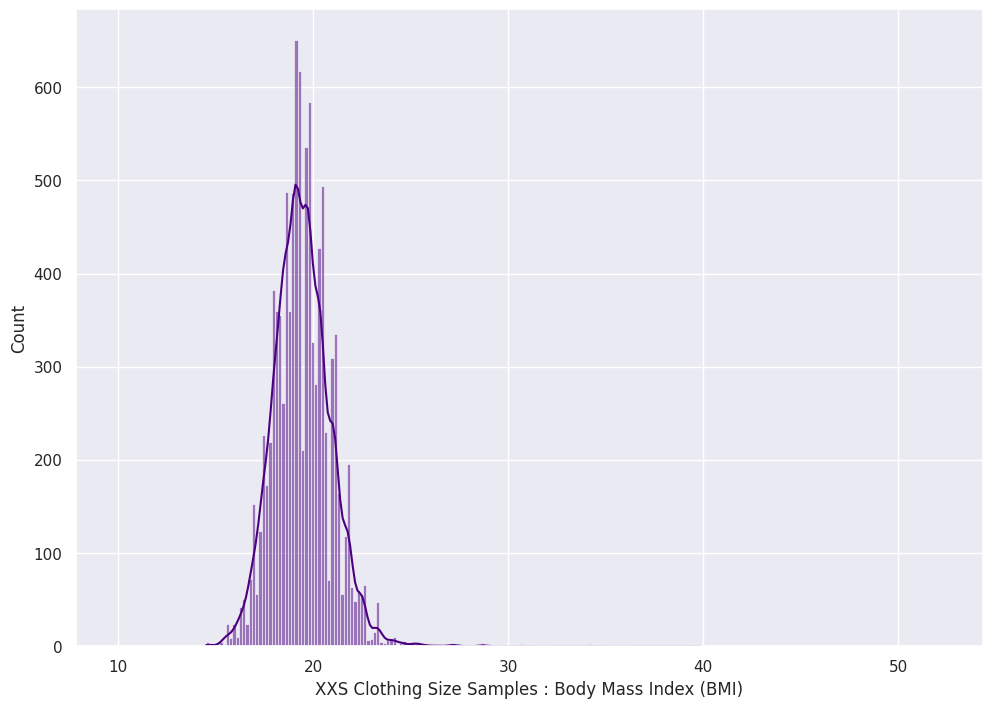

In [ ]:
count_plotted = sns.histplot(x = 'bmi', data = dataframed.loc[dataframed['size'] == 1], kde = True, color = 'indigo')
count_plotted.set(xlabel = "XXS Clothing Size Samples : Body Mass Index (BMI)")
count_plotted.set(xlim = (7.8283, 54.3236))

# Outliers : BMI

[Text(0.5, 0, 'XXS Clothing Size Samples : Body Mass Index (BMI)')]

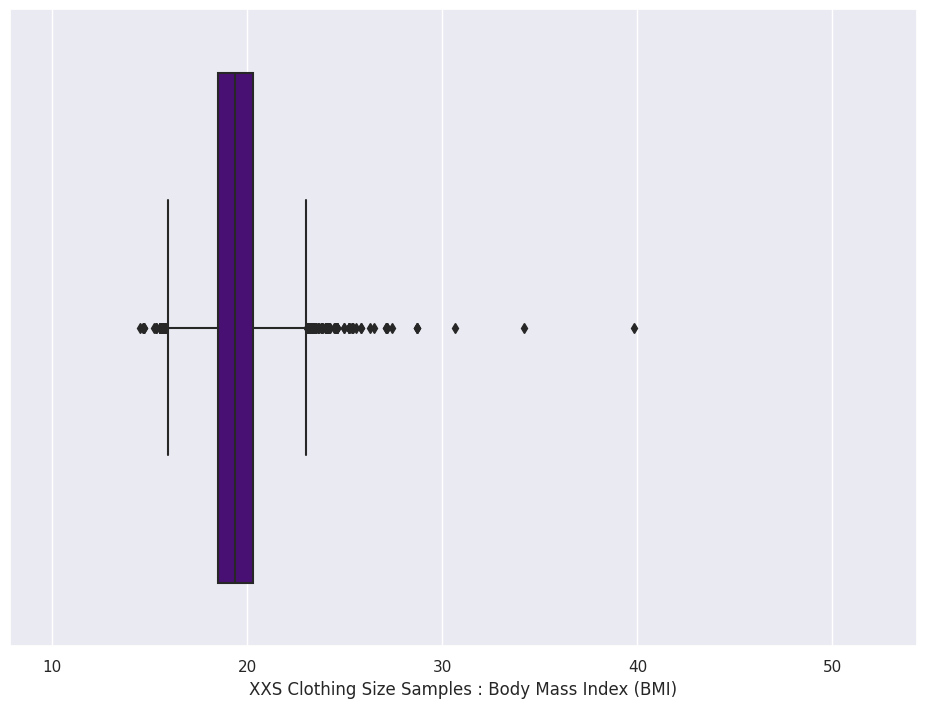

In [ ]:
boxxer_plot = sns.boxplot(x = 'bmi', data = dataframed.loc[dataframed['size'] == 1], color = 'indigo')
boxxer_plot.set(xlim = (7.8283, 54.3236))
boxxer_plot.set(xlabel = "XXS Clothing Size Samples : Body Mass Index (BMI)")

# How many outliers in BMI Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 1]['bmi'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 15.7970 or greater than 23.0137
There are 178 outliers.


# Types of Rows : S Clothing Size Samples

# Column : Weight (in kgs)

# Distribution of rows in terms of Weight

[(22.0, 136.0)]

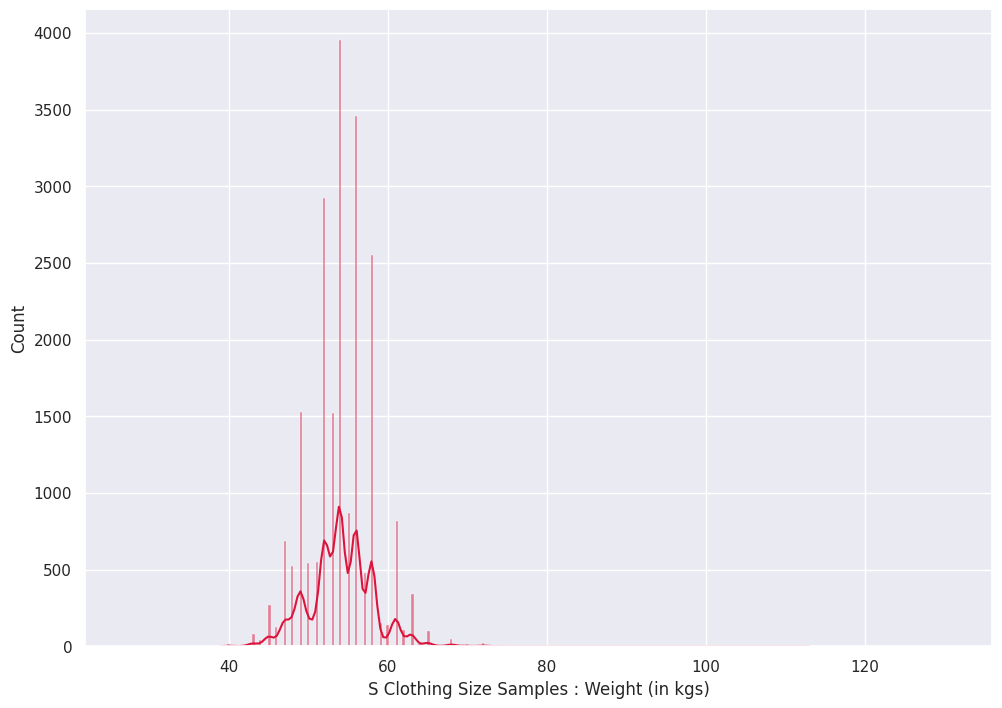

In [ ]:
count_plotted = sns.histplot(x = 'weight', data = dataframed.loc[dataframed['size'] == 2], kde = True, color = 'crimson')
count_plotted.set(xlabel = "S Clothing Size Samples : Weight (in kgs)")
count_plotted.set(xlim = (22.0000, 136.0000))

# Outliers : Weight

[Text(0.5, 0, 'S Clothing Size Samples : Weight (in kgs)')]

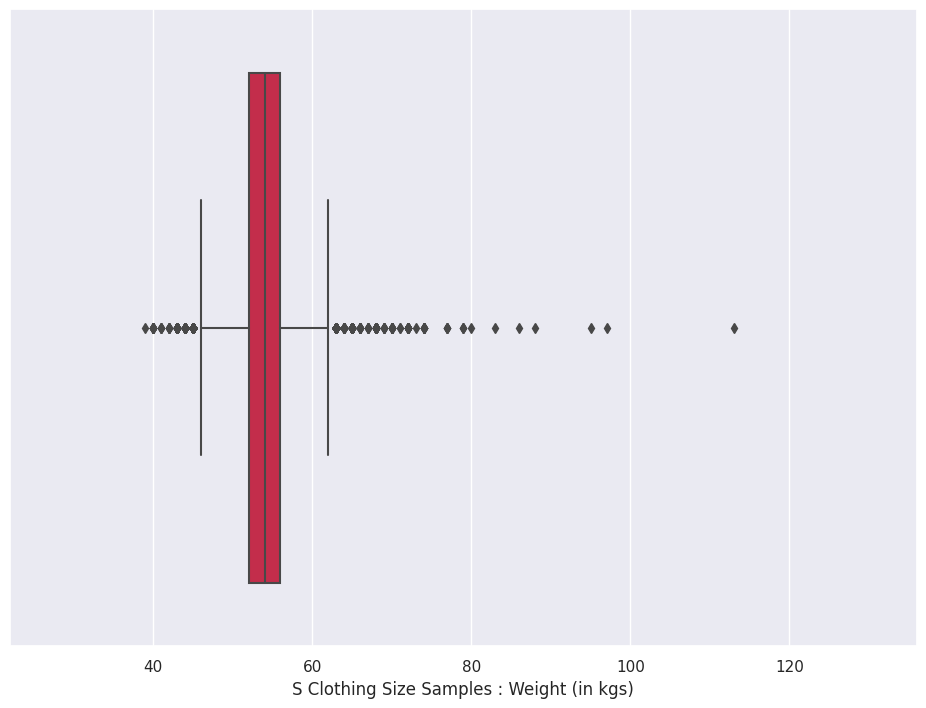

In [ ]:
boxxer_plot = sns.boxplot(x = 'weight', data = dataframed.loc[dataframed['size'] == 2], color = 'crimson')
boxxer_plot.set(xlim = (22.0000, 136.0000))
boxxer_plot.set(xlabel = "S Clothing Size Samples : Weight (in kgs)")

# How many outliers in Weight Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 2]['weight'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 46.0000 or greater than 62.0000
There are 1000 outliers.


# Column : Age

# Distribution of rows in terms of Age

[(0.0, 117.0)]

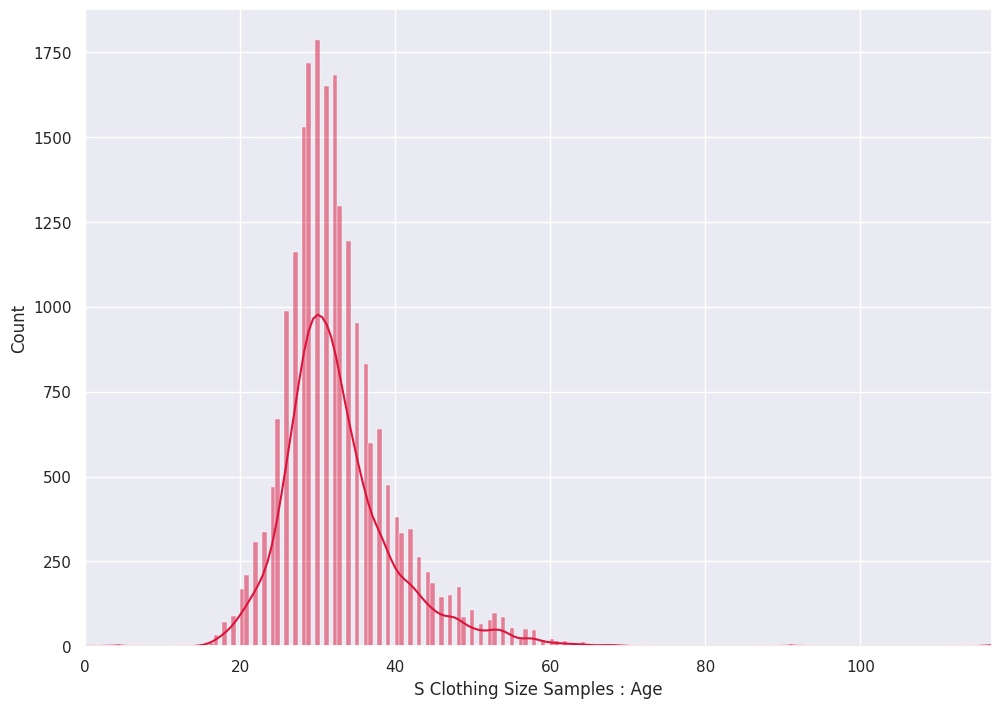

In [ ]:
count_plotted = sns.histplot(x = 'age', data = dataframed.loc[dataframed['size'] == 2], kde = True, color = 'crimson')
count_plotted.set(xlabel = "S Clothing Size Samples : Age")
count_plotted.set(xlim = (0.0000, 117.0000))

# Outliers : Age

[Text(0.5, 0, 'S Clothing Size Samples : Age')]

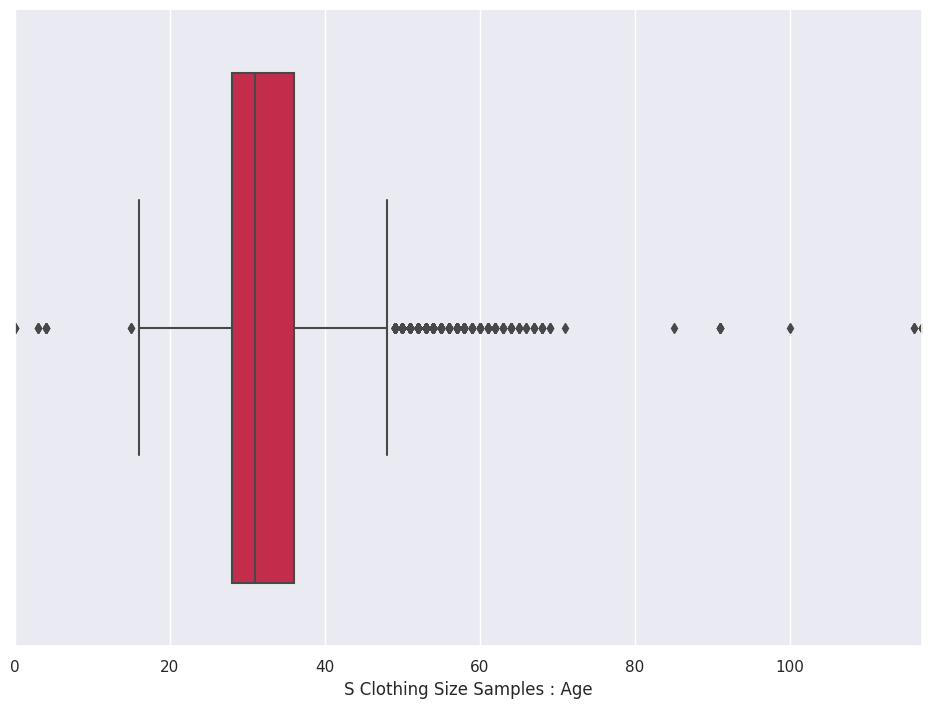

In [ ]:
boxxer_plot = sns.boxplot(x = 'age', data = dataframed.loc[dataframed['size'] == 2], color = 'crimson')
boxxer_plot.set(xlim = (0.0000, 117.0000))
boxxer_plot.set(xlabel = "S Clothing Size Samples : Age")

# How many outliers in Age Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 2]['age'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 16.0000 or greater than 48.0000
There are 847 outliers.


# Column : Height (in cm)

# Distribution of rows in terms of Height

[(137.16, 193.04)]

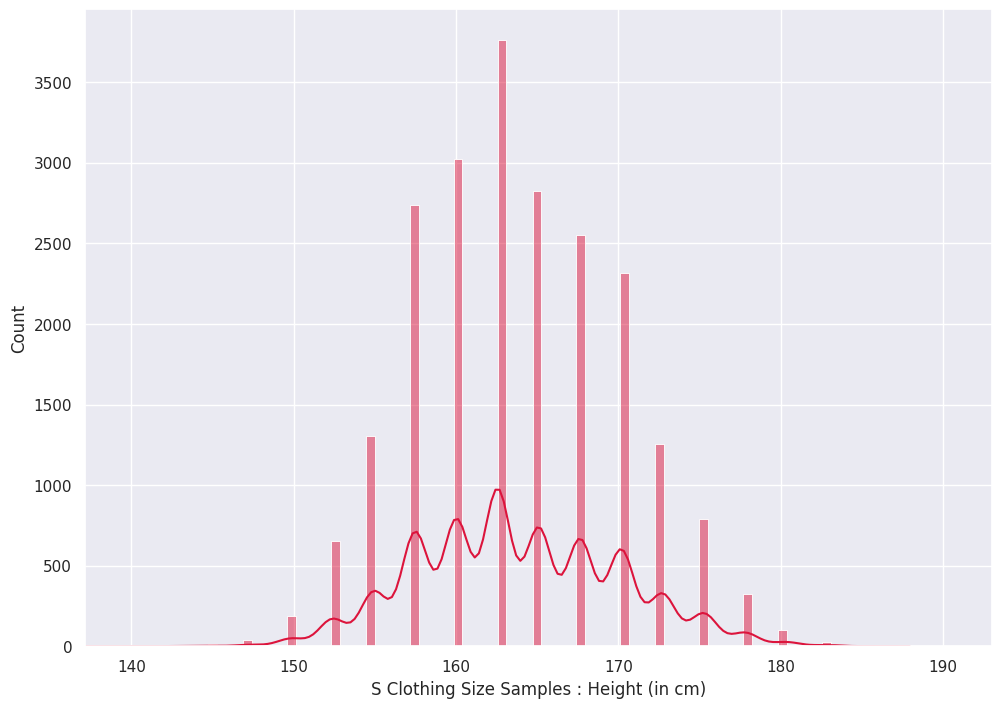

In [ ]:
count_plotted = sns.histplot(x = 'height', data = dataframed.loc[dataframed['size'] == 2], kde = True, color = 'crimson')
count_plotted.set(xlabel = "S Clothing Size Samples : Height (in cm)")
count_plotted.set(xlim = (137.1600, 193.0400))

# Outliers : Height

[Text(0.5, 0, 'S Clothing Size Samples : Height (in cm)')]

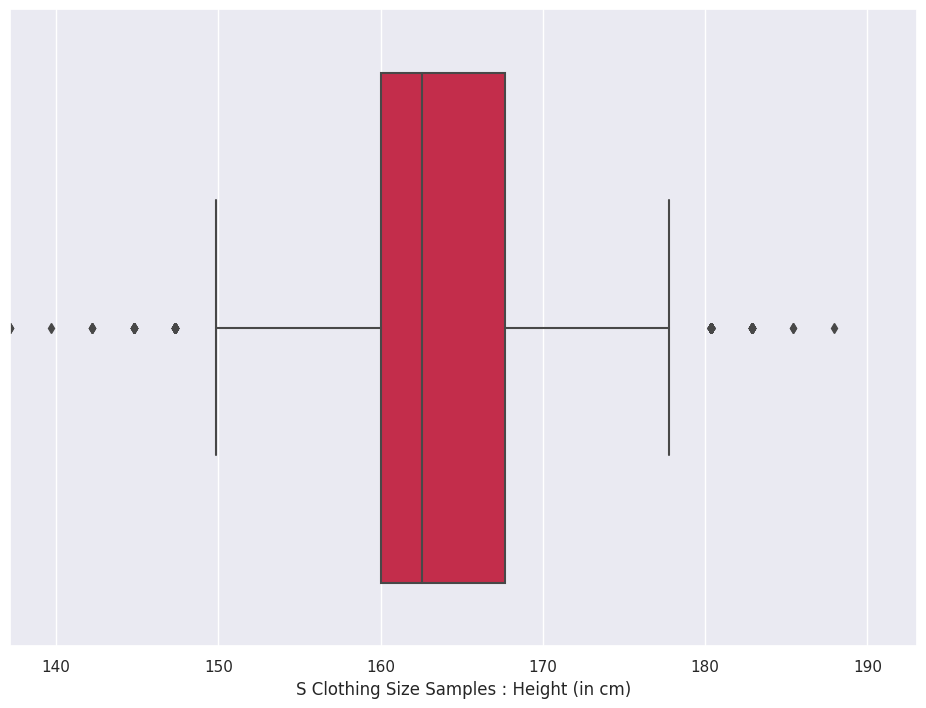

In [ ]:
boxxer_plot = sns.boxplot(x = 'height', data = dataframed.loc[dataframed['size'] == 2], color = 'crimson')
boxxer_plot.set(xlim = (137.1600, 193.0400))
boxxer_plot.set(xlabel = "S Clothing Size Samples : Height (in cm)")

# How many outliers in Height Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 2]['height'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 148.5900 or greater than 179.0700
There are 189 outliers.


# Column : Size

# Distribution of rows in terms of Size

[(1.0, 7.0)]

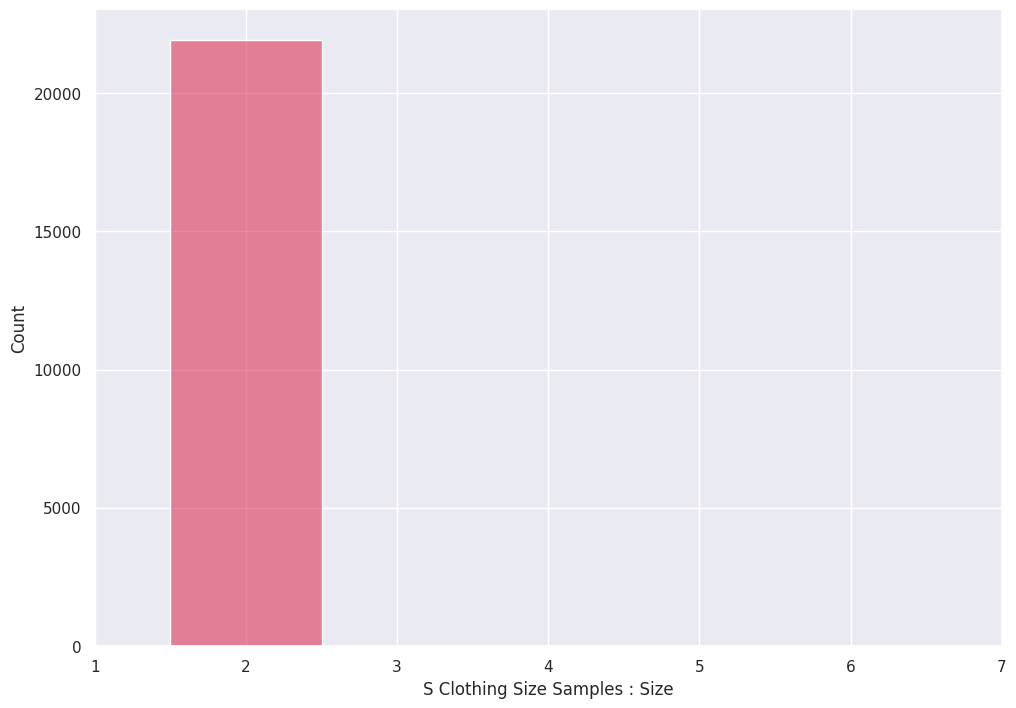

In [ ]:
count_plotted = sns.histplot(x = 'size', data = dataframed.loc[dataframed['size'] == 2], kde = True, color = 'crimson')
count_plotted.set(xlabel = "S Clothing Size Samples : Size")
count_plotted.set(xlim = (1.0000, 7.0000))

# Outliers : Size

[Text(0.5, 0, 'S Clothing Size Samples : Size')]

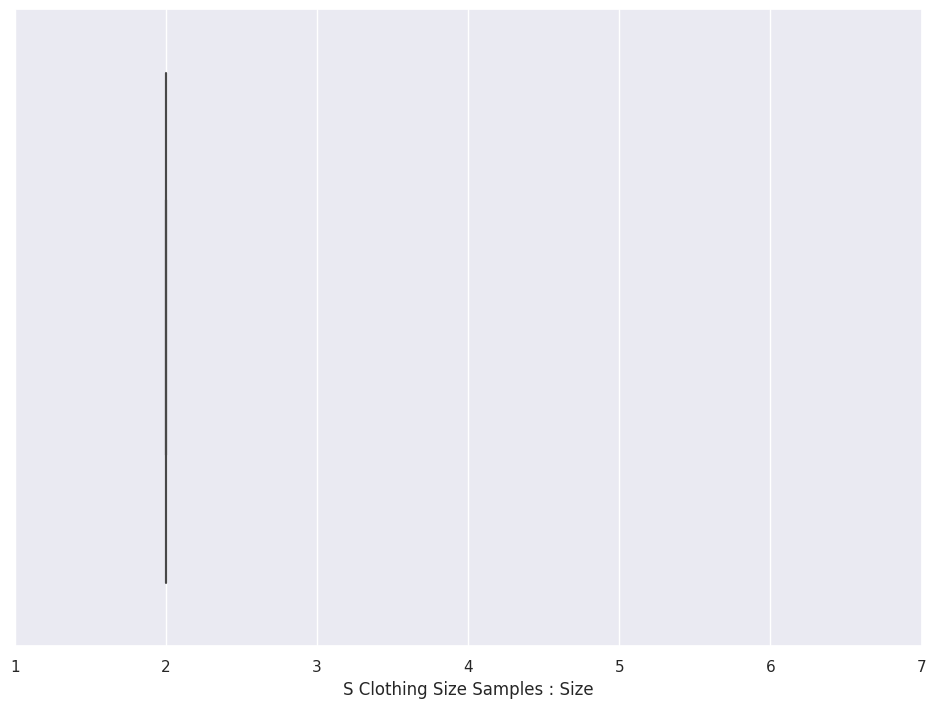

In [ ]:
boxxer_plot = sns.boxplot(x = 'size', data = dataframed.loc[dataframed['size'] == 2], color = 'crimson')
boxxer_plot.set(xlim = (1.0000, 7.0000))
boxxer_plot.set(xlabel = "S Clothing Size Samples : Size")

# How many outliers in Size Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 2]['size'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 2.0000 or greater than 2.0000
There are 0 outliers.


# Column : BMI

# Distribution of rows in terms of BMI

[(7.8283, 54.3236)]

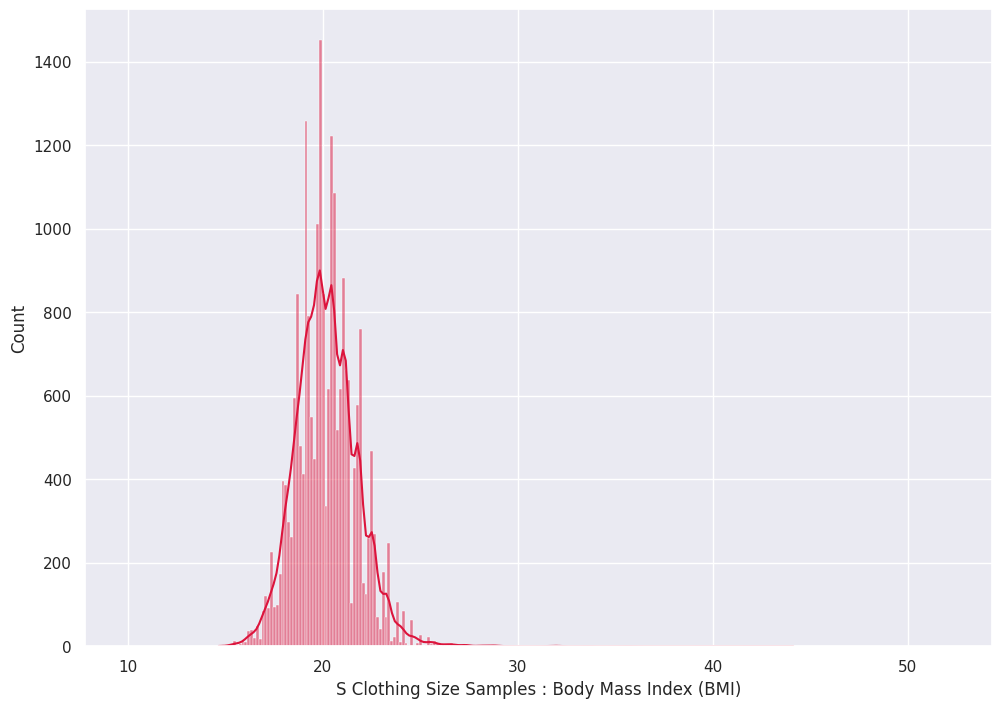

In [ ]:
count_plotted = sns.histplot(x = 'bmi', data = dataframed.loc[dataframed['size'] == 2], kde = True, color = 'crimson')
count_plotted.set(xlabel = "S Clothing Size Samples : Body Mass Index (BMI)")
count_plotted.set(xlim = (7.8283, 54.3236))

# Outliers : BMI

[Text(0.5, 0, 'S Clothing Size Samples : Body Mass Index (BMI)')]

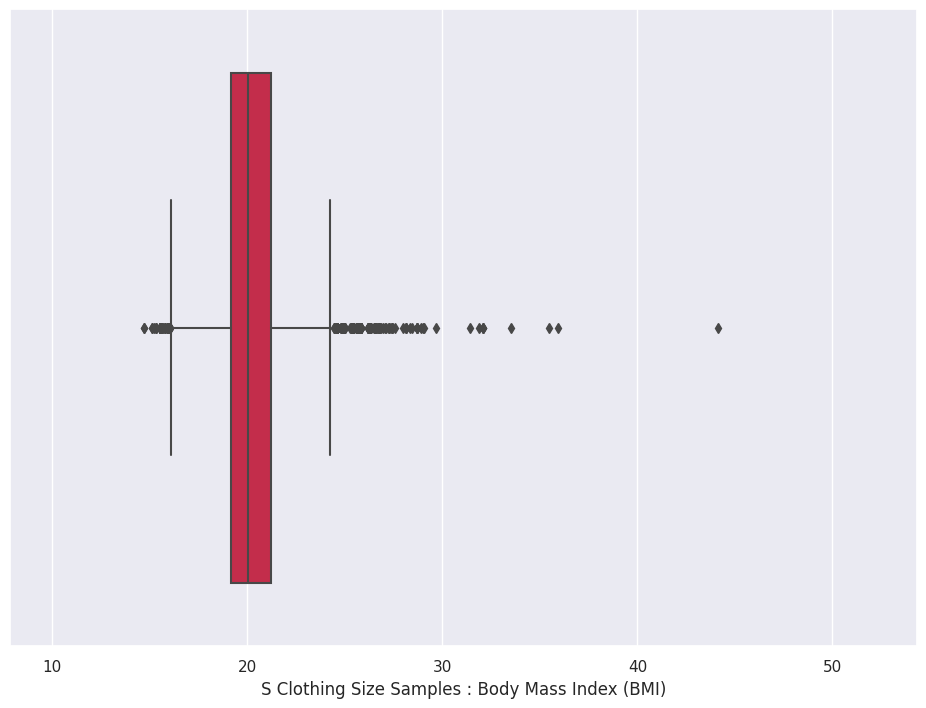

In [ ]:
boxxer_plot = sns.boxplot(x = 'bmi', data = dataframed.loc[dataframed['size'] == 2], color = 'crimson')
boxxer_plot.set(xlim = (7.8283, 54.3236))
boxxer_plot.set(xlabel = "S Clothing Size Samples : Body Mass Index (BMI)")

# How many outliers in BMI Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 2]['bmi'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 16.0524 or greater than 24.2749
There are 265 outliers.


# Types of Rows : M Clothing Size Samples

# Column : Weight (in kgs)

# Distribution of rows in terms of Weight

[(22.0, 136.0)]

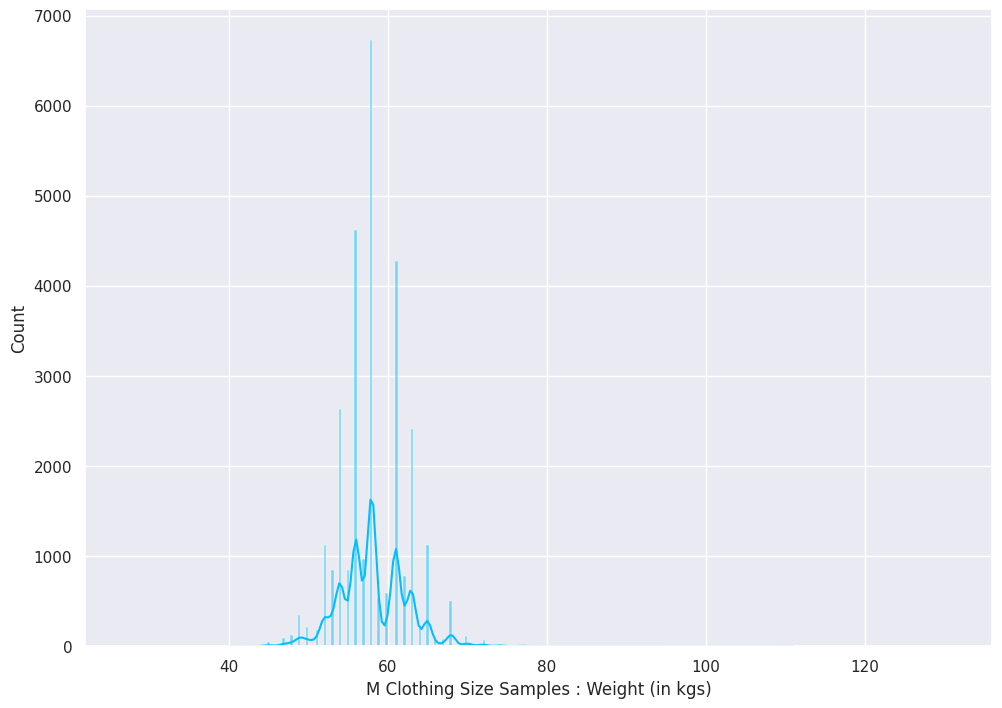

In [ ]:
count_plotted = sns.histplot(x = 'weight', data = dataframed.loc[dataframed['size'] == 3], kde = True, color = 'deepskyblue')
count_plotted.set(xlabel = "M Clothing Size Samples : Weight (in kgs)")
count_plotted.set(xlim = (22.0000, 136.0000))

# Outliers : Weight

[Text(0.5, 0, 'M Clothing Size Samples : Weight (in kgs)')]

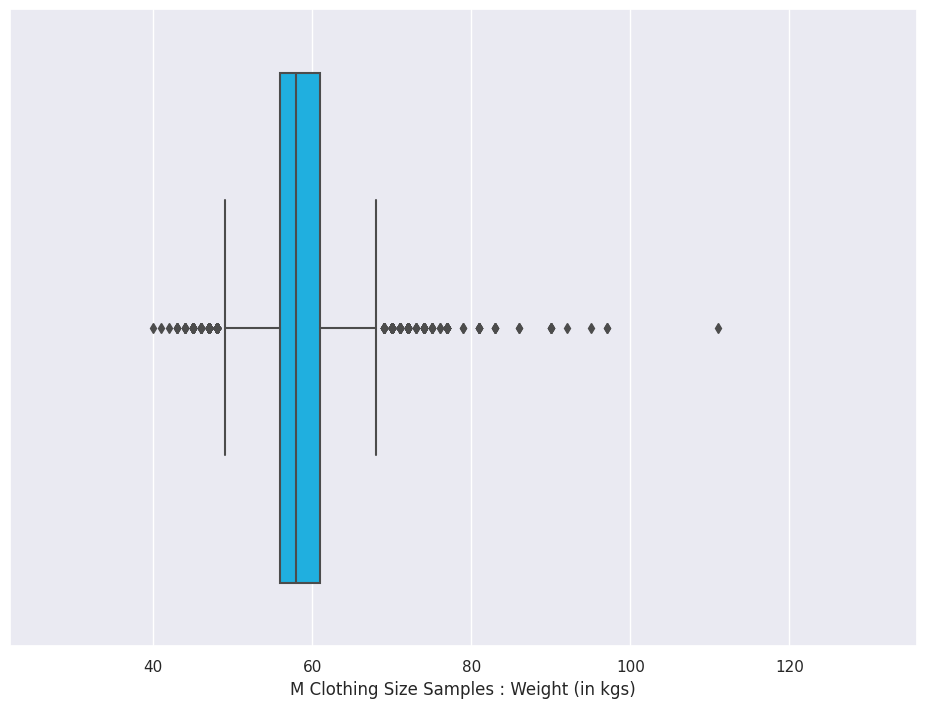

In [ ]:
boxxer_plot = sns.boxplot(x = 'weight', data = dataframed.loc[dataframed['size'] == 3], color = 'deepskyblue')
boxxer_plot.set(xlim = (22.0000, 136.0000))
boxxer_plot.set(xlabel = "M Clothing Size Samples : Weight (in kgs)")

# How many outliers in Weight Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 3]['weight'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 48.5000 or greater than 68.5000
There are 580 outliers.


# Column : Age

# Distribution of rows in terms of Age

[(0.0, 117.0)]

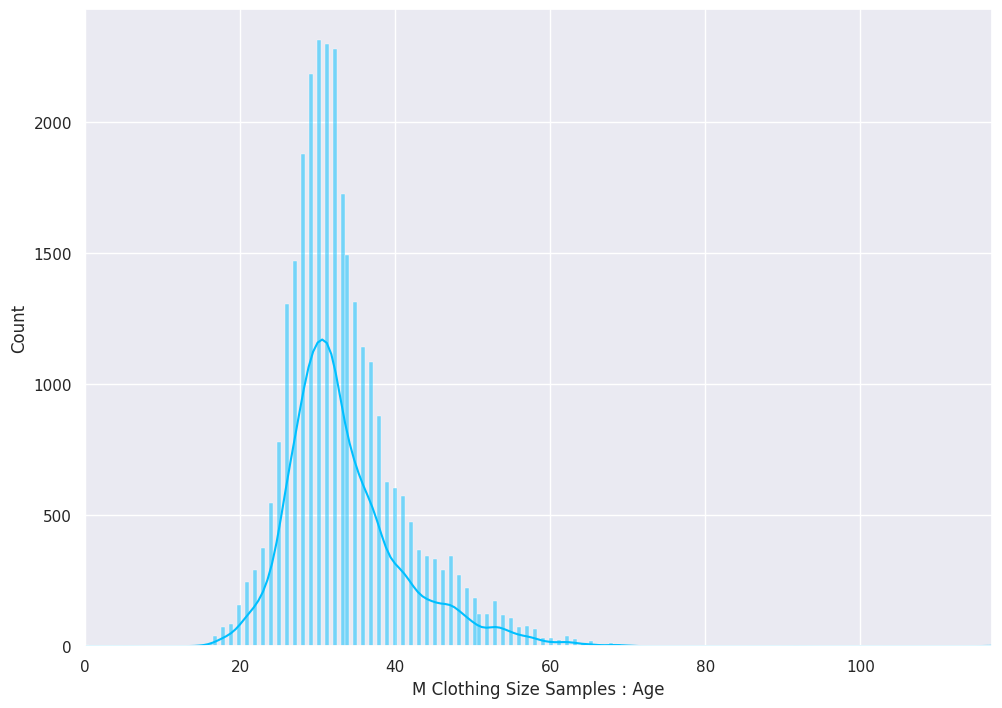

In [ ]:
count_plotted = sns.histplot(x = 'age', data = dataframed.loc[dataframed['size'] == 3], kde = True, color = 'deepskyblue')
count_plotted.set(xlabel = "M Clothing Size Samples : Age")
count_plotted.set(xlim = (0.0000, 117.0000))

# Outliers : Age

[Text(0.5, 0, 'M Clothing Size Samples : Age')]

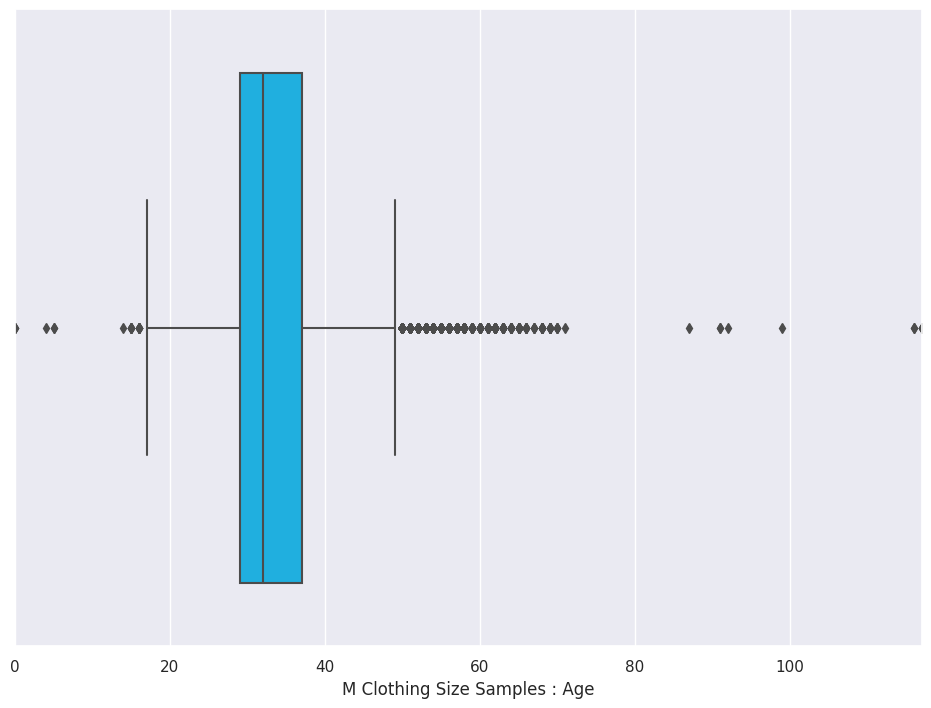

In [ ]:
boxxer_plot = sns.boxplot(x = 'age', data = dataframed.loc[dataframed['size'] == 3], color = 'deepskyblue')
boxxer_plot.set(xlim = (0.0000, 117.0000))
boxxer_plot.set(xlabel = "M Clothing Size Samples : Age")

# How many outliers in Age Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 3]['age'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 17.0000 or greater than 49.0000
There are 1304 outliers.


# Column : Height (in cm)

# Distribution of rows in terms of Height

[(137.16, 193.04)]

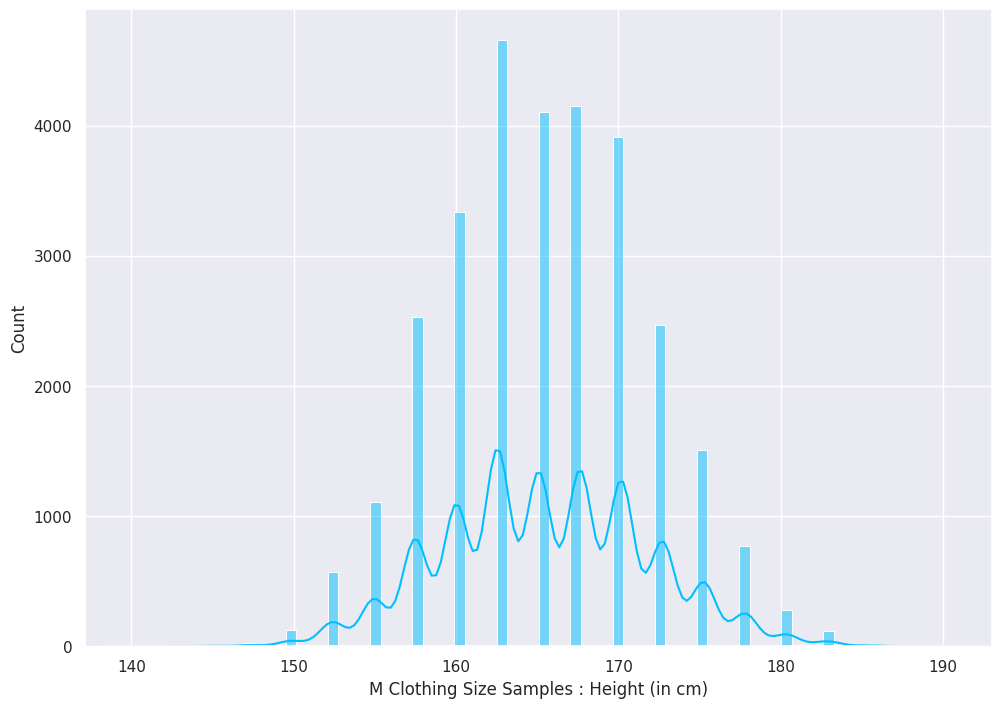

In [ ]:
count_plotted = sns.histplot(x = 'height', data = dataframed.loc[dataframed['size'] == 3], kde = True, color = 'deepskyblue')
count_plotted.set(xlabel = "M Clothing Size Samples : Height (in cm)")
count_plotted.set(xlim = (137.1600, 193.0400))

# Outliers : Height

[Text(0.5, 0, 'M Clothing Size Samples : Height (in cm)')]

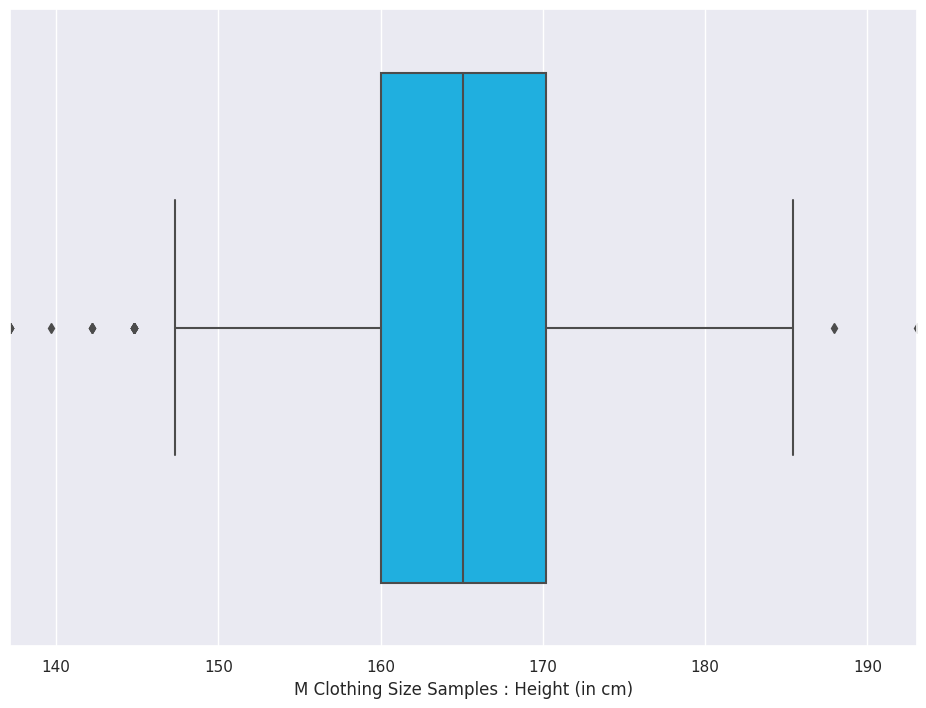

In [ ]:
boxxer_plot = sns.boxplot(x = 'height', data = dataframed.loc[dataframed['size'] == 3], color = 'deepskyblue')
boxxer_plot.set(xlim = (137.1600, 193.0400))
boxxer_plot.set(xlabel = "M Clothing Size Samples : Height (in cm)")

# How many outliers in Height Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 3]['height'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 144.7800 or greater than 185.4200
There are 22 outliers.


# Column : Size

# Distribution of rows in terms of Size

[(1.0, 7.0)]

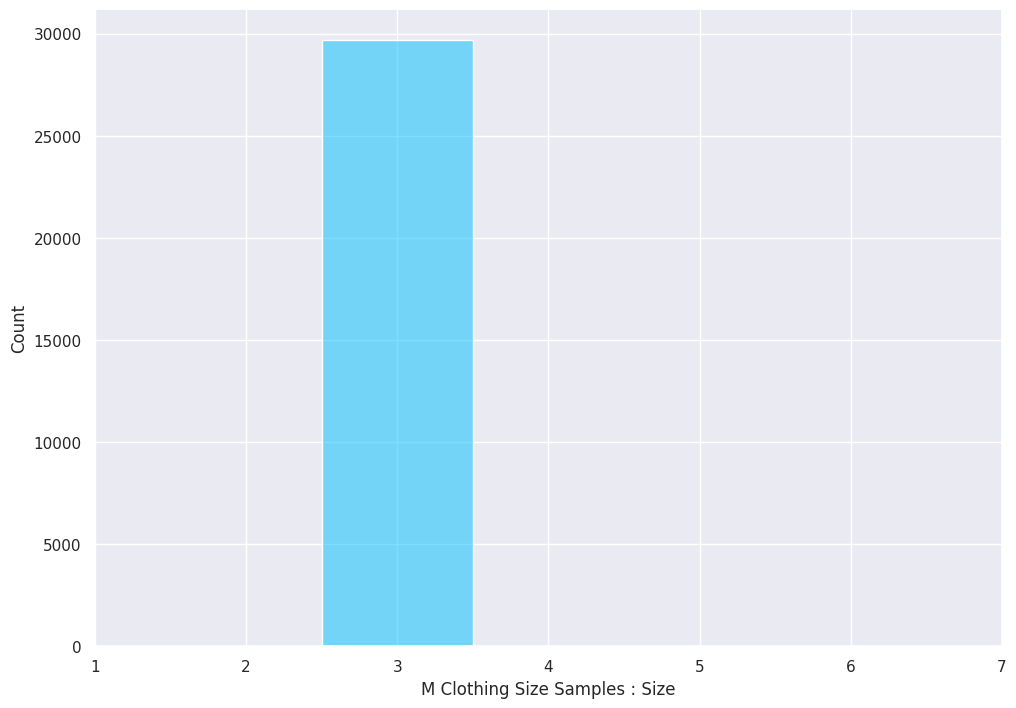

In [ ]:
count_plotted = sns.histplot(x = 'size', data = dataframed.loc[dataframed['size'] == 3], kde = True, color = 'deepskyblue')
count_plotted.set(xlabel = "M Clothing Size Samples : Size")
count_plotted.set(xlim = (1.0000, 7.0000))

# Outliers : Size

[Text(0.5, 0, 'M Clothing Size Samples : Size')]

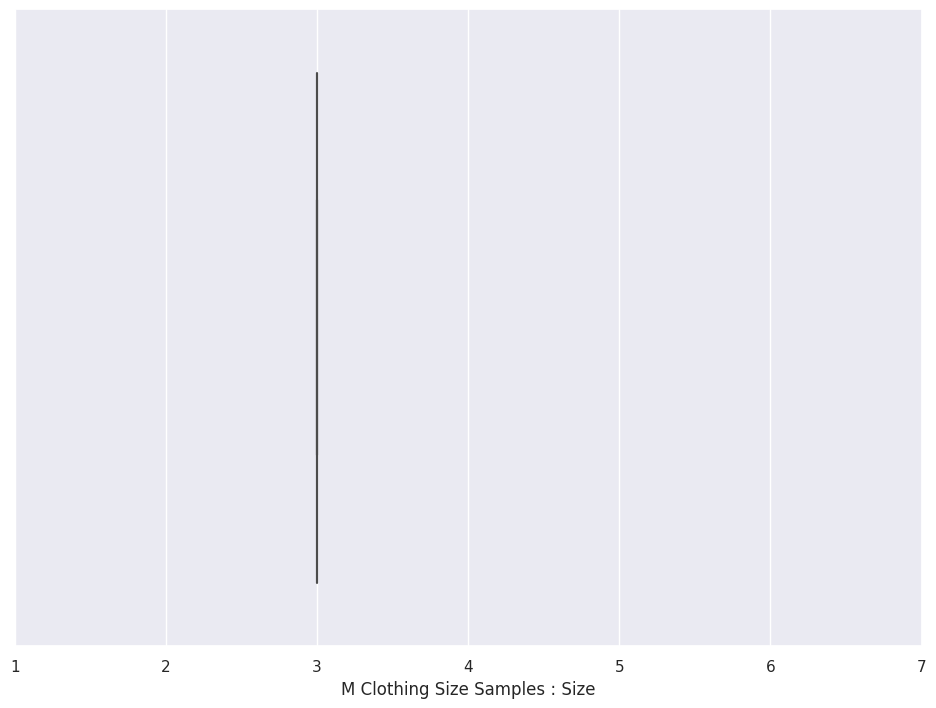

In [ ]:
boxxer_plot = sns.boxplot(x = 'size', data = dataframed.loc[dataframed['size'] == 3], color = 'deepskyblue')
boxxer_plot.set(xlim = (1.0000, 7.0000))
boxxer_plot.set(xlabel = "M Clothing Size Samples : Size")

# How many outliers in Size Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 3]['size'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 3.0000 or greater than 3.0000
There are 0 outliers.


# Column : BMI

# Distribution of rows in terms of BMI

[(7.8283, 54.3236)]

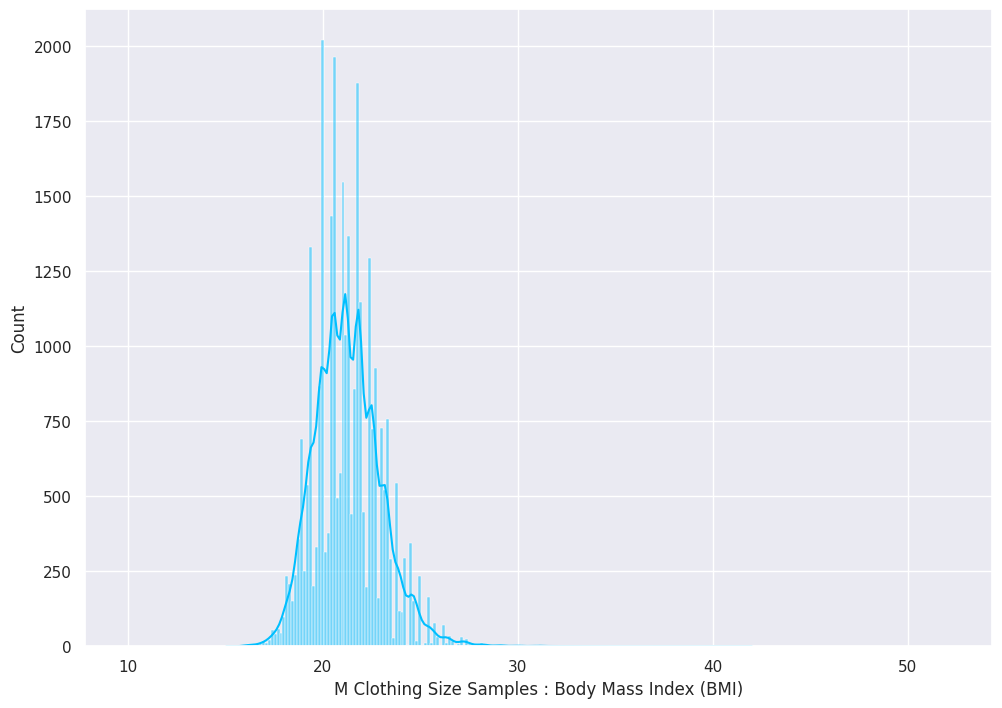

In [ ]:
count_plotted = sns.histplot(x = 'bmi', data = dataframed.loc[dataframed['size'] == 3], kde = True, color = 'deepskyblue')
count_plotted.set(xlabel = "M Clothing Size Samples : Body Mass Index (BMI)")
count_plotted.set(xlim = (7.8283, 54.3236))

# Outliers : BMI

[Text(0.5, 0, 'M Clothing Size Samples : Body Mass Index (BMI)')]

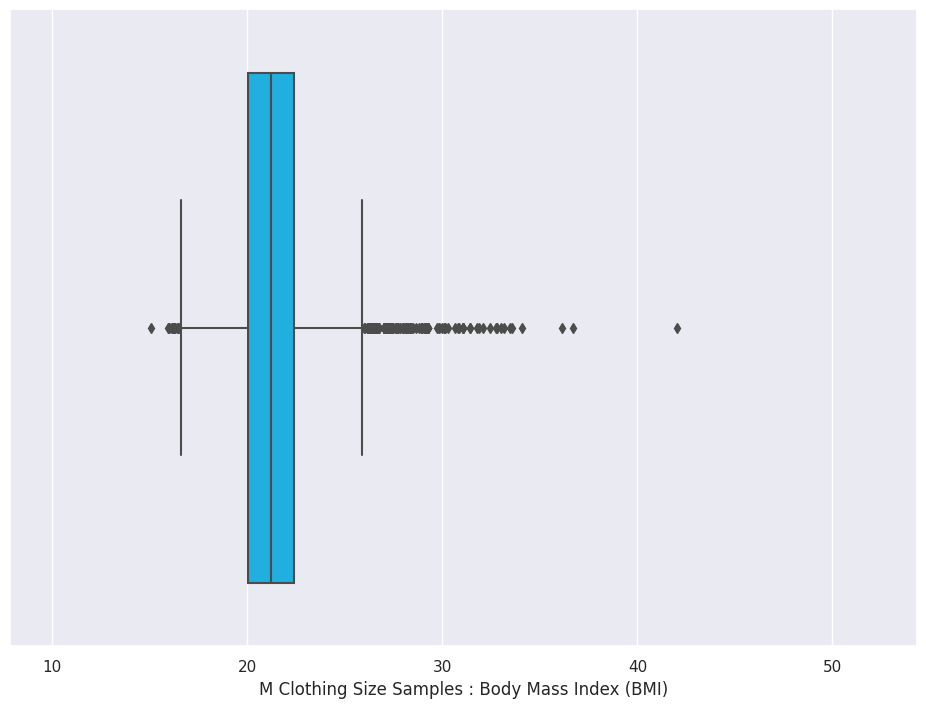

In [ ]:
boxxer_plot = sns.boxplot(x = 'bmi', data = dataframed.loc[dataframed['size'] == 3], color = 'deepskyblue')
boxxer_plot.set(xlim = (7.8283, 54.3236))
boxxer_plot.set(xlabel = "M Clothing Size Samples : Body Mass Index (BMI)")

# How many outliers in BMI Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 3]['bmi'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 16.4988 or greater than 25.9067
There are 305 outliers.


# Types of Rows : L Clothing Size Samples

# Column : Weight (in kgs)

# Distribution of rows in terms of Weight

[(22.0, 136.0)]

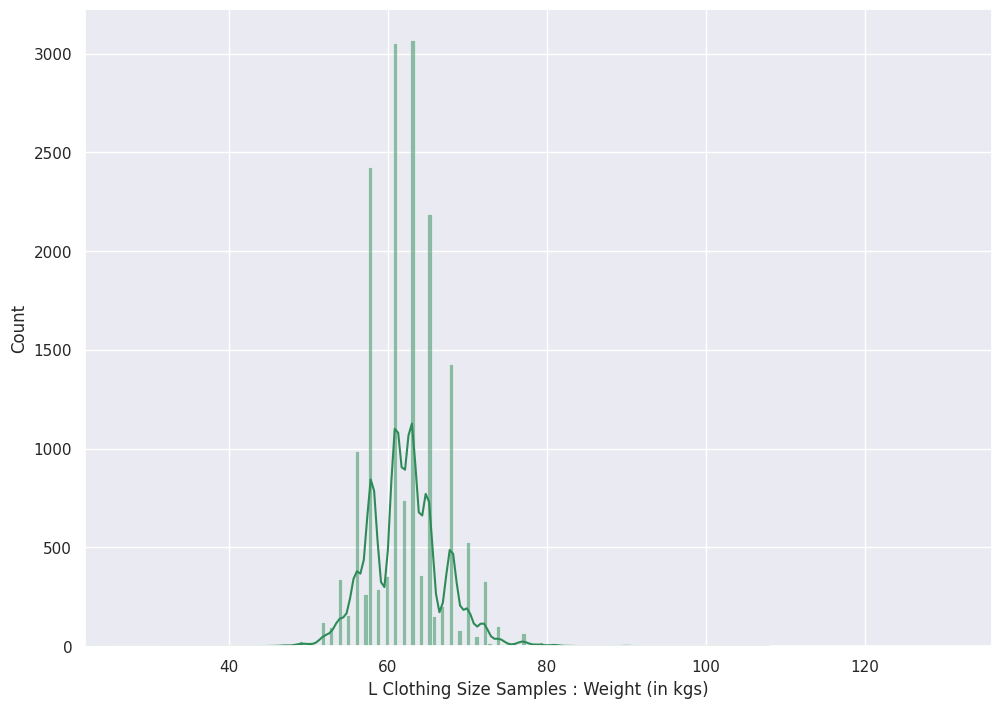

In [ ]:
count_plotted = sns.histplot(x = 'weight', data = dataframed.loc[dataframed['size'] == 4], kde = True, color = 'seagreen')
count_plotted.set(xlabel = "L Clothing Size Samples : Weight (in kgs)")
count_plotted.set(xlim = (22.0000, 136.0000))

# Outliers : Weight

[Text(0.5, 0, 'L Clothing Size Samples : Weight (in kgs)')]

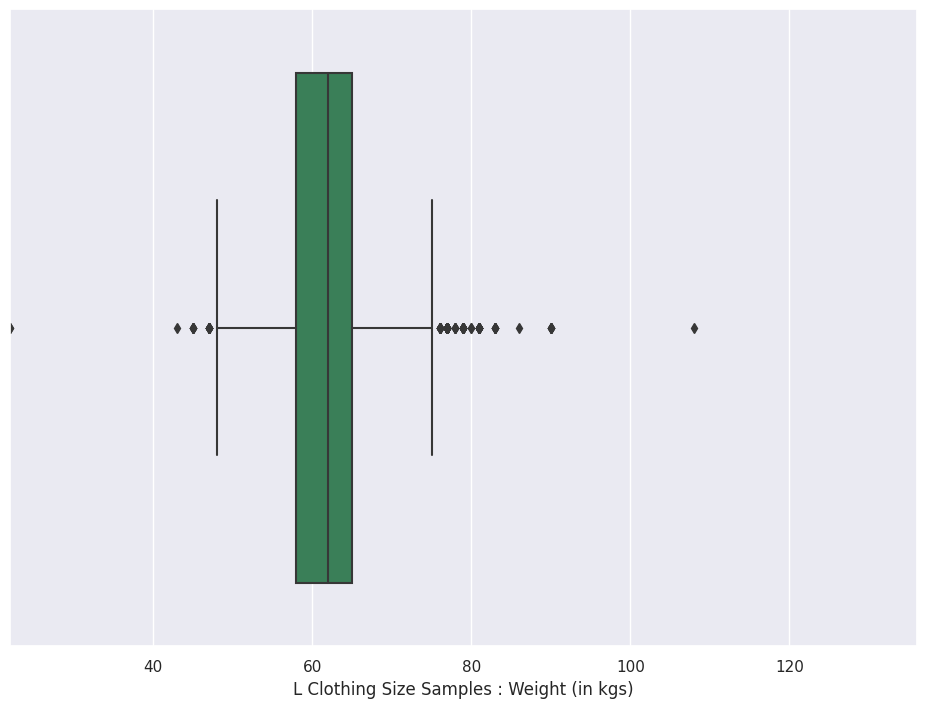

In [ ]:
boxxer_plot = sns.boxplot(x = 'weight', data = dataframed.loc[dataframed['size'] == 4], color = 'seagreen')
boxxer_plot.set(xlim = (22.0000, 136.0000))
boxxer_plot.set(xlabel = "L Clothing Size Samples : Weight (in kgs)")

# How many outliers in Weight Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 4]['weight'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 47.5000 or greater than 75.5000
There are 162 outliers.


# Column : Age

# Distribution of rows in terms of Age

[(0.0, 117.0)]

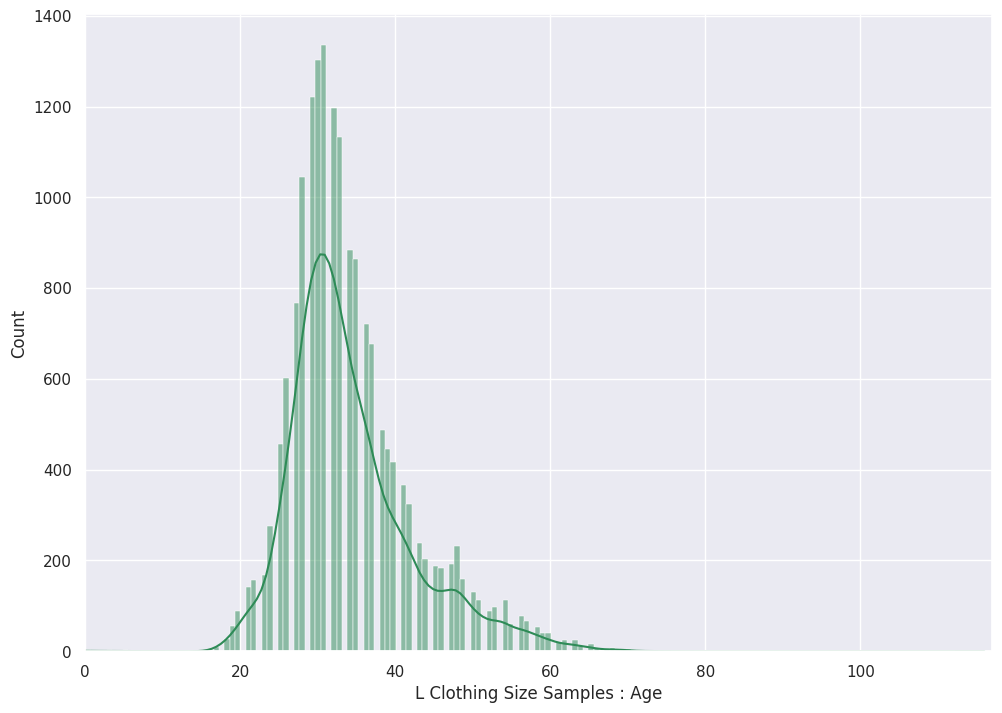

In [ ]:
count_plotted = sns.histplot(x = 'age', data = dataframed.loc[dataframed['size'] == 4], kde = True, color = 'seagreen')
count_plotted.set(xlabel = "L Clothing Size Samples : Age")
count_plotted.set(xlim = (0.0000, 117.0000))

# Outliers : Age

[Text(0.5, 0, 'L Clothing Size Samples : Age')]

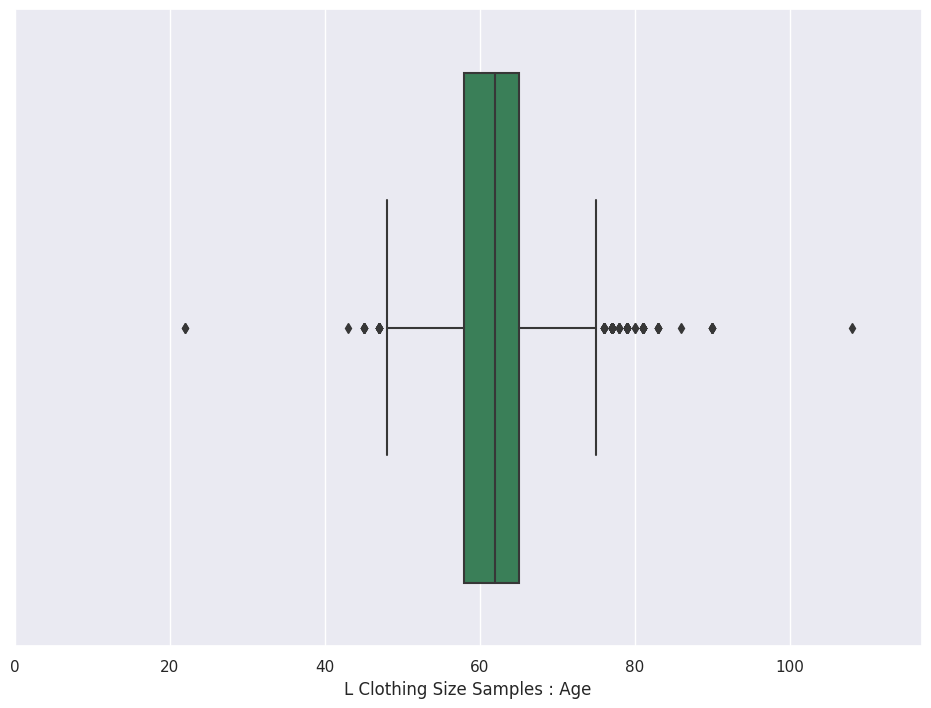

In [ ]:
boxxer_plot = sns.boxplot(x = 'weight', data = dataframed.loc[dataframed['size'] == 4], color = 'seagreen')
boxxer_plot.set(xlim = (0.0000, 117.0000))
boxxer_plot.set(xlabel = "L Clothing Size Samples : Age")

# How many outliers in Age Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 4]['age'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 15.5000 or greater than 51.5000
There are 775 outliers.


# Column : Height (in cm)

# Distribution of rows in terms of Height

[(137.16, 193.04)]

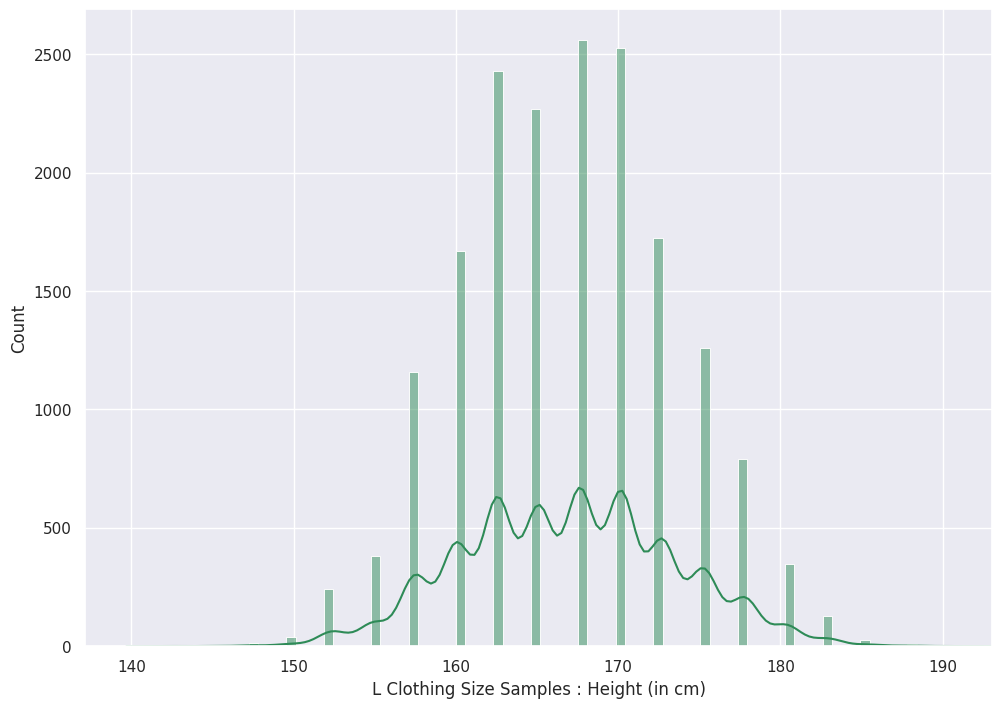

In [ ]:
count_plotted = sns.histplot(x = 'height', data = dataframed.loc[dataframed['size'] == 4], kde = True, color = 'seagreen')
count_plotted.set(xlabel = "L Clothing Size Samples : Height (in cm)")
count_plotted.set(xlim = (137.1600, 193.0400))

# Outliers : Height

[Text(0.5, 0, 'L Clothing Size Samples : Height (in cm)')]

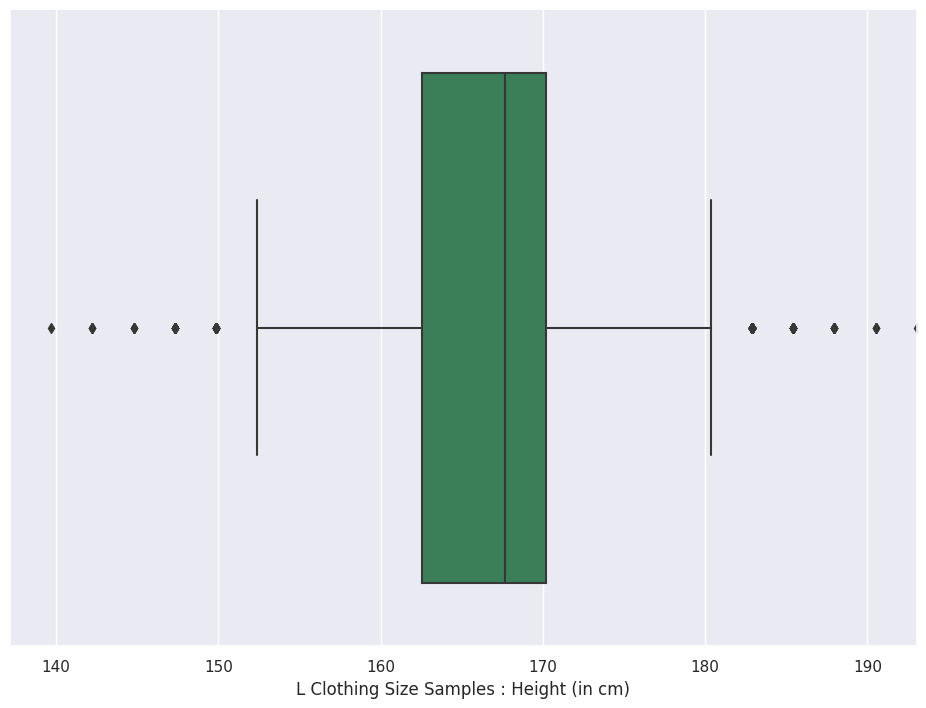

In [ ]:
boxxer_plot = sns.boxplot(x = 'height', data = dataframed.loc[dataframed['size'] == 4], color = 'seagreen')
boxxer_plot.set(xlim = (137.1600, 193.0400))
boxxer_plot.set(xlabel = "L Clothing Size Samples : Height (in cm)")

# How many outliers in Height Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 4]['height'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 151.1300 or greater than 181.6100
There are 231 outliers.


# Column : Size

# Distribution of rows in terms of Size

[(1.0, 7.0)]

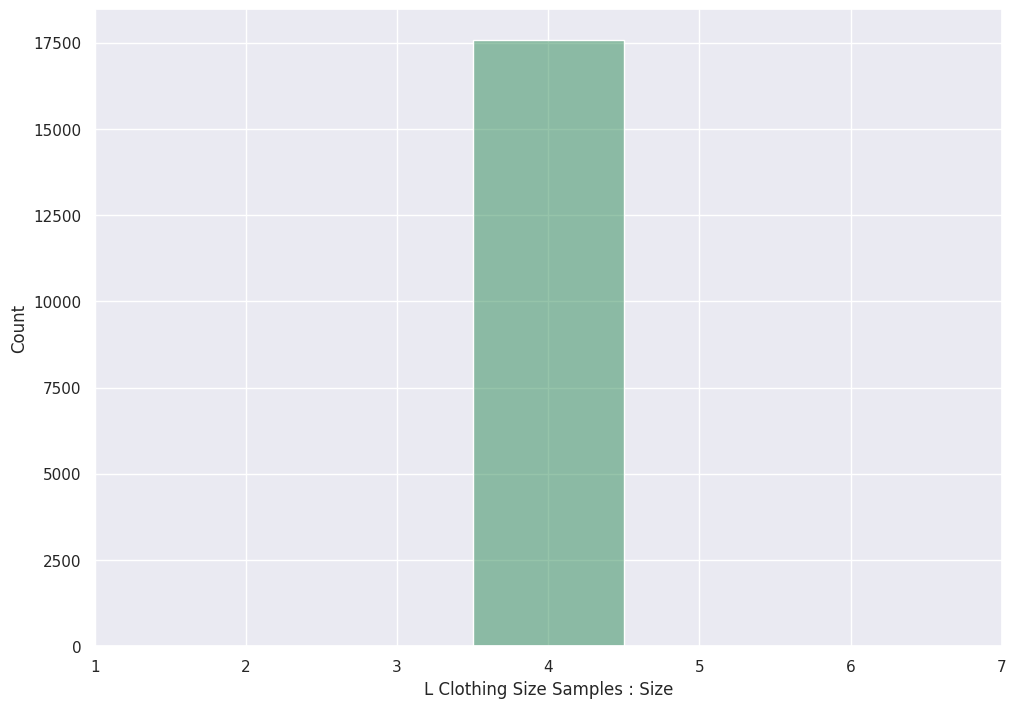

In [ ]:
count_plotted = sns.histplot(x = 'size', data = dataframed.loc[dataframed['size'] == 4], kde = True, color = 'seagreen')
count_plotted.set(xlabel = "L Clothing Size Samples : Size")
count_plotted.set(xlim = (1.0000, 7.0000))

# Outliers : Size

[Text(0.5, 0, 'L Clothing Size Samples : Size')]

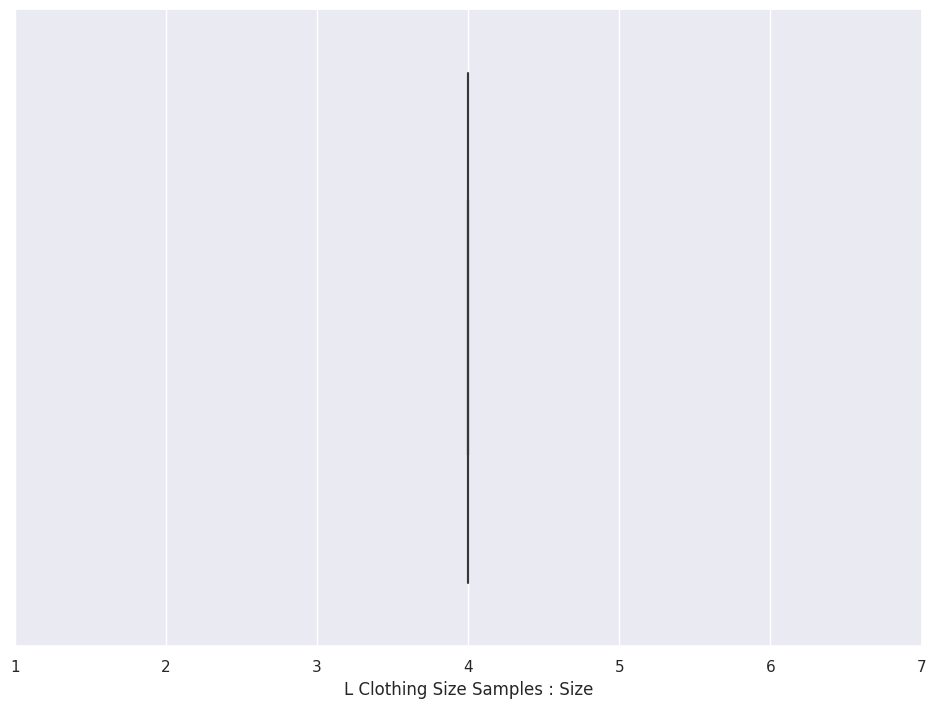

In [ ]:
boxxer_plot = sns.boxplot(x = 'size', data = dataframed.loc[dataframed['size'] == 4], color = 'seagreen')
boxxer_plot.set(xlim = (1.0000, 7.0000))
boxxer_plot.set(xlabel = "L Clothing Size Samples : Size")

# How many outliers in Size Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 4]['size'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 4.0000 or greater than 4.0000
There are 0 outliers.


# Column : BMI

# Distribution of rows in terms of BMI

[(7.8283, 54.3236)]

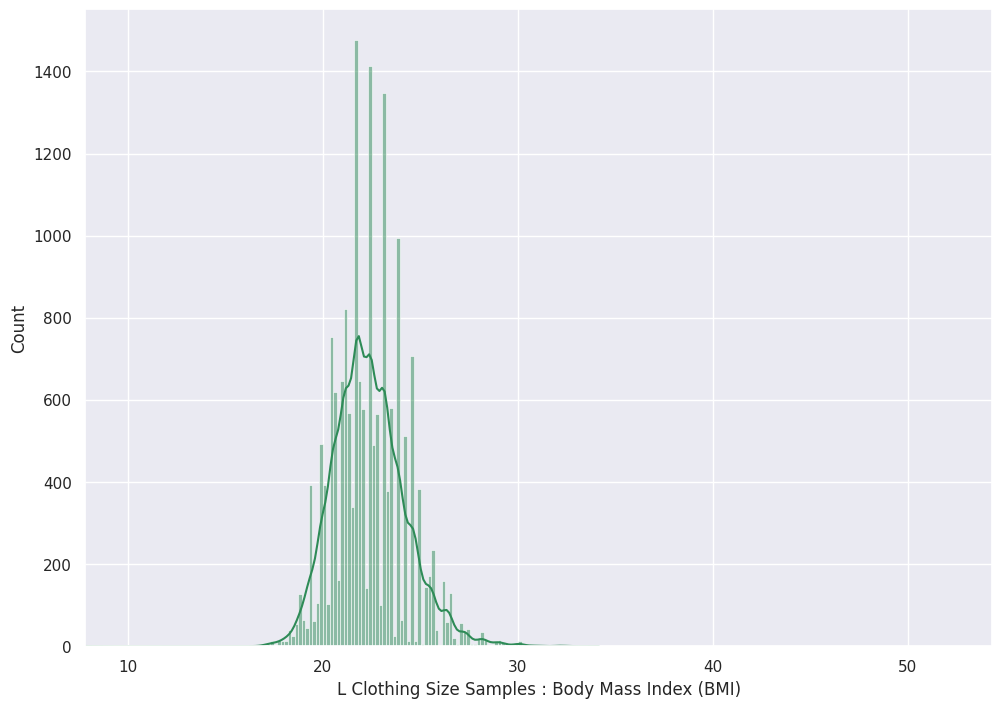

In [ ]:
count_plotted = sns.histplot(x = 'bmi', data = dataframed.loc[dataframed['size'] == 4], kde = True, color = 'seagreen')
count_plotted.set(xlabel = "L Clothing Size Samples : Body Mass Index (BMI)")
count_plotted.set(xlim = (7.8283, 54.3236))

# Outliers : BMI

[Text(0.5, 0, 'L Clothing Size Samples : Body Mass Index (BMI)')]

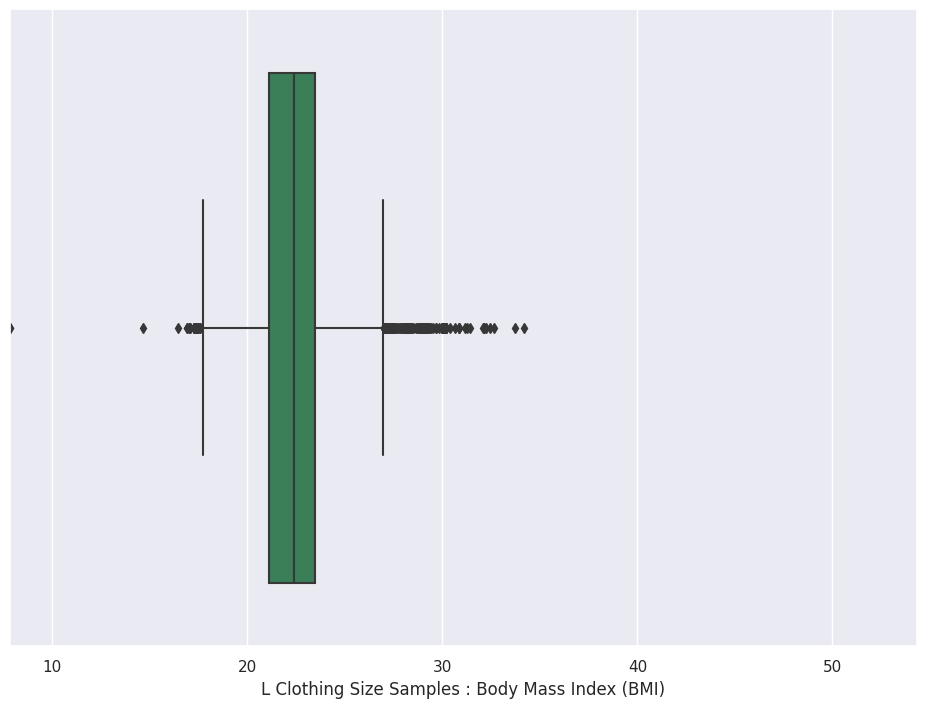

In [ ]:
boxxer_plot = sns.boxplot(x = 'bmi', data = dataframed.loc[dataframed['size'] == 4], color = 'seagreen')
boxxer_plot.set(xlim = (7.8283, 54.3236))
boxxer_plot.set(xlabel = "L Clothing Size Samples : Body Mass Index (BMI)")

# How many outliers in BMI Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 4]['bmi'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 17.6024 or greater than 26.9777
There are 325 outliers.


# Types of Rows : XL Clothing Size Samples

# Column : Weight (in kgs)

# Distribution of rows in terms of Weight

[(22.0, 136.0)]

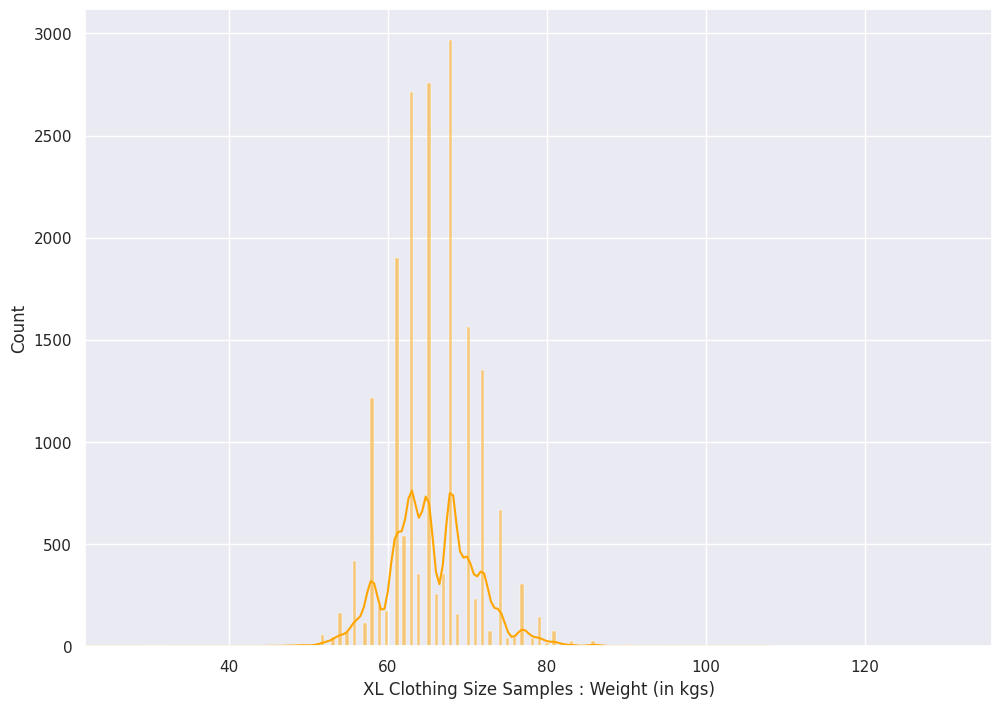

In [ ]:
count_plotted = sns.histplot(x = 'weight', data = dataframed.loc[dataframed['size'] == 5], kde = True, color = 'orange')
count_plotted.set(xlabel = "XL Clothing Size Samples : Weight (in kgs)")
count_plotted.set(xlim = (22.0000, 136.0000))

# Outliers : Weight

[Text(0.5, 0, 'XL Clothing Size Samples : Weight (in kgs)')]

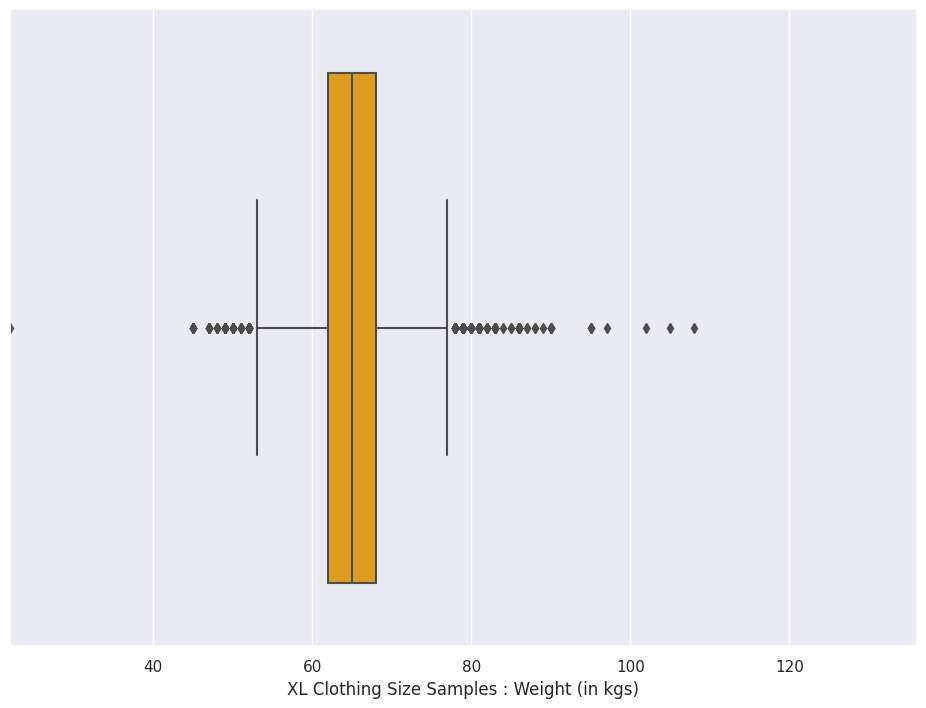

In [ ]:
boxxer_plot = sns.boxplot(x = 'weight', data = dataframed.loc[dataframed['size'] == 5], color = 'orange')
boxxer_plot.set(xlim = (22.0000, 136.0000))
boxxer_plot.set(xlabel = "XL Clothing Size Samples : Weight (in kgs)")

# How many outliers in Weight Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 5]['weight'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 53.0000 or greater than 77.0000
There are 447 outliers.


# Column : Age

# Distribution of rows in terms of Age

[(0.0, 117.0)]

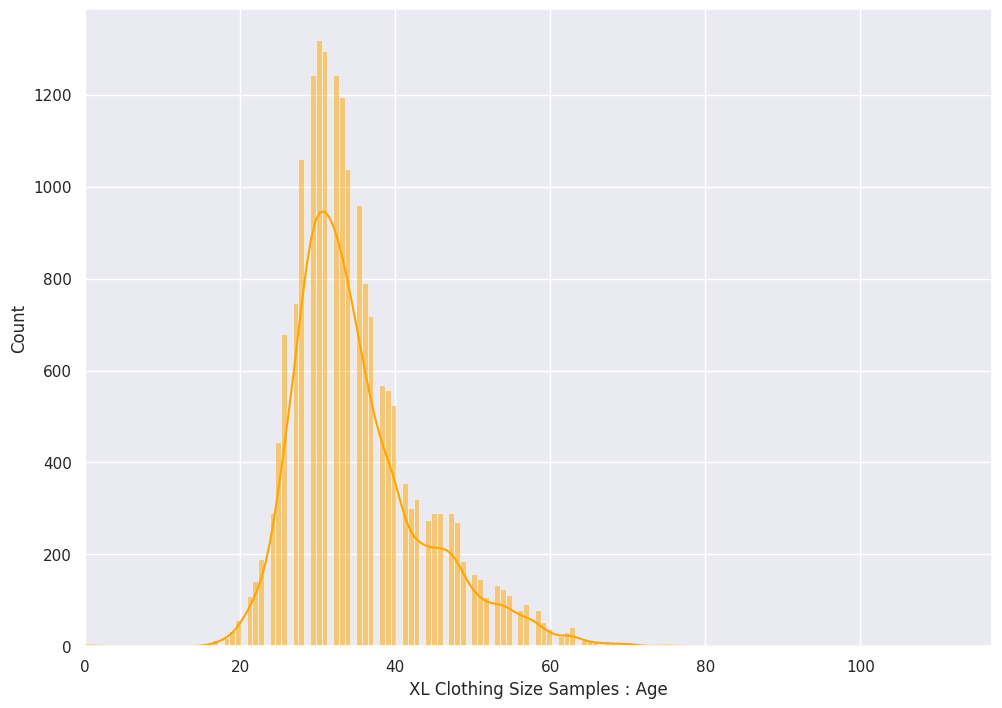

In [ ]:
count_plotted = sns.histplot(x = 'age', data = dataframed.loc[dataframed['size'] == 5], kde = True, color = 'orange')
count_plotted.set(xlabel = "XL Clothing Size Samples : Age")
count_plotted.set(xlim = (0.0000, 117.0000))

# Outliers : Age

[Text(0.5, 0, 'XL Clothing Size Samples : Age')]

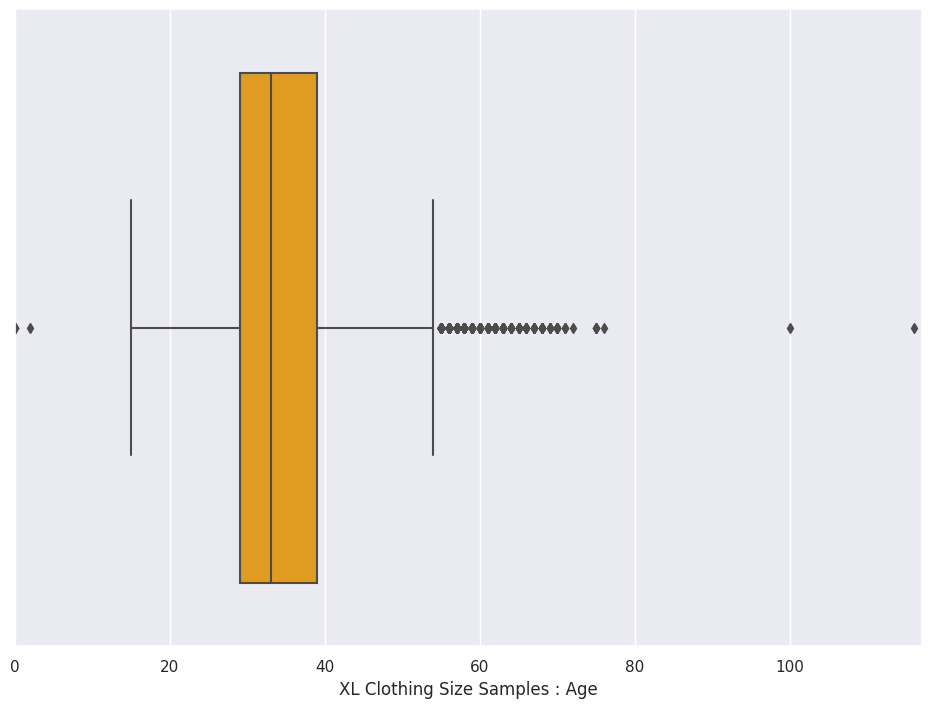

In [ ]:
boxxer_plot = sns.boxplot(x = 'age', data = dataframed.loc[dataframed['size'] == 5], color = 'orange')
boxxer_plot.set(xlim = (0.0000, 117.0000))
boxxer_plot.set(xlabel = "XL Clothing Size Samples : Age")

# How many outliers in Age Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 5]['age'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 14.0000 or greater than 54.0000
There are 630 outliers.


# Column : Height (in cm)

# Distribution of rows in terms of Height

[(137.16, 193.04)]

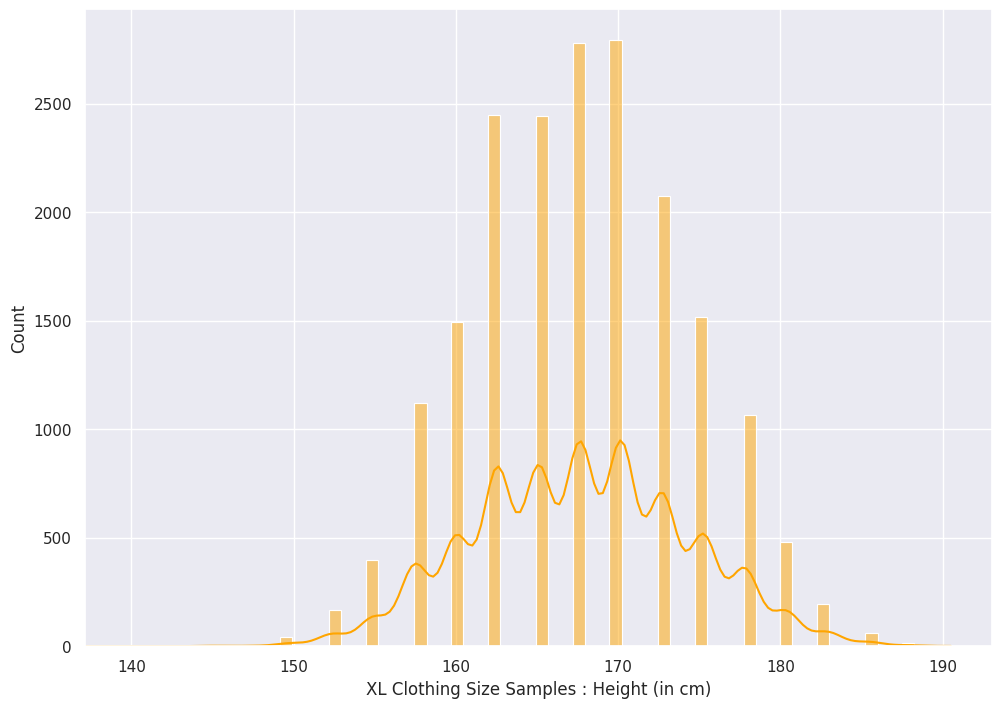

In [ ]:
count_plotted = sns.histplot(x = 'height', data = dataframed.loc[dataframed['size'] == 5], kde = True, color = 'orange')
count_plotted.set(xlabel = "XL Clothing Size Samples : Height (in cm)")
count_plotted.set(xlim = (137.1600, 193.0400))

# Outliers : Height

[Text(0.5, 0, 'XL Clothing Size Samples : Height (in cm)')]

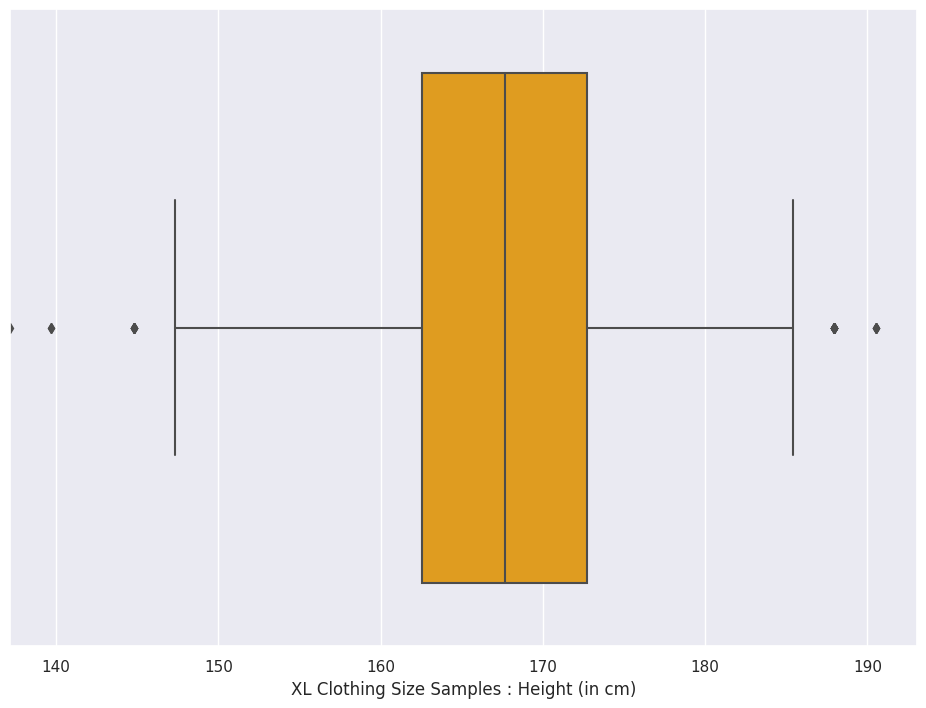

In [ ]:
boxxer_plot = sns.boxplot(x = 'height', data = dataframed.loc[dataframed['size'] == 5], color = 'orange')
boxxer_plot.set(xlim = (137.1600, 193.0400))
boxxer_plot.set(xlabel = "XL Clothing Size Samples : Height (in cm)")

# How many outliers in Height Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 5]['height'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 147.3200 or greater than 187.9600
There are 28 outliers.


# Column : Size

# Distribution of rows in terms of Size

[(1.0, 7.0)]

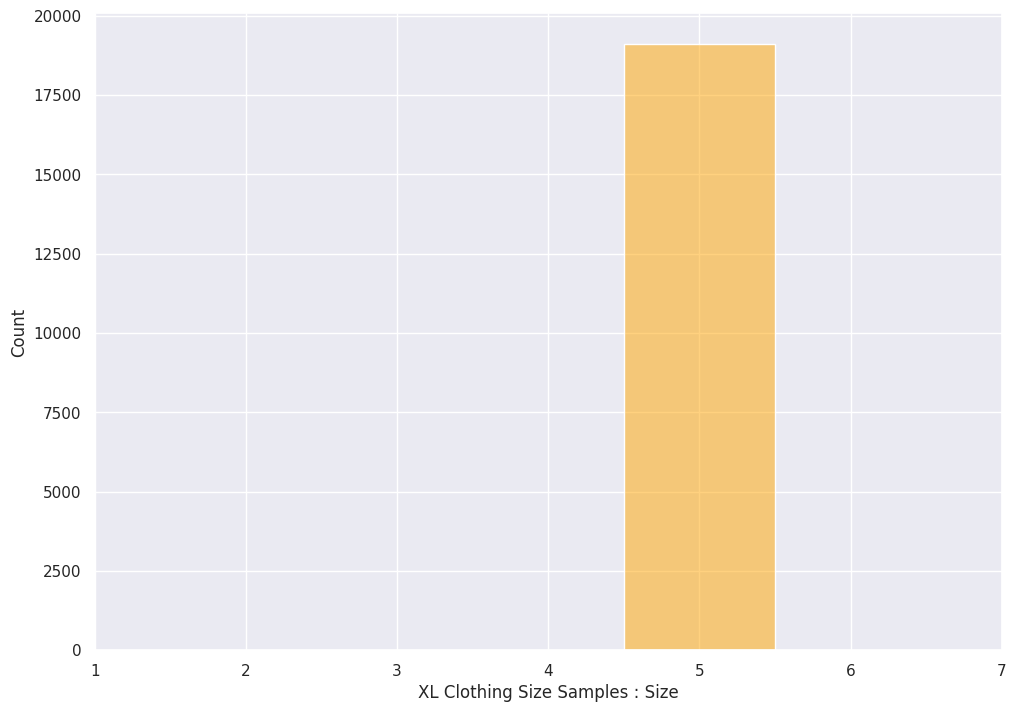

In [ ]:
count_plotted = sns.histplot(x = 'size', data = dataframed.loc[dataframed['size'] == 5], kde = True, color = 'orange')
count_plotted.set(xlabel = "XL Clothing Size Samples : Size")
count_plotted.set(xlim = (1.0000, 7.0000))

# Outliers : Size

[Text(0.5, 0, 'XL Clothing Size Samples : Size')]

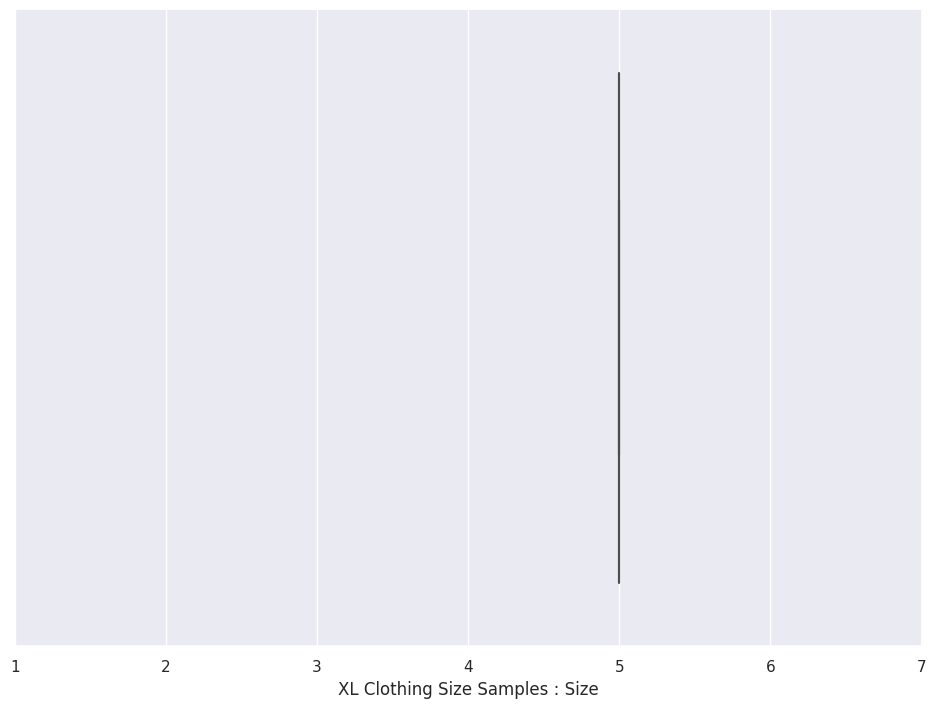

In [ ]:
boxxer_plot = sns.boxplot(x = 'size', data = dataframed.loc[dataframed['size'] == 5], color = 'orange')
boxxer_plot.set(xlim = (1.0000, 7.0000))
boxxer_plot.set(xlabel = "XL Clothing Size Samples : Size")

# How many outliers in Size Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 5]['size'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 5.0000 or greater than 5.0000
There are 0 outliers.


# Column : BMI

# Distribution of rows in terms of BMI

[(7.8283, 54.3236)]

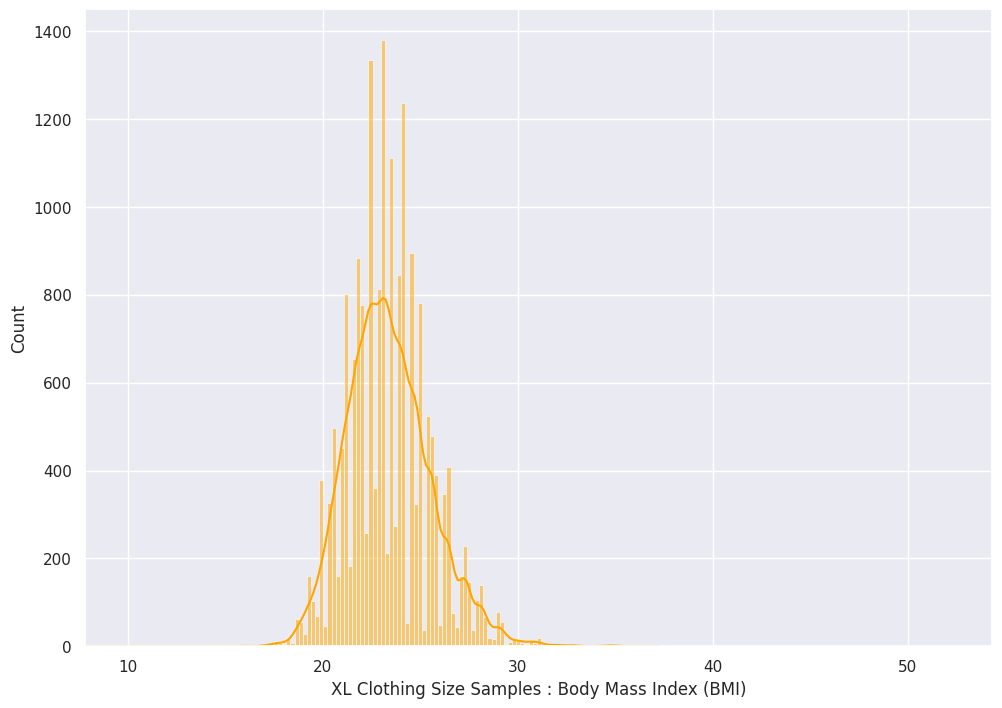

In [ ]:
count_plotted = sns.histplot(x = 'bmi', data = dataframed.loc[dataframed['size'] == 5], kde = True, color = 'orange')
count_plotted.set(xlabel = "XL Clothing Size Samples : Body Mass Index (BMI)")
count_plotted.set(xlim = (7.8283, 54.3236))

# Outliers : BMI

[Text(0.5, 0, 'XL Clothing Size Samples : Body Mass Index (BMI)')]

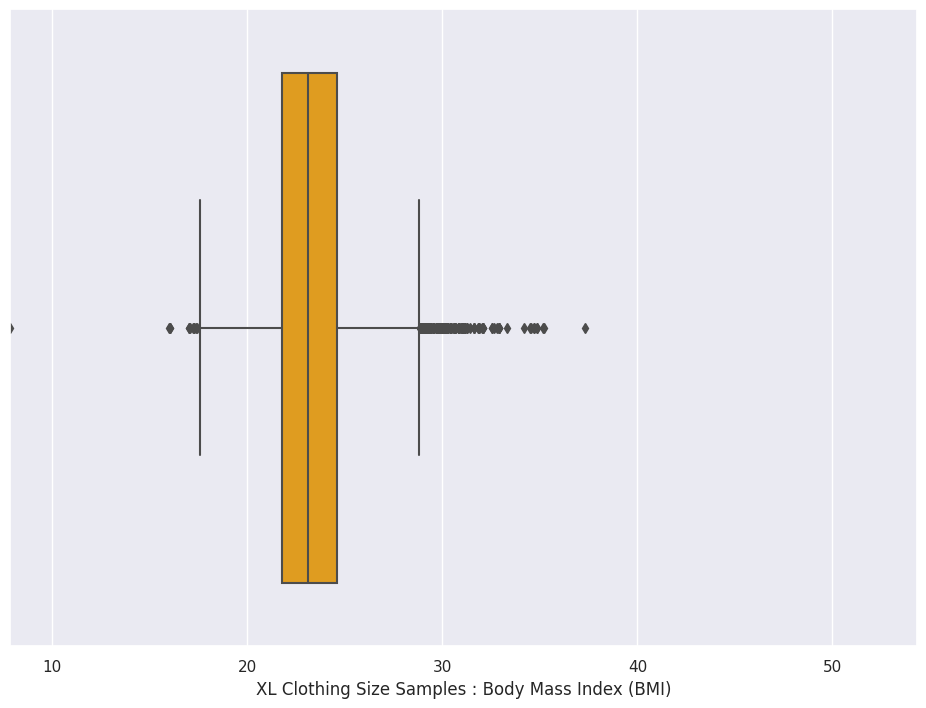

In [ ]:
boxxer_plot = sns.boxplot(x = 'bmi', data = dataframed.loc[dataframed['size'] == 5], color = 'orange')
boxxer_plot.set(xlim = (7.8283, 54.3236))
boxxer_plot.set(xlabel = "XL Clothing Size Samples : Body Mass Index (BMI)")

# How many outliers in BMI Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 5]['bmi'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 17.5665 or greater than 28.8253
There are 284 outliers.


# Types of Rows : XXL Clothing Size Samples

# Column : Weight (in kgs)

# Distribution of rows in terms of Weight

[(22.0, 136.0)]

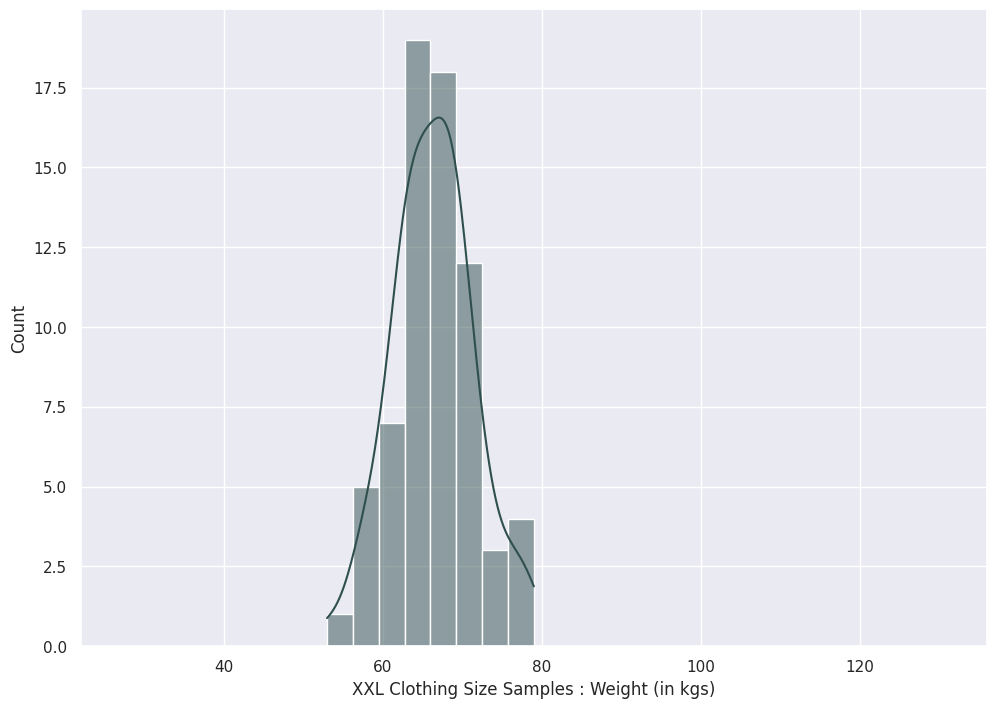

In [ ]:
count_plotted = sns.histplot(x = 'weight', data = dataframed.loc[dataframed['size'] == 6], kde = True, color = 'darkslategrey')
count_plotted.set(xlabel = "XXL Clothing Size Samples : Weight (in kgs)")
count_plotted.set(xlim = (22.0000, 136.0000))

# Outliers : Weight

[Text(0.5, 0, 'XXL Clothing Size Samples : Weight (in kgs)')]

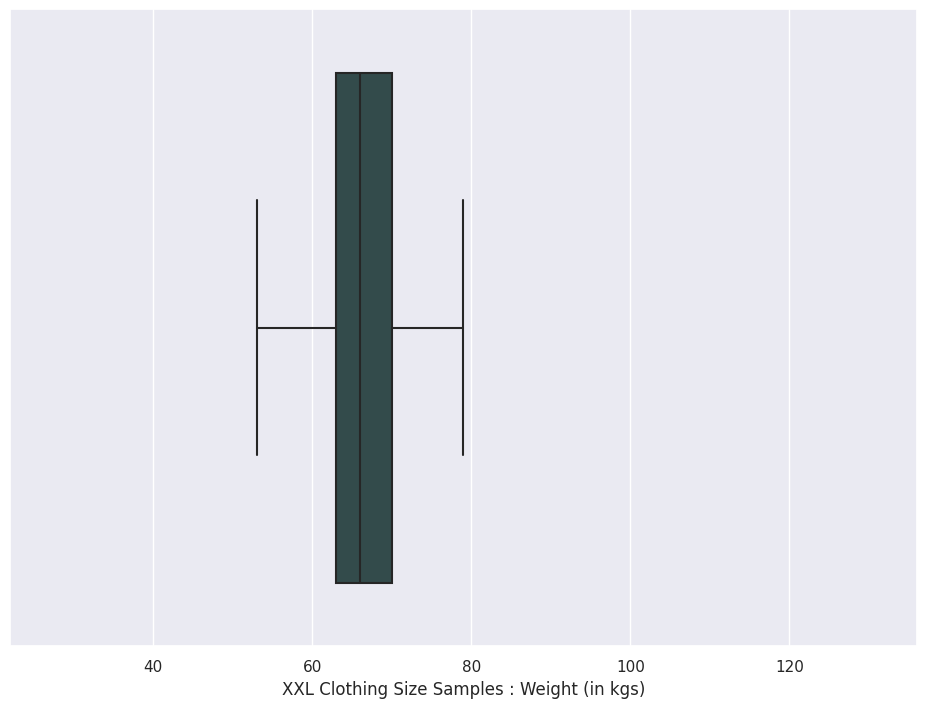

In [ ]:
boxxer_plot = sns.boxplot(x = 'weight', data = dataframed.loc[dataframed['size'] == 6], color = 'darkslategrey')
boxxer_plot.set(xlim = (22.0000, 136.0000))
boxxer_plot.set(xlabel = "XXL Clothing Size Samples : Weight (in kgs)")

# How many outliers in Weight Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 6]['weight'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 52.5000 or greater than 80.5000
There are 0 outliers.


# Column : Age

# Distribution of rows in terms of Age

[(0.0, 117.0)]

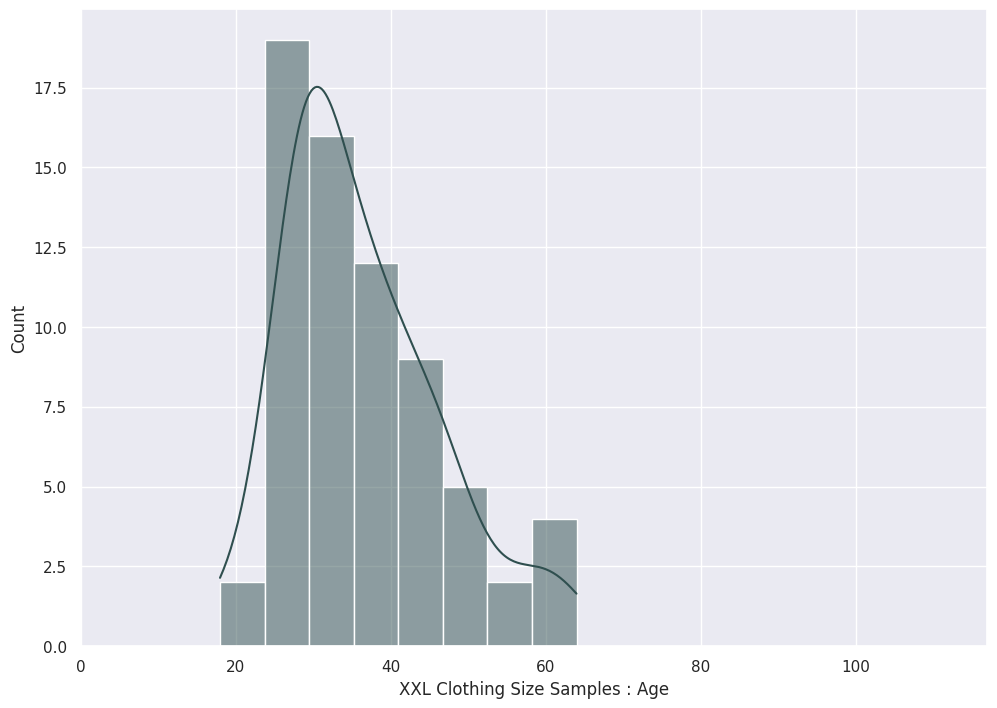

In [ ]:
count_plotted = sns.histplot(x = 'age', data = dataframed.loc[dataframed['size'] == 6], kde = True, color = 'darkslategrey')
count_plotted.set(xlabel = "XXL Clothing Size Samples : Age")
count_plotted.set(xlim = (0.0000, 117.0000))

# Outliers : Age

[Text(0.5, 0, 'XXL Clothing Size Samples : Age')]

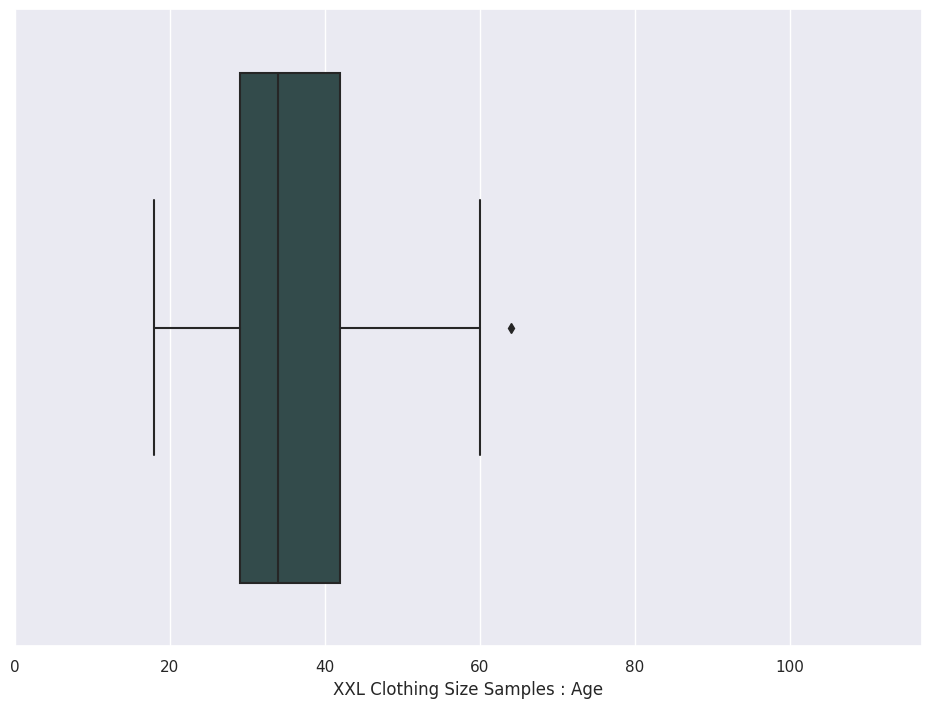

In [ ]:
boxxer_plot = sns.boxplot(x = 'age', data = dataframed.loc[dataframed['size'] == 6], color = 'darkslategrey')
boxxer_plot.set(xlim = (0.0000, 117.0000))
boxxer_plot.set(xlabel = "XXL Clothing Size Samples : Age")

# How many outliers in Age Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 6]['age'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values greater than 61.5000
There are 1 outliers.


# Column : Height (in cm)

# Distribution of rows in terms of Height

[(137.16, 193.04)]

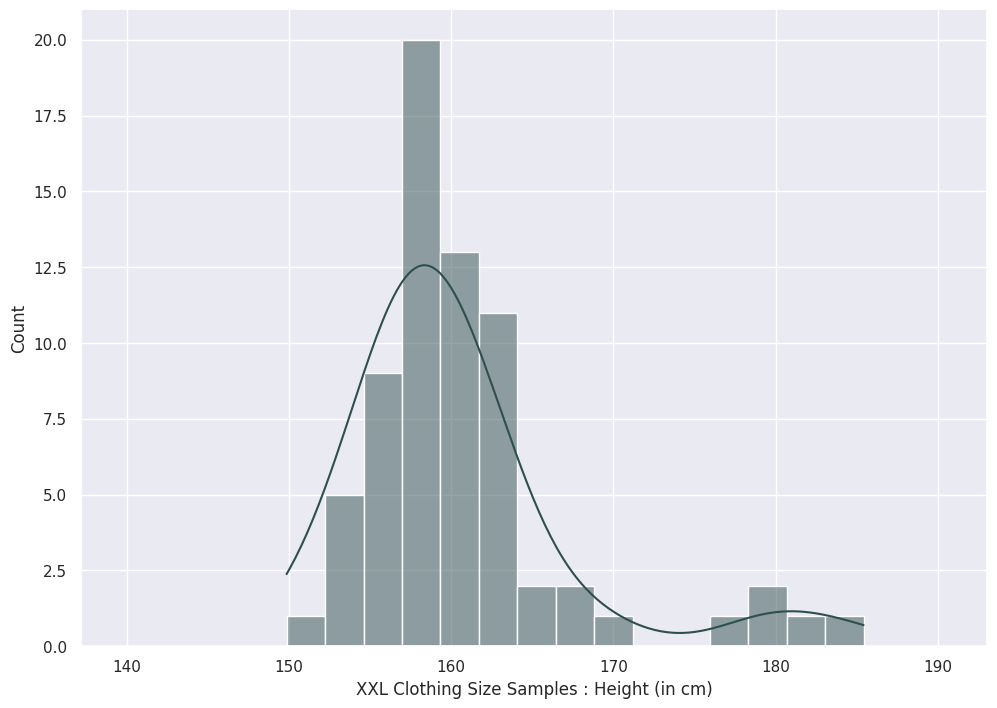

In [ ]:
count_plotted = sns.histplot(x = 'height', data = dataframed.loc[dataframed['size'] == 6], kde = True, color = 'darkslategrey')
count_plotted.set(xlabel = "XXL Clothing Size Samples : Height (in cm)")
count_plotted.set(xlim = (137.1600, 193.0400))

# Outliers : Height

[Text(0.5, 0, 'XXL Clothing Size Samples : Height (in cm)')]

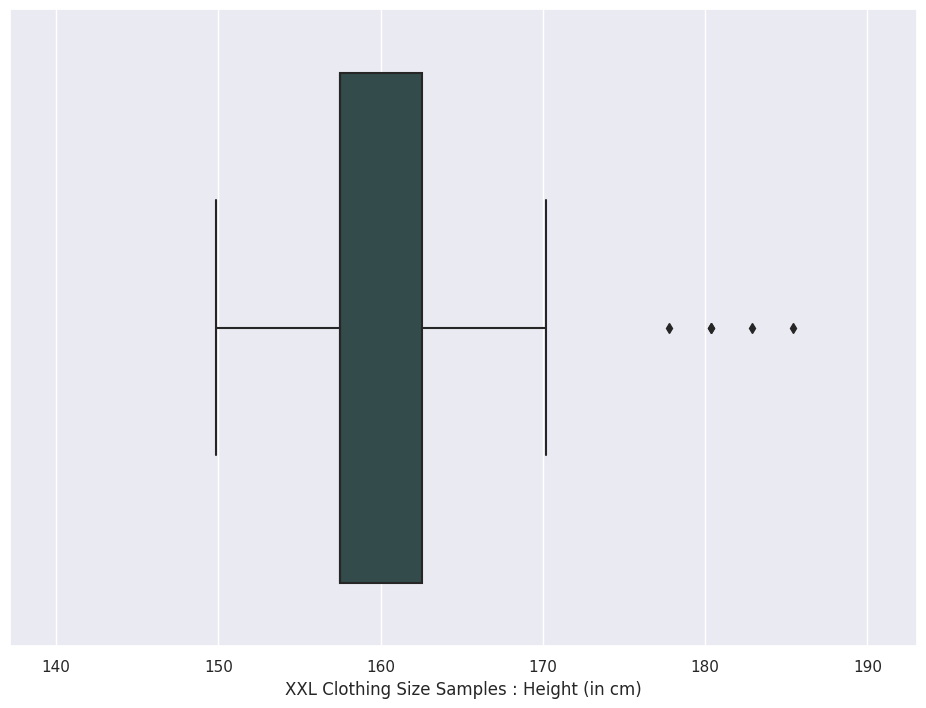

In [ ]:
boxxer_plot = sns.boxplot(x = 'height', data = dataframed.loc[dataframed['size'] == 6], color = 'darkslategrey')
boxxer_plot.set(xlim = (137.1600, 193.0400))
boxxer_plot.set(xlabel = "XXL Clothing Size Samples : Height (in cm)")

# How many outliers in Height Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 6]['height'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values greater than 170.1800
There are 5 outliers.


# Column : Size

# Distribution of rows in terms of Size

[(1.0, 7.0)]

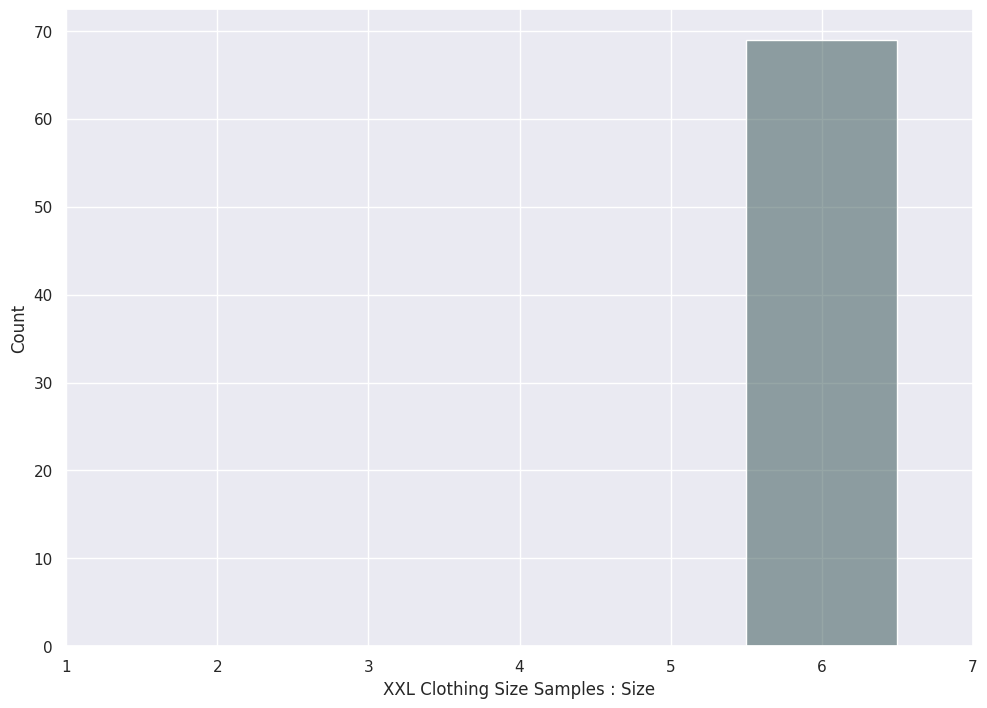

In [ ]:
count_plotted = sns.histplot(x = 'size', data = dataframed.loc[dataframed['size'] == 6], kde = True, color = 'darkslategrey')
count_plotted.set(xlabel = "XXL Clothing Size Samples : Size")
count_plotted.set(xlim = (1.0000, 7.0000))

# Outliers : Size

[Text(0.5, 0, 'XXL Clothing Size Samples : Size')]

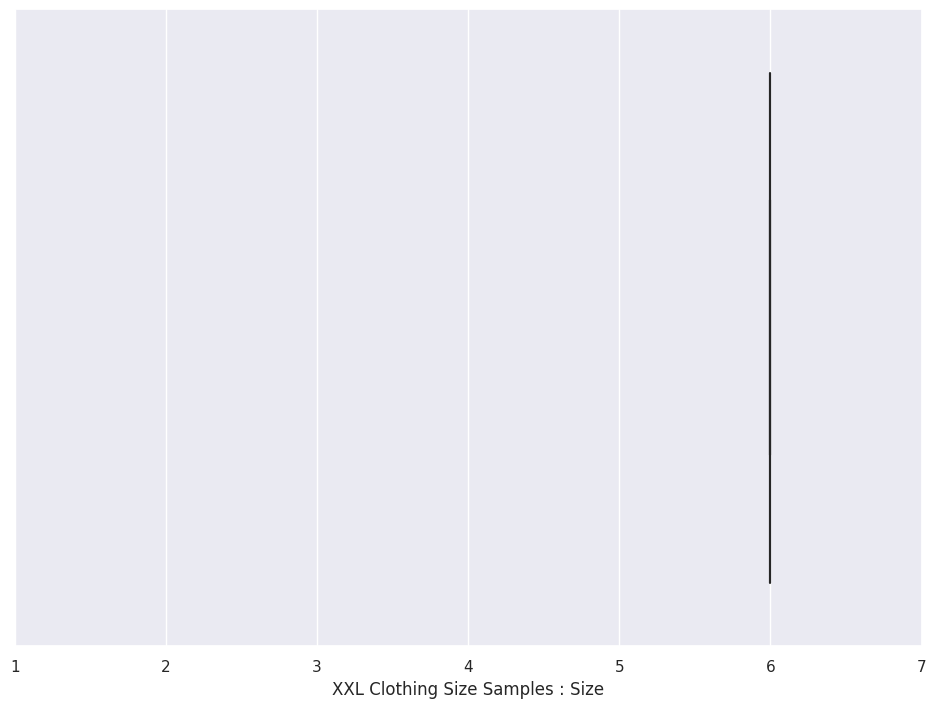

In [ ]:
boxxer_plot = sns.boxplot(x = 'size', data = dataframed.loc[dataframed['size'] == 6], color = 'darkslategrey')
boxxer_plot.set(xlim = (1.0000, 7.0000))
boxxer_plot.set(xlabel = "XXL Clothing Size Samples : Size")

# How many outliers in Size Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 6]['size'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 6.0000 or greater than 6.0000
There are 0 outliers.


# Column : BMI

# Distribution of rows in terms of BMI

[(7.8283, 54.3236)]

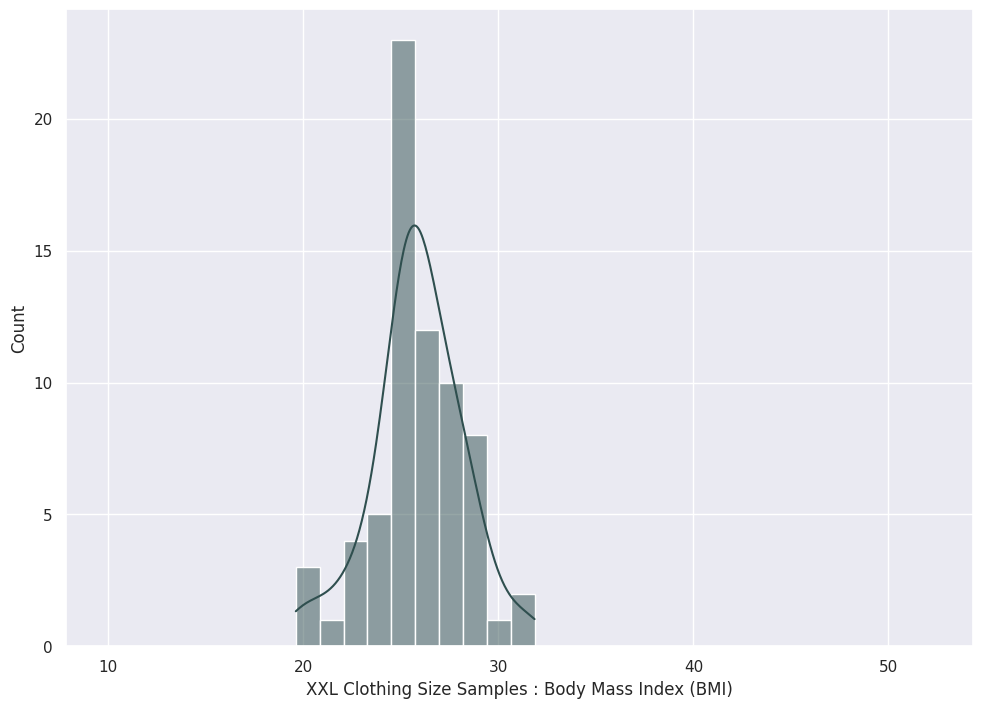

In [ ]:
count_plotted = sns.histplot(x = 'bmi', data = dataframed.loc[dataframed['size'] == 6], kde = True, color = 'darkslategrey')
count_plotted.set(xlabel = "XXL Clothing Size Samples : Body Mass Index (BMI)")
count_plotted.set(xlim = (7.8283, 54.3236))

# Outliers : BMI

[Text(0.5, 0, 'XXL Clothing Size Samples : Body Mass Index (BMI)')]

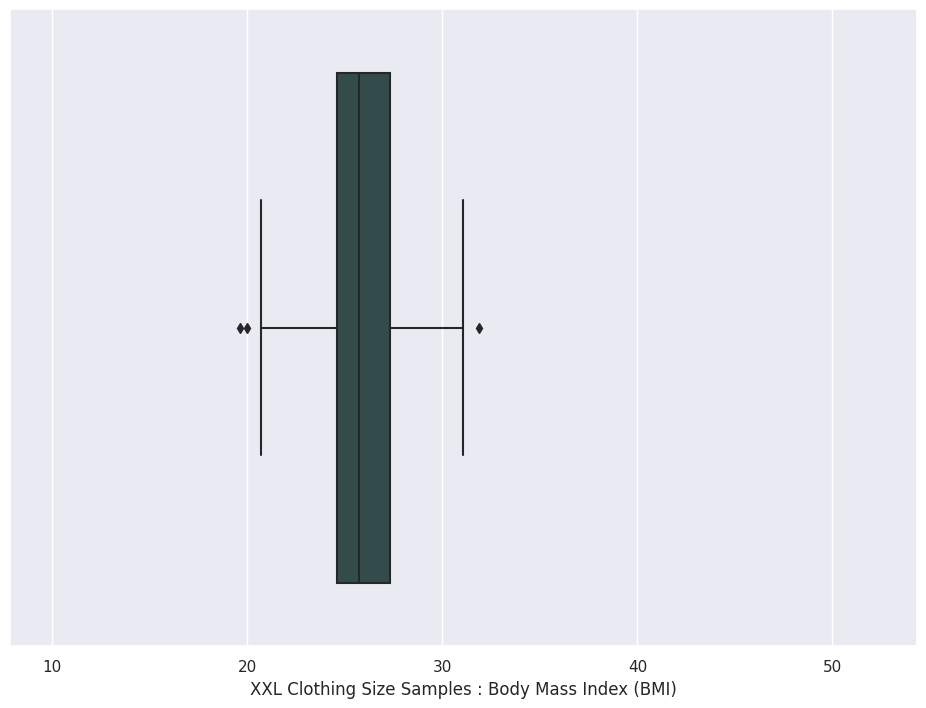

In [ ]:
boxxer_plot = sns.boxplot(x = 'bmi', data = dataframed.loc[dataframed['size'] == 6], color = 'darkslategrey')
boxxer_plot.set(xlim = (7.8283, 54.3236))
boxxer_plot.set(xlabel = "XXL Clothing Size Samples : Body Mass Index (BMI)")

# How many outliers in BMI Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 6]['bmi'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 20.5027 or greater than 31.4375
There are 3 outliers.


# Types of Rows : XXXL Clothing Size Samples

# Column : Weight (in kgs)

# Distribution of rows in terms of Weight

[(22.0, 136.0)]

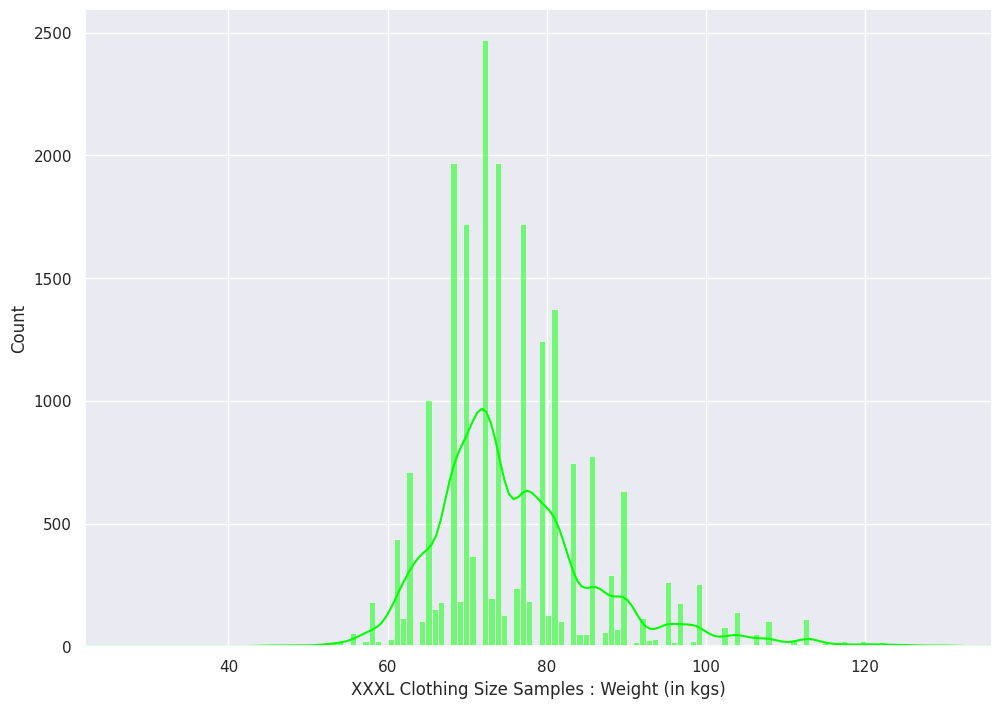

In [ ]:
count_plotted = sns.histplot(x = 'weight', data = dataframed.loc[dataframed['size'] == 7], kde = True, color = 'lime')
count_plotted.set(xlabel = "XXXL Clothing Size Samples : Weight (in kgs)")
count_plotted.set(xlim = (22.0000, 136.0000))

# Outliers : Weight

[Text(0.5, 0, 'XXXL Clothing Size Samples : Weight (in kgs)')]

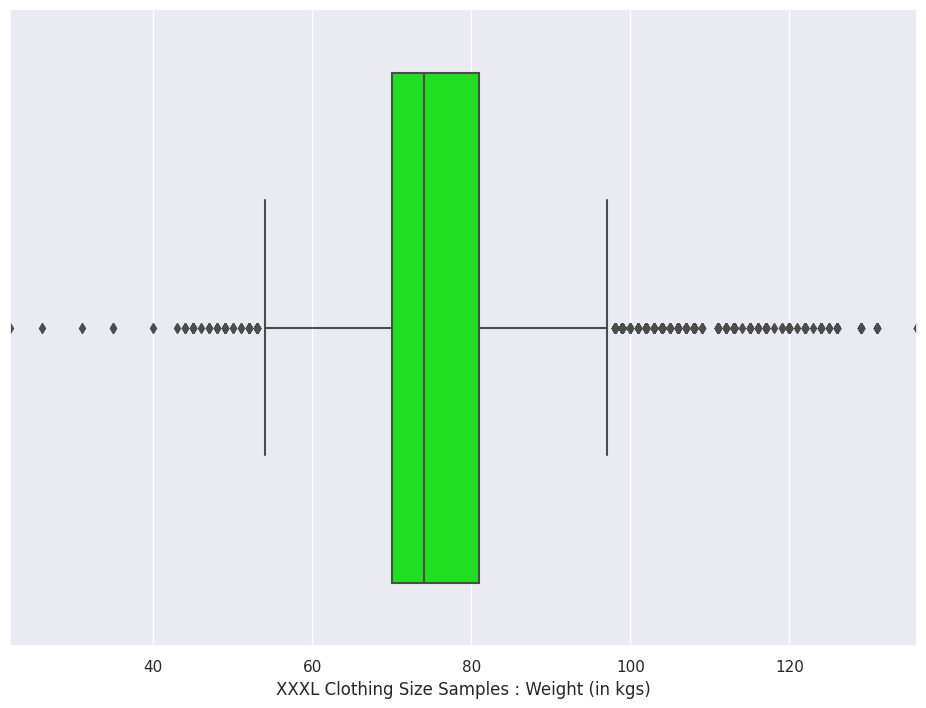

In [ ]:
boxxer_plot = sns.boxplot(x = 'weight', data = dataframed.loc[dataframed['size'] == 7], color = 'lime')
boxxer_plot.set(xlim = (22.0000, 136.0000))
boxxer_plot.set(xlabel = "XXXL Clothing Size Samples : Weight (in kgs)")

# How many outliers in Weight Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 7]['weight'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 53.5000 or greater than 97.5000
There are 1024 outliers.


# Column : Age

# Distribution of rows in terms of Age

[(0.0, 117.0)]

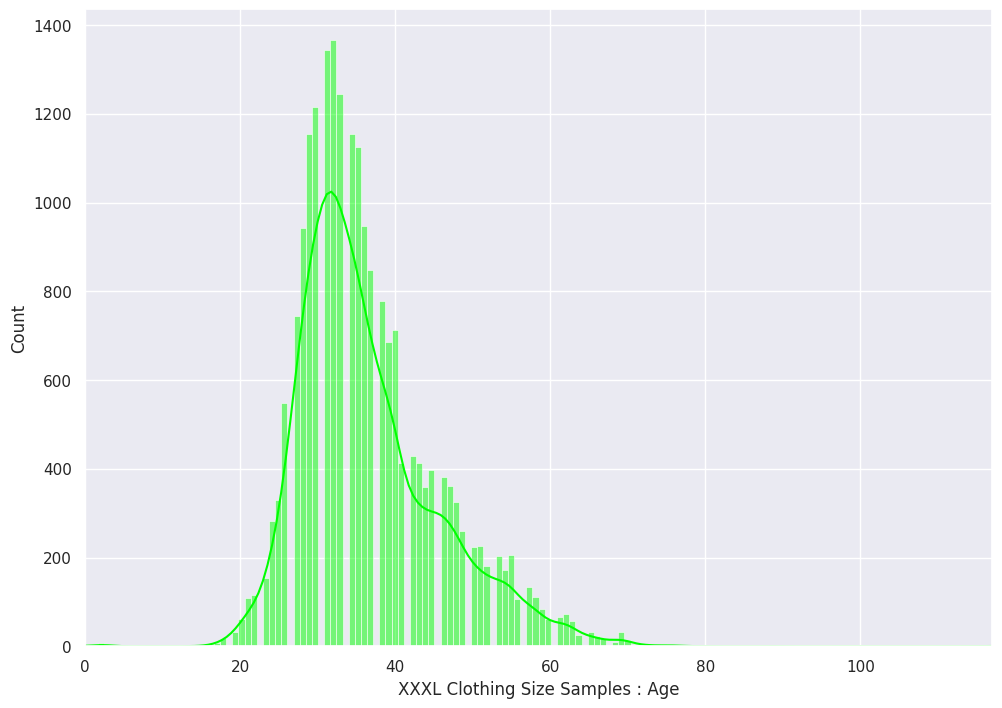

In [ ]:
count_plotted = sns.histplot(x = 'age', data = dataframed.loc[dataframed['size'] == 7], kde = True, color = 'lime')
count_plotted.set(xlabel = "XXXL Clothing Size Samples : Age")
count_plotted.set(xlim = (0.0000, 117.0000))

# Outliers : Age

[Text(0.5, 0, 'XXXL Clothing Size Samples : Age')]

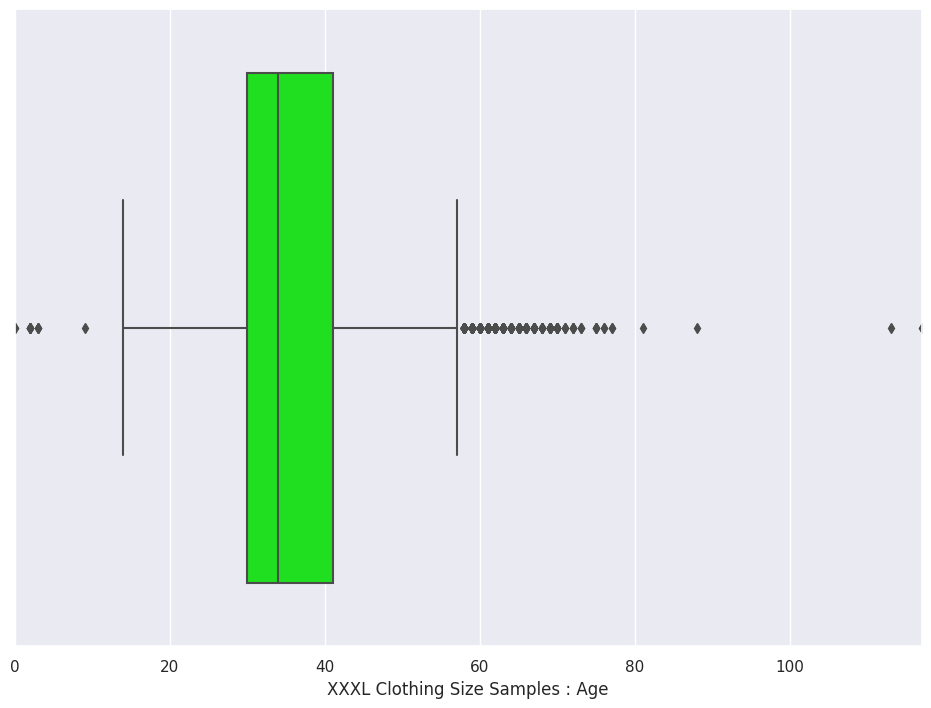

In [ ]:
boxxer_plot = sns.boxplot(x = 'age', data = dataframed.loc[dataframed['size'] == 7], color = 'lime')
boxxer_plot.set(xlim = (0.0000, 117.0000))
boxxer_plot.set(xlabel = "XXXL Clothing Size Samples : Age")

# How many outliers in Age Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 7]['age'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 13.5000 or greater than 57.5000
There are 645 outliers.


# Column : Height (in cm)

# Distribution of rows in terms of Height

[(137.16, 193.04)]

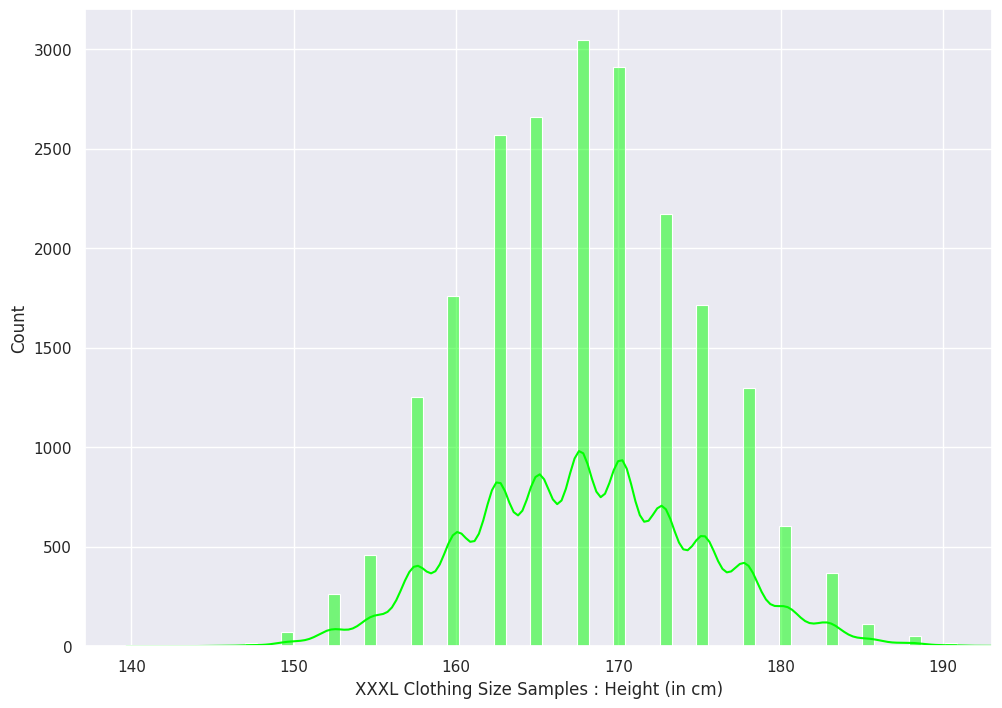

In [ ]:
count_plotted = sns.histplot(x = 'height', data = dataframed.loc[dataframed['size'] == 7], kde = True, color = 'lime')
count_plotted.set(xlabel = "XXXL Clothing Size Samples : Height (in cm)")
count_plotted.set(xlim = (137.1600, 193.0400))

# Outliers : Height

[Text(0.5, 0, 'XXXL Clothing Size Samples : Height (in cm)')]

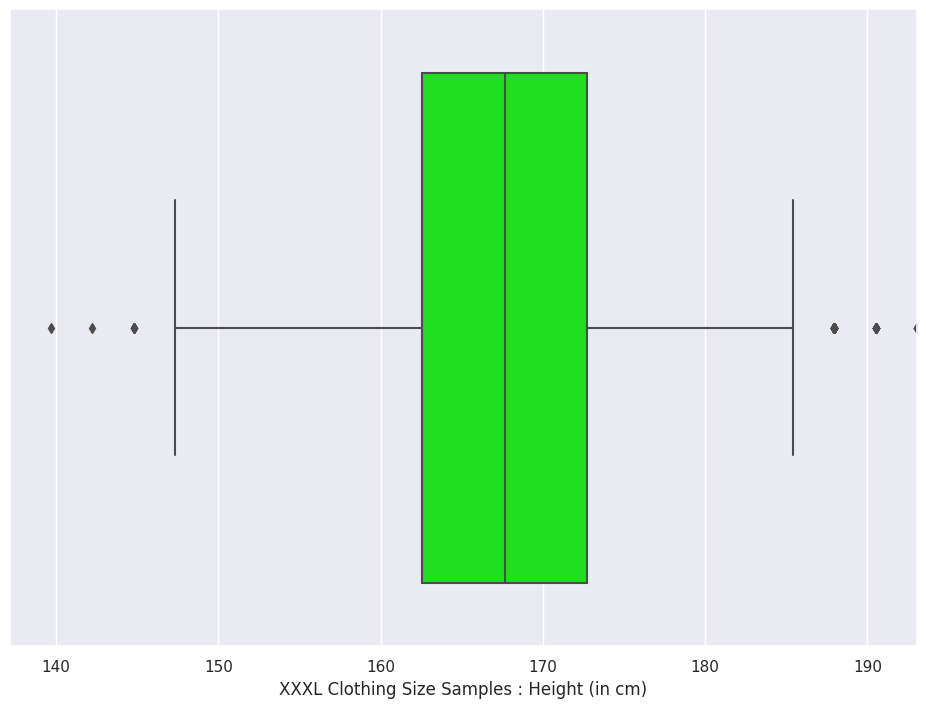

In [ ]:
boxxer_plot = sns.boxplot(x = 'height', data = dataframed.loc[dataframed['size'] == 7], color = 'lime')
boxxer_plot.set(xlim = (137.1600, 193.0400))
boxxer_plot.set(xlabel = "XXXL Clothing Size Samples : Height (in cm)")

# How many outliers in Height Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 7]['height'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 147.3200 or greater than 187.9600
There are 79 outliers.


# Column : Size

# Distribution of rows in terms of Size

[(1.0, 7.0)]

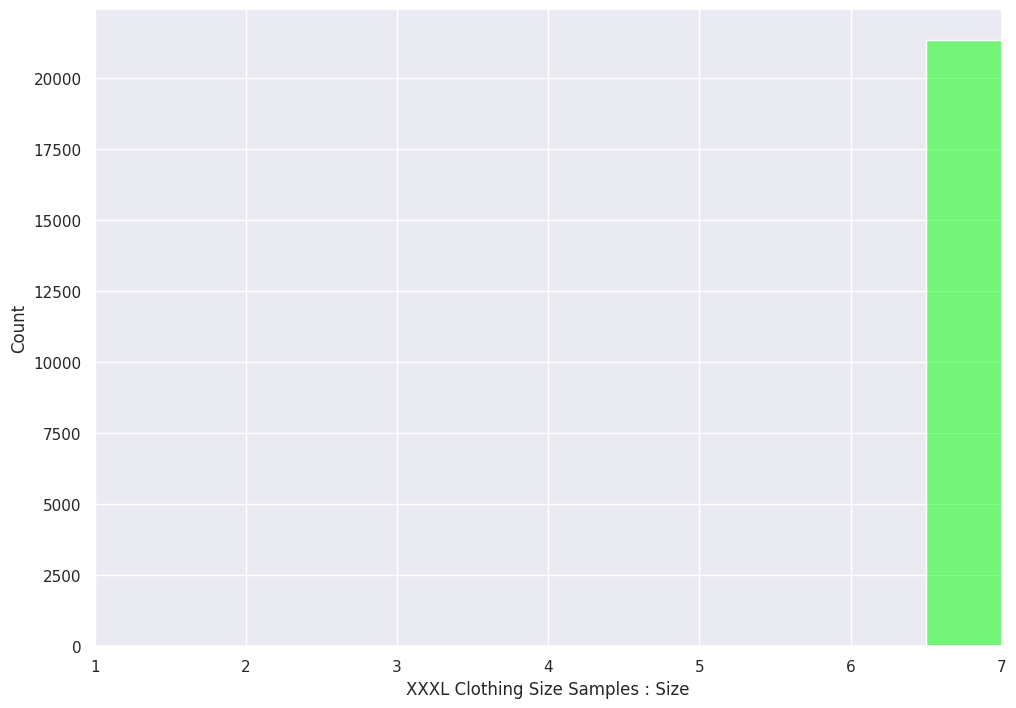

In [ ]:
count_plotted = sns.histplot(x = 'size', data = dataframed.loc[dataframed['size'] == 7], kde = True, color = 'lime')
count_plotted.set(xlabel = "XXXL Clothing Size Samples : Size")
count_plotted.set(xlim = (1.0000, 7.0000))

# Outliers : Size

[Text(0.5, 0, 'XXXL Clothing Size Samples : Size')]

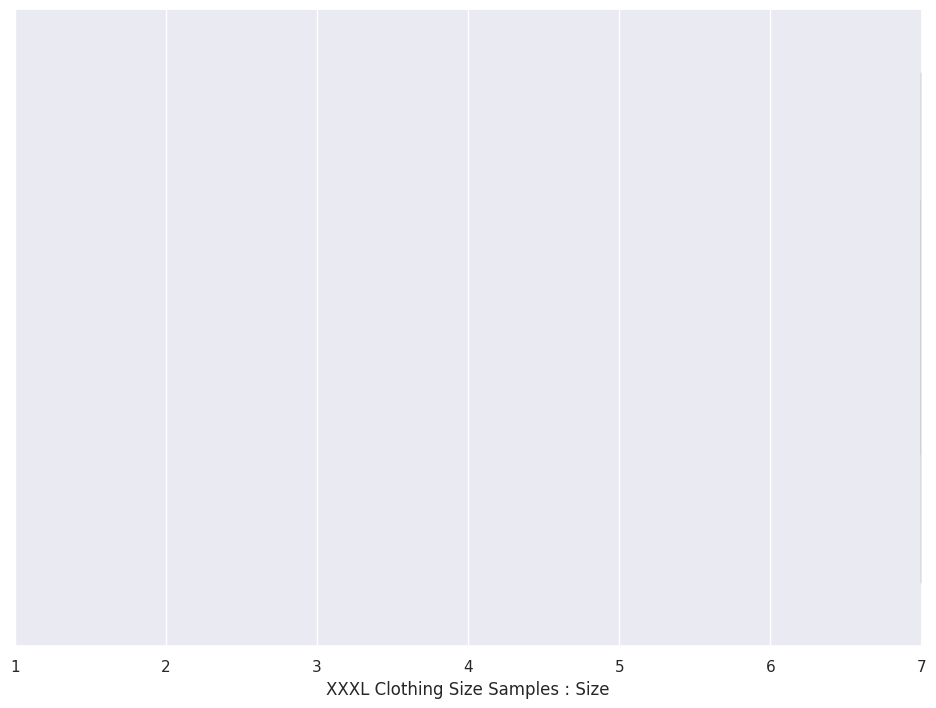

In [ ]:
boxxer_plot = sns.boxplot(x = 'size', data = dataframed.loc[dataframed['size'] == 7], color = 'lime')
boxxer_plot.set(xlim = (1.0000, 7.0000))
boxxer_plot.set(xlabel = "XXXL Clothing Size Samples : Size")

# How many outliers in Size Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 7]['size'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 7.0000 or greater than 7.0000
There are 0 outliers.


# Column : BMI

# Distribution of rows in terms of BMI

[(7.8283, 54.3236)]

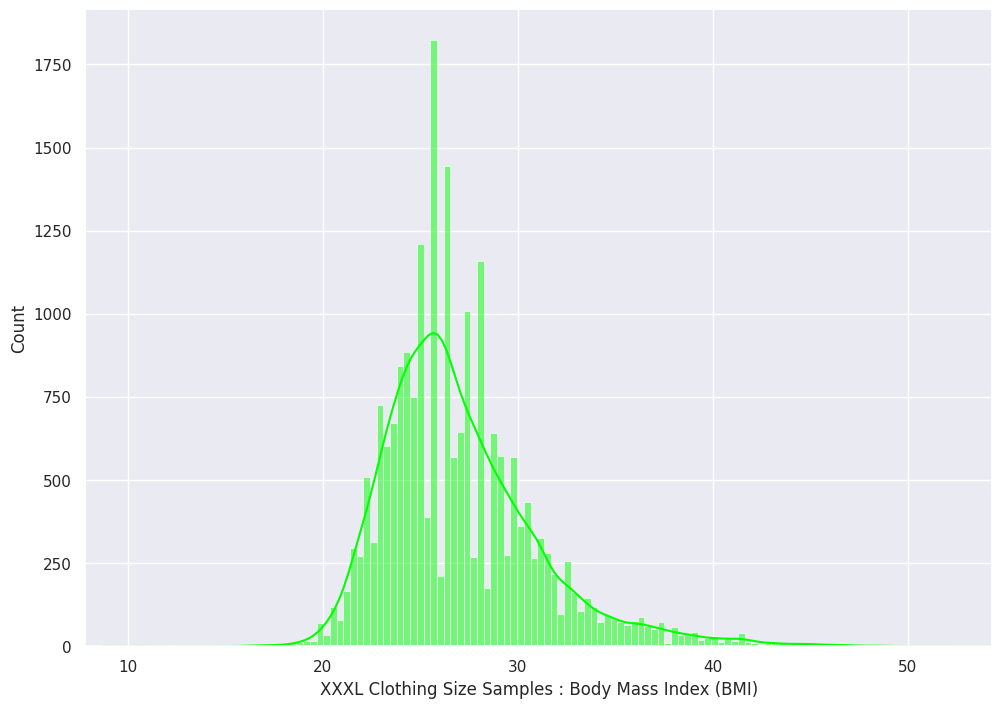

In [ ]:
count_plotted = sns.histplot(x = 'bmi', data = dataframed.loc[dataframed['size'] == 7], kde = True, color = 'lime')
count_plotted.set(xlabel = "XXXL Clothing Size Samples : Body Mass Index (BMI)")
count_plotted.set(xlim = (7.8283, 54.3236))

# Outliers : BMI

[Text(0.5, 0, 'XXXL Clothing Size Samples : Body Mass Index (BMI)')]

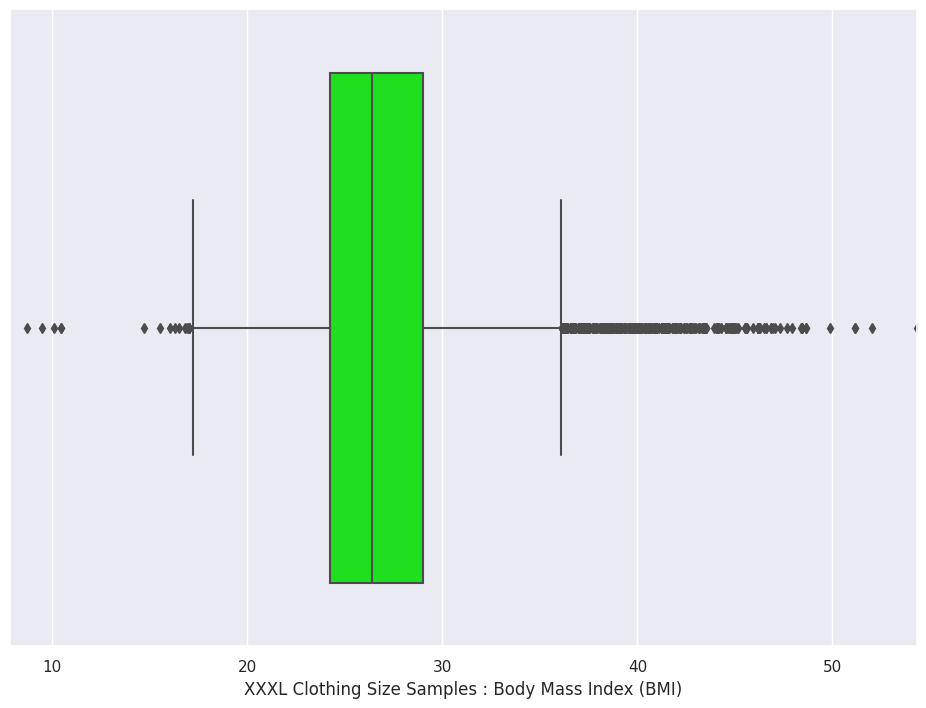

In [ ]:
boxxer_plot = sns.boxplot(x = 'bmi', data = dataframed.loc[dataframed['size'] == 7], color = 'lime')
boxxer_plot.set(xlim = (7.8283, 54.3236))
boxxer_plot.set(xlabel = "XXXL Clothing Size Samples : Body Mass Index (BMI)")

# How many outliers in BMI Column?

In [ ]:
numpy_array = np.array(dataframed.loc[dataframed['size'] == 7]['bmi'])
percentile_1, percentile_2 = np.percentile(numpy_array, [25, 75])
bounds = percentile_2 - percentile_1
lower_bound = percentile_1 - 1.5 * bounds
upper_bound = percentile_2 + 1.5 * bounds
outliers = numpy_array[(numpy_array < lower_bound) | (numpy_array > upper_bound)]
print("The Outliers are values less than {:.4f}".format(lower_bound), "or greater than {:.4f}".format(upper_bound))
print("There are" ,len(outliers), "outliers.")

The Outliers are values less than 17.0583 or greater than 36.1367
There are 778 outliers.


# Z-Score

Z-score is a statistical measurement that describes a value's relationship to the mean of a group of values. Z-score is measured in terms of standard deviations from the mean. If a Z-score is 0, it indicates that the data point's score is identical to the mean score.

In [ ]:
temp_frame = []
sizes = []
for size_type in dataframed['size'].unique():
    sizes.append(size_type)
    ndf = dataframed[['age','height','weight']][dataframed['size'] == size_type]
    zscore = ((ndf - ndf.mean())/ndf.std())
    temp_frame.append(zscore)

for x in range(len(temp_frame)):
    temp_frame[x]['age'] = temp_frame[x]['age'][(temp_frame[x]['age']>-3) & (temp_frame[x]['age']<3)]
    temp_frame[x]['height'] = temp_frame[x]['height'][(temp_frame[x]['height']>-3) & (temp_frame[x]['height']<3)]
    temp_frame[x]['weight'] = temp_frame[x]['weight'][(temp_frame[x]['weight']>-3) & (temp_frame[x]['weight']<3)]

for x in range(len(sizes)):
    temp_frame[x]['size'] = sizes[x]
dataframed = pd.concat(temp_frame)
dataframed.head()

,age,height,weight,size
0,-0.833345,0.769753,-0.660757,5
24,-0.713221,1.542477,1.556338,5
25,-0.352850,-1.162056,-0.291241,5
28,-0.472974,-1.934780,-1.399788,5
34,0.127644,-0.775695,0.447791,5


# Check for Missing Values

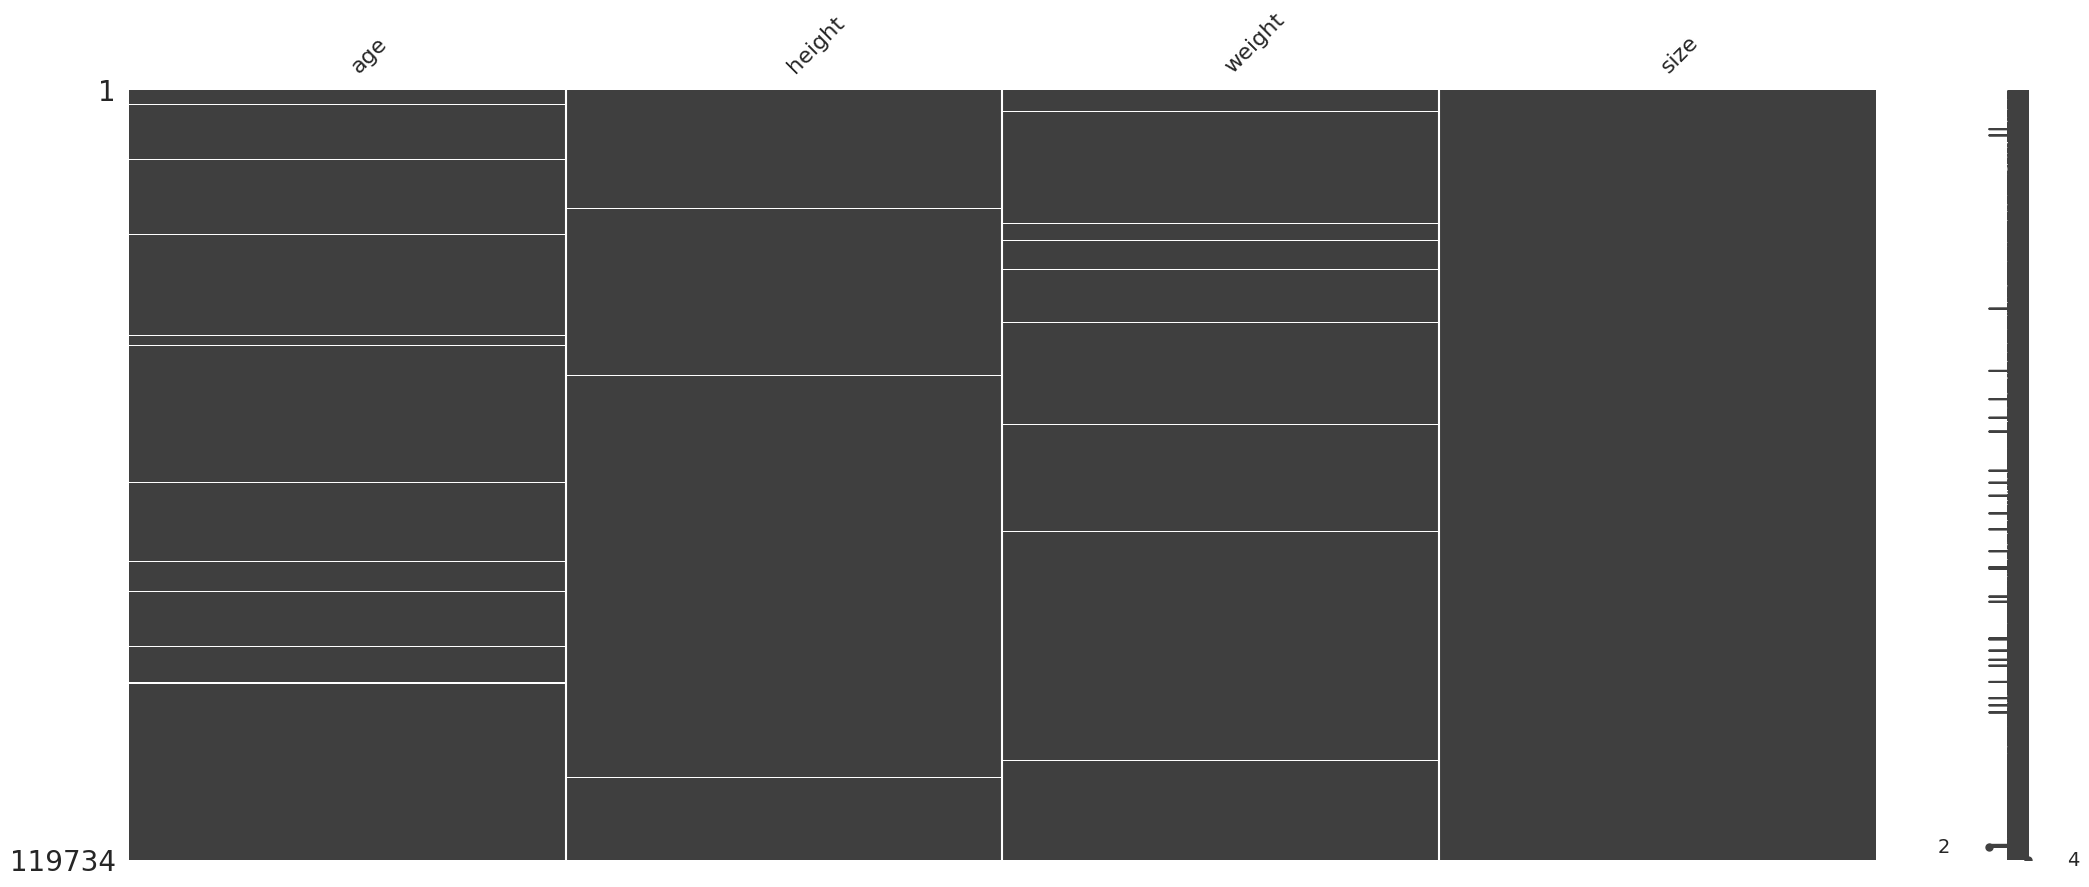

In [ ]:
msno.matrix(dataframed)
plt.show()

# Imputation of Values : Median

In [ ]:
dataframed["age"] = dataframed["age"].fillna(dataframed['age'].median())
dataframed["height"] = dataframed["height"].fillna(dataframed['height'].median())
dataframed["weight"] = dataframed["weight"].fillna(dataframed['weight'].median())

# Update BMI Values

In [ ]:
dataframed["bmi"] = dataframed["height"]/dataframed["weight"]

# Last Call : Check for null values

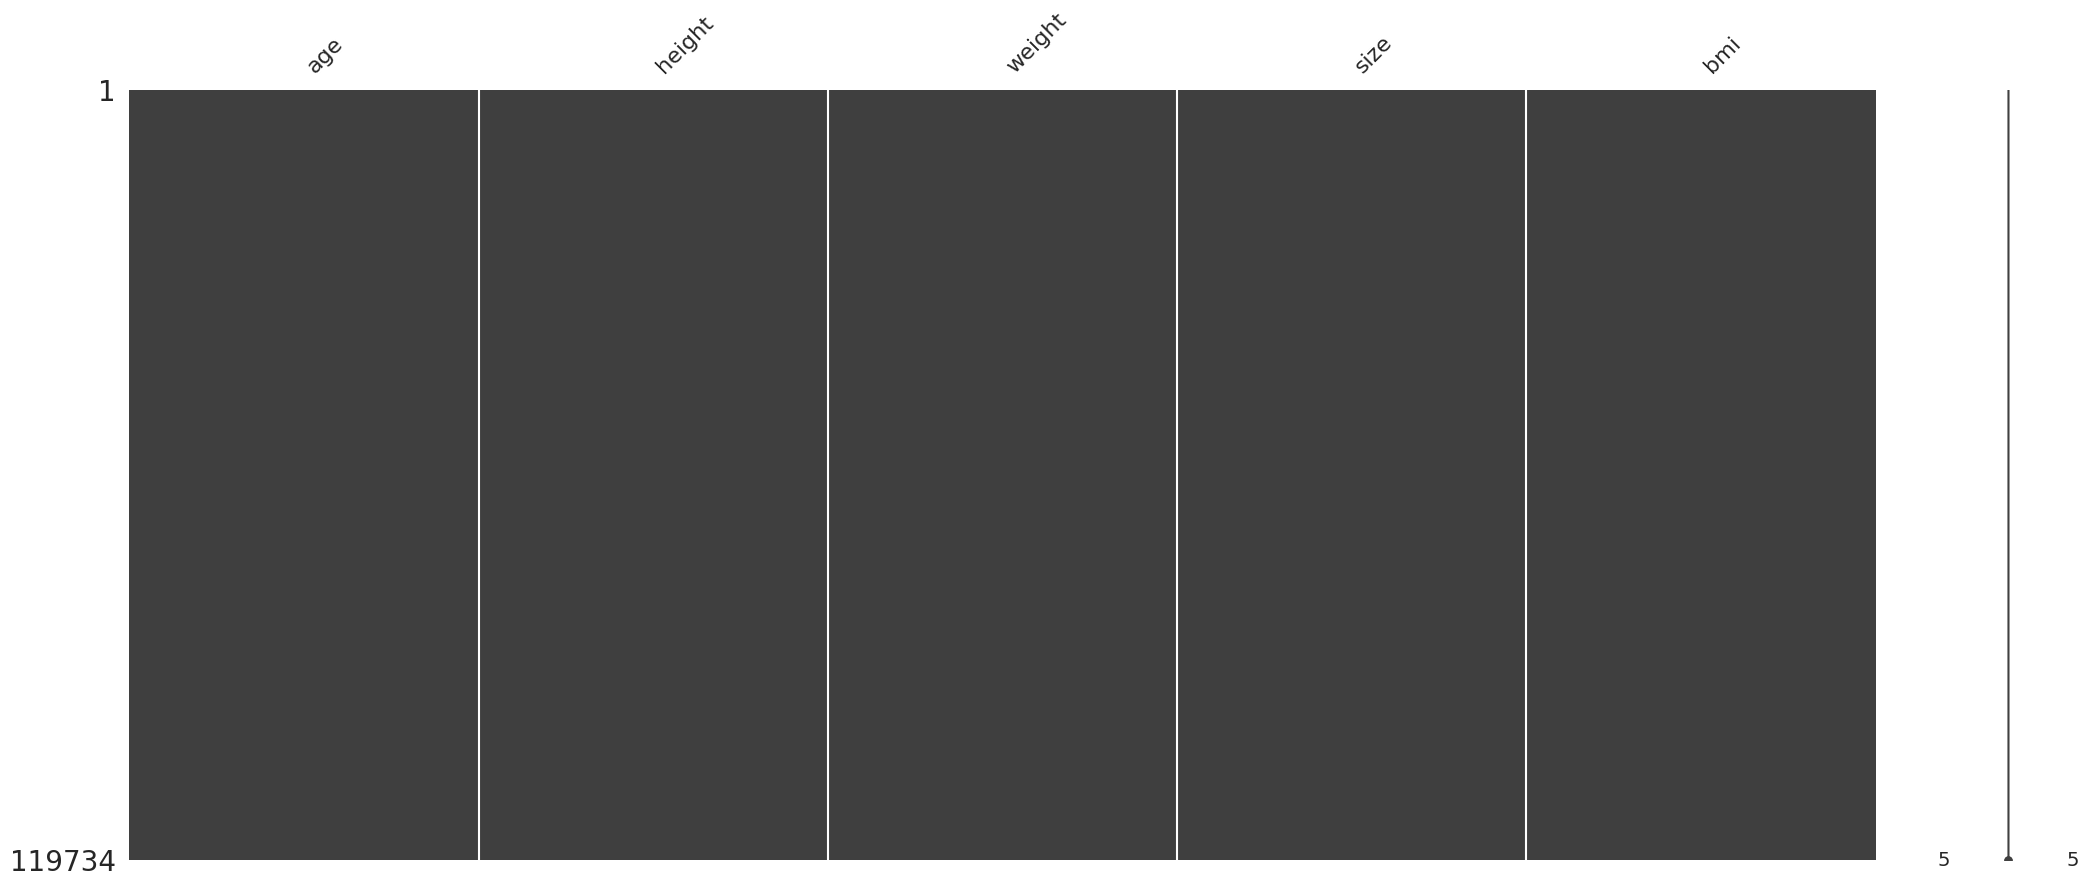

In [ ]:
msno.matrix(dataframed)
plt.show()

# Defining X

Should contain the following :

* Weight
* Age
* Height
* BMI

In [ ]:
X = dataframed[['weight', 'age', 'height', 'bmi']]
X.head()

,weight,age,height,bmi
0,-0.660757,-0.833345,0.769753,-1.164957
24,1.556338,-0.713221,1.542477,0.991094
25,-0.291241,-0.352850,-1.162056,3.990019
28,-1.399788,-0.472974,-1.934780,1.382195
34,0.447791,0.127644,-0.775695,-1.732270


# Defining y

Should contain the following :
* Size

In [ ]:
y = dataframed[['size']]
y.head()

,size
0,5
24,5
25,5
28,5
34,5


# Training and Testing

Supervised AL used :

* K-Nearest Neighbors
* Decision Tree
* Random Forest
* Logistic Regression
* Gaussian Naive Bayes
* Quadratic Discriminant Analysis
* Cat Boost Classifier
* Extra Trees Classifier
* Light Gradient Boosting Machine
* Gradient Boosting Classifier
* Linear Discriminant Analysis
* Ada Boost Classifier
* Ridge Classifier

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , classification_report, ConfusionMatrixDisplay,precision_score,recall_score, f1_score,roc_auc_score,roc_curve

# Split The Data for Training and Testing Purposes
Test Sizes
* 20%
* 30%

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# Shape of Data (20%)

In [ ]:
print("Shape of Data (20%)")
print("X_train shape : ", X_train.shape)
print("y_train shape : ", y_train.shape)
print("X_test shape : ", X_test.shape)
print("y_test shape : ", y_test.shape)

Shape of Data (20%)
X_train shape :  (95787, 4)
y_train shape :  (95787, 1)
X_test shape :  (23947, 4)
y_test shape :  (23947, 1)


# AL : K-Nearest Neighbors (20%)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X_train, y_train.values.ravel())
training_prediction = knn.predict(X_train)
testing_prediction = knn.predict(X_test)

#Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

#Testing Metrics
testing_accuracy = accuracy_score(y_test, testing_prediction)
testing_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
testing_precision = precision_score(y_test, testing_prediction, average = 'weighted')
testing_recall = recall_score(y_test, testing_prediction, average = 'weighted')

print('AL : K-Nearest Neighbors (20%)')
print('\n')
print('Training Model Performance Check')
print('Accuracy Score : {:.4f}'.format(training_accuracy))
print('F1 Score : {:.4f}'.format(training_f1))
print('Precision Score : {:.4f}'.format(training_precision))
print('Recall Score : {:.4f}'.format(training_recall))

print('\n')
print('Testing Model Performance Check')
print('Accuracy Score : {:.4f}'.format(testing_accuracy))
print('F1 Score : {:.4f}'.format(testing_f1))
print('Precision Score : {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

AL : K-Nearest Neighbors (20%)


Training Model Performance Check
Accuracy Score : 0.9533
F1 Score : 0.9530
Precision Score : 0.9534
Recall Score : 0.9533


Testing Model Performance Check
Accuracy Score : 0.9008
F1 Score : 0.9004
Precision Score : 0.9006
Recall Score : 0.9008


# AL : Decision Tree (20%)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

Decision_Tree = DecisionTreeClassifier()
Decision_Tree.fit(X_train, y_train)
training_prediction = Decision_Tree.predict(X_train)
testing_prediction = Decision_Tree.predict(X_test)

'''
# Visualize Decision Tree
# Note : I have decided to not include the visualization of the said decision tree due to its depth making it hard to visualize
plt.figure(figsize = (25,20))
tree.plot_tree(Decision_Tree,
               feature_names =  dataframed.columns.tolist()[:-1],
               class_names = ['1', '2', '3', '4', '5', '6', '7'],
               filled = True,
               precision = 5)
plt.show()
'''

#Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

#Testing Metrics
testing_accuracy = accuracy_score(y_test, testing_prediction)
testing_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
testing_precision = precision_score(y_test, testing_prediction, average = 'weighted')
testing_recall = recall_score(y_test, testing_prediction, average = 'weighted')

print('AL : Decision Tree (20%)')
print('\n')
print('Training Model Performance Check')
print('Accuracy Score {:.4f}'.format(training_accuracy))
print('F1 Score {:.4f}'.format(training_f1))
print('Precision Score {:.4f}'.format(training_precision))
print('Recall Score {:.4f}'.format(training_recall))

print('\n')
print('Testing Model Performance Check')
print('Accuracy Score {:.4f}'.format(testing_accuracy))
print('F1 Score {:.4f}'.format(testing_f1))
print('Precision Score {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

AL : Decision Tree (20%)


Training Model Performance Check
Accuracy Score 1.0000
F1 Score 1.0000
Precision Score 1.0000
Recall Score 1.0000


Testing Model Performance Check
Accuracy Score 0.9996
F1 Score 0.9996
Precision Score 0.9996
Recall Score : 0.9996


# AL: Random Forest (20%)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

Random_Forest = RandomForestClassifier()
Random_Forest.fit(X_train, y_train.values.ravel())
training_prediction = Random_Forest.predict(X_train)
testing_prediction = Random_Forest.predict(X_test)

#Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

#Testing Metrics
testing_accuracy = accuracy_score(y_test, testing_prediction)
testing_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
testing_precision = precision_score(y_test, testing_prediction, average = 'weighted')
testing_recall = recall_score(y_test, testing_prediction, average = 'weighted')


print('AL : Random Forest (20%)')
print('\n')
print('Training Model Performance Check')
print('Accuracy Score : {:.4f}'.format(training_accuracy))
print('F1 Score : {:.4f}'.format(training_f1))
print('Precision Score : {:.4f}'.format(training_precision))
print('Recall Score : {:.4f}'.format(training_recall))


print('\n')
print('Testing Model Performance Check')
print('Accuracy Score : {:.4f}'.format(testing_accuracy))
print('F1 Score : {:.4f}'.format(testing_f1))
print('Precision Score : {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

AL : Random Forest (20%)


Training Model Performance Check
Accuracy Score : 1.0000
F1 Score : 1.0000
Precision Score : 1.0000
Recall Score : 1.0000


Testing Model Performance Check
Accuracy Score : 0.9983
F1 Score : 0.9983
Precision Score : 0.9983
Recall Score : 0.9983


# AL : Logistic Regression (20%)

In [ ]:
from sklearn.linear_model import LogisticRegression
Logistic_Regression = LogisticRegression()
Logistic_Regression.fit(X_train, y_train.values.ravel())
training_prediction = Logistic_Regression.predict(X_train)
testing_prediction = Logistic_Regression.predict(X_test)

# Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

# Testing Metrics

testing_accuracy = accuracy_score(y_test, testing_prediction)
training_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
training_precision = precision_score(y_test, testing_prediction, average = 'weighted')
training_recall = recall_score(y_test, testing_prediction, average = 'weighted')


print('AL : Logistic Regression (20%)')
print('\n')

print('Training Model Performance Check')
print('Accuracy Score : {:.4f}'.format(training_accuracy))
print('F1 Score : {:.4f}'.format(training_f1))
print('Precision Score : {:.4f}'.format(training_precision))
print('Recall Score : {:.4f}'.format(training_recall))

print('\n')
print('Testing Model Performance Check')
print('Accuracy Score : {:.4f}'.format(testing_accuracy))
print('F1 Score : {:.4f}'.format(testing_f1))
print('Precision Score : {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

AL : Logistic Regression (20%)


Training Model Performance Check
Accuracy Score : 0.2484
F1 Score : 0.1011
Precision Score : 0.1364
Recall Score : 0.2505


Testing Model Performance Check
Accuracy Score : 0.2505
F1 Score : 0.9983
Precision Score : 0.9983
Recall Score : 0.9983


# AL : Gaussian Naive Bayes (20%)

In [ ]:
from sklearn.naive_bayes import GaussianNB
NB = GaussianNB()
NB.fit(X_train, y_train.values.ravel())
training_prediction = NB.predict(X_train)
testing_prediction = NB.predict(X_test)

# Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

# Testing Metrics

testing_accuracy = accuracy_score(y_test, testing_prediction)
training_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
training_precision = precision_score(y_test, testing_prediction, average = 'weighted')
training_recall = recall_score(y_test, testing_prediction, average = 'weighted')


print('AL : Gaussian Naive Bayes (20%)')
print('\n')

print('Training Model Performance Check')
print('Accuracy Score : {:.4f}'.format(training_accuracy))
print('F1 Score : {:.4f}'.format(training_f1))
print('Precision Score : {:.4f}'.format(training_precision))
print('Recall Score : {:.4f}'.format(training_recall))

print('\n')
print('Testing Model Performance Check')
print('Accuracy Score : {:.4f}'.format(testing_accuracy))
print('F1 Score : {:.4f}'.format(testing_f1))
print('Precision Score : {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

AL : Gaussian Naive Bayes (20%)


Training Model Performance Check
Accuracy Score : 0.1642
F1 Score : 0.0888
Precision Score : 0.0949
Recall Score : 0.1694


Testing Model Performance Check
Accuracy Score : 0.1694
F1 Score : 0.9983
Precision Score : 0.9983
Recall Score : 0.9983


# AL : Quadratic Discriminant Analysis (20%)

In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
QDA = QuadraticDiscriminantAnalysis()
QDA.fit(X_train, y_train.values.ravel())
training_prediction = QDA.predict(X_train)
testing_prediction = QDA.predict(X_test)

# Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

# Testing Metrics

testing_accuracy = accuracy_score(y_test, testing_prediction)
training_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
training_precision = precision_score(y_test, testing_prediction, average = 'weighted')
training_recall = recall_score(y_test, testing_prediction, average = 'weighted')


print('AL : Quadratic Discriminant Analysis (20%)')
print('\n')

print('Training Model Performance Check')
print('Accuracy Score : {:.4f}'.format(training_accuracy))
print('F1 Score : {:.4f}'.format(training_f1))
print('Precision Score : {:.4f}'.format(training_precision))
print('Recall Score : {:.4f}'.format(training_recall))

print('\n')
print('Testing Model Performance Check')
print('Accuracy Score : {:.4f}'.format(testing_accuracy))
print('F1 Score : {:.4f}'.format(testing_f1))
print('Precision Score : {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

AL : Quadratic Discriminant Analysis (20%)


Training Model Performance Check
Accuracy Score : 0.1803
F1 Score : 0.1362
Precision Score : 0.2337
Recall Score : 0.1862


Testing Model Performance Check
Accuracy Score : 0.1862
F1 Score : 0.9983
Precision Score : 0.9983
Recall Score : 0.9983


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

# Shape of Data (30%)

In [ ]:
print('Shape of Data (30%)')
print('X_train shape : ', X_train.shape)
print('y_train shape : ', y_train.shape)
print('X_test shape : ', X_test.shape)
print('y_train shape : ', y_train.shape)

Shape of Data (30%)
X_train shape :  (83813, 4)
y_train shape :  (83813, 1)
X_test shape :  (35921, 4)
y_train shape :  (83813, 1)


# AL : K-Nearest Neighbors (30%)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors = 3)
knn.fit(X_train, y_train.values.ravel())
training_prediction = knn.predict(X_train)
testing_prediction = knn.predict(X_test)

#Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

#Testing Metrics
testing_accuracy = accuracy_score(y_test, testing_prediction)
testing_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
testing_precision = precision_score(y_test, testing_prediction, average = 'weighted')
testing_recall = recall_score(y_test, testing_prediction, average = 'weighted')

print('AL : K-Nearest Neighbors (30%)')
print('\n')
print('Training Model Performance Check')
print('Accuracy Score : {:.4f}'.format(training_accuracy))
print('F1 Score : {:.4f}'.format(training_f1))
print('Precision Score : {:.4f}'.format(training_precision))
print('Recall Score : {:.4f}'.format(training_recall))

print('\n')
print('Testing Model Performance Check')
print('Accuracy Score : {:.4f}'.format(testing_accuracy))
print('F1 Score : {:.4f}'.format(testing_f1))
print('Precision Score : {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

AL : K-Nearest Neighbors (30%)


Training Model Performance Check
Accuracy Score : 0.9476
F1 Score : 0.9473
Precision Score : 0.9478
Recall Score : 0.9476


Testing Model Performance Check
Accuracy Score : 0.8912
F1 Score : 0.8907
Precision Score : 0.8910
Recall Score : 0.8912


# AL : Decision Tree (30%)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

Decision_Tree = DecisionTreeClassifier()
Decision_Tree.fit(X_train, y_train)
training_prediction = Decision_Tree.predict(X_train)
testing_prediction = Decision_Tree.predict(X_test)

'''
# Visualize Decision Tree
# Note : I have decided to not include the visualization of the said decision tree due to its depth making it hard to visualize
plt.figure(figsize = (25,20))
tree.plot_tree(Decision_Tree,
               feature_names =  dataframed.columns.tolist()[:-1],
               class_names = ['1', '2', '3', '4', '5', '6', '7'],
               filled = True,
               precision = 5)
plt.show()
'''

#Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

#Testing Metrics
testing_accuracy = accuracy_score(y_test, testing_prediction)
testing_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
testing_precision = precision_score(y_test, testing_prediction, average = 'weighted')
testing_recall = recall_score(y_test, testing_prediction, average = 'weighted')

print('AL : Decision Tree (30%)')
print('\n')
print('Training Model Performance Check')
print('Accuracy Score {:.4f}'.format(training_accuracy))
print('F1 Score {:.4f}'.format(training_f1))
print('Precision Score {:.4f}'.format(training_precision))
print('Recall Score {:.4f}'.format(training_recall))

print('\n')
print('Testing Model Performance Check')
print('Accuracy Score {:.4f}'.format(testing_accuracy))
print('F1 Score {:.4f}'.format(testing_f1))
print('Precision Score {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

AL : Decision Tree (30%)


Training Model Performance Check
Accuracy Score 1.0000
F1 Score 1.0000
Precision Score 1.0000
Recall Score 1.0000


Testing Model Performance Check
Accuracy Score 0.9996
F1 Score 0.9996
Precision Score 0.9996
Recall Score : 0.9996


# AL : Random Forest (30%)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

Random_Forest = RandomForestClassifier()
Random_Forest.fit(X_train, y_train.values.ravel())
training_prediction = Random_Forest.predict(X_train)
testing_prediction = Random_Forest.predict(X_test)

#Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

#Testing Metrics
testing_accuracy = accuracy_score(y_test, testing_prediction)
testing_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
testing_precision = precision_score(y_test, testing_prediction, average = 'weighted')
testing_recall = recall_score(y_test, testing_prediction, average = 'weighted')


print('AL : Random Forest (30%)')
print('\n')
print('Training Model Performance Check')
print('Accuracy Score : {:.4f}'.format(training_accuracy))
print('F1 Score : {:.4f}'.format(training_f1))
print('Precision Score : {:.4f}'.format(training_precision))
print('Recall Score : {:.4f}'.format(training_recall))


print('\n')
print('Testing Model Performance Check')
print('Accuracy Score : {:.4f}'.format(testing_accuracy))
print('F1 Score : {:.4f}'.format(testing_f1))
print('Precision Score : {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

# AL : Logistic Regression (30%)

In [ ]:
from sklearn.linear_model import LogisticRegression
Logistic_Regression = LogisticRegression()
Logistic_Regression.fit(X_train, y_train.values.ravel())
training_prediction = Logistic_Regression.predict(X_train)
testing_prediction = Logistic_Regression.predict(X_test)

# Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

# Testing Metrics

testing_accuracy = accuracy_score(y_test, testing_prediction)
training_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
training_precision = precision_score(y_test, testing_prediction, average = 'weighted')
training_recall = recall_score(y_test, testing_prediction, average = 'weighted')


print('AL : Logistic Regression (30%)')
print('\n')

print('Training Model Performance Check')
print('Accuracy Score : {:.4f}'.format(training_accuracy))
print('F1 Score : {:.4f}'.format(training_f1))
print('Precision Score : {:.4f}'.format(training_precision))
print('Recall Score : {:.4f}'.format(training_recall))

print('\n')
print('Testing Model Performance Check')
print('Accuracy Score : {:.4f}'.format(testing_accuracy))
print('F1 Score : {:.4f}'.format(testing_f1))
print('Precision Score : {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

AL : Logistic Regression (30%)


Training Model Performance Check
Accuracy Score : 0.2474
F1 Score : 0.1024
Precision Score : 0.1371
Recall Score : 0.2521


Testing Model Performance Check
Accuracy Score : 0.2521
F1 Score : 0.9996
Precision Score : 0.9996
Recall Score : 0.9996


# AL : Gaussian Naive Bayes (30%)

In [ ]:
from sklearn.naive_bayes import GaussianNB
NB = GaussianNB()
NB.fit(X_train, y_train.values.ravel())
training_prediction = NB.predict(X_train)
testing_prediction = NB.predict(X_test)

# Training Metrics
training_accuracy = accuracy_score(y_train, training_prediction)
training_f1 = f1_score(y_train, training_prediction, average = 'weighted')
training_precision = precision_score(y_train, training_prediction, average = 'weighted')
training_recall = recall_score(y_train, training_prediction, average = 'weighted')

# Testing Metrics

testing_accuracy = accuracy_score(y_test, testing_prediction)
training_f1 = f1_score(y_test, testing_prediction, average = 'weighted')
training_precision = precision_score(y_test, testing_prediction, average = 'weighted')
training_recall = recall_score(y_test, testing_prediction, average = 'weighted')


print('AL : Gaussian Naive Bayes (30%)')
print('\n')

print('Training Model Performance Check')
print('Accuracy Score : {:.4f}'.format(training_accuracy))
print('F1 Score : {:.4f}'.format(training_f1))
print('Precision Score : {:.4f}'.format(training_precision))
print('Recall Score : {:.4f}'.format(training_recall))

print('\n')
print('Testing Model Performance Check')
print('Accuracy Score : {:.4f}'.format(testing_accuracy))
print('F1 Score : {:.4f}'.format(testing_f1))
print('Precision Score : {:.4f}'.format(testing_precision))
print('Recall Score : {:.4f}'.format(testing_recall))

AL : Gaussian Naive Bayes (30%)


Training Model Performance Check
Accuracy Score : 0.1650
F1 Score : 0.0870
Precision Score : 0.0941
Recall Score : 0.1665


Testing Model Performance Check
Accuracy Score : 0.1665
F1 Score : 0.9996
Precision Score : 0.9996
Recall Score : 0.9996
